# ITO5202 Assessment 2: Machine Learning and Streaming Analytics

**Student ID:** 27602966  
**Dataset:** NYC TLC Yellow Taxi Trip Records, January–December 2023, and Taxi Zone Lookup  
**GitHub repository:** [ITO5202_Ass2_27602966](https://github.com/hncha9-eng/ITO5202_Ass2_27602966)

## Assessment Overview

This assessment extends the historical batch analysis completed in Assessment 1. The approved dataset is reused to train and evaluate a Spark ML model, then apply the persisted model to previously unseen records replayed through Kafka.

| Notebook section | Requirements addressed |
|---|---|
| Execution Environment | Runtime configuration, dependency versions and environment verification |
| Dataset Reuse and Train/Stream Split | Source validation, data preparation, reproducible partitioning and streaming subset persistence |
| Part A: The ML Pipeline | Task selection, feature engineering, model comparison, evaluation, model persistence and reload verification |
| Part B: Streaming, Kafka and Reflection | Held-out replay, Kafka producer, Structured Streaming consumer, windowed aggregation and embedded reflection |

The streaming subset remains excluded from model fitting, tuning and selection. Part B will use the persisted feature engineering and prediction pipeline from Part A.

## Execution Environment

### Python and Spark Configuration

The notebook runs inside the PySpark Docker container, with the repository mounted at `/home/student/work`. Project files are accessed using paths relative to the repository root.

The configuration below matches the verified assessment environment.

| Setting | Configuration |
|---|---|
| Apache Spark | 3.5.5 |
| Scala | 2.12.18 |
| Execution mode | local[2] |
| Driver memory | 2 GB |
| Spark session timezone | America/New_York |
| Kafka connector | org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.5 |
| Docker network | ito5202 |
| Kafka bootstrap server inside the Docker network | kafka:9092 |

The Kafka connector matches the Spark version and Scala binary version. Package and driver memory settings are declared before Spark starts.

The `America/New_York` session timezone supports consistent interpretation of the NYC taxi timestamps. The same Spark environment supports historical model development in Part A and streaming inference in Part B.

In [1]:
import os
import sys
from pathlib import Path

import pyspark

EXPECTED_SPARK_VERSION = "3.5.5"

if pyspark.__version__ != EXPECTED_SPARK_VERSION:
    raise RuntimeError(
        f"Expected PySpark {EXPECTED_SPARK_VERSION}, "
        f"found {pyspark.__version__}. "
        "Use the assessment's verified container."
    )

KAFKA_CONNECTOR = (
    "org.apache.spark:"
    "spark-sql-kafka-0-10_2.12:3.5.5"
)

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_SUBMIT_ARGS"] = (
    f"--driver-memory 2g --packages {KAFKA_CONNECTOR} pyspark-shell"
)

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("ITO5202 Assessment 2")
    .master("local[2]")
    .config("spark.ui.port", "4040")
    .config("spark.sql.session.timeZone", "America/New_York")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

### Environment Verification

The following cell records the runtime versions and active Spark configuration so the execution environment can be checked during reproduction.

A three-row DataFrame is displayed to verify that a Spark action completes successfully. The expected configuration is Spark 3.5.5, Scala 2.12.18, `local[2]`, driver memory `2g` and session timezone `America/New_York`.

In [2]:
print("Python:", sys.version.split()[0])
print("Spark:", spark.version)
print(
    "Scala:",
    spark.sparkContext._jvm.scala.util.Properties.versionNumberString()
)
print("Master:", spark.sparkContext.master)
print(
    "Driver memory:",
    spark.sparkContext.getConf().get("spark.driver.memory")
)
print("Timezone:", spark.conf.get("spark.sql.session.timeZone"))
print("Kafka connector:", KAFKA_CONNECTOR)

spark.range(3).show()

Python: 3.10.19
Spark: 3.5.5
Scala: 2.12.18
Master: local[2]
Driver memory: 2g
Timezone: America/New_York
Kafka connector: org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.5
+---+
| id|
+---+
|  0|
|  1|
|  2|
+---+



In [3]:
# Use a writable Matplotlib configuration and cache directory.
import os
import tempfile
from pathlib import Path

matplotlib_config_dir = (
    Path(tempfile.gettempdir()) / "ito5202-matplotlib"
)
matplotlib_config_dir.mkdir(parents=True, exist_ok=True)

os.environ["MPLCONFIGDIR"] = str(matplotlib_config_dir)

print("Matplotlib configuration directory:", matplotlib_config_dir)

Matplotlib configuration directory: /tmp/ito5202-matplotlib


## Dataset Reuse and Train/Stream Split

### Dataset Reuse and Preparation

#### Dataset Sources and Input Verification

Assessment 2 reuses the approved Assessment 1 dataset: NYC TLC Yellow Taxi Trip Records for January–December 2023 and the Taxi Zone Lookup. No new dataset selection is required.

| Source | Expected files | Purpose |
|---|---|---|
| Yellow Taxi Trip Records | Twelve monthly Parquet files, from `yellow_tripdata_2023-01.parquet` to `yellow_tripdata_2023-12.parquet` | Trip records containing timestamps, location identifiers, passenger counts, distances and financial attributes |
| Taxi Zone Lookup | `taxi_zone_lookup.csv` | Reference attributes associated with taxi location identifiers |

All source files are stored in the repository's `data/` directory. 

The following cell verifies that all thirteen required source files are available. Schema inspection and data validation follow in subsequent sections.

The large Parquet files are excluded from Git tracking. Their download instructions are documented in `data/README.md`, while the small taxi zone lookup is included in the repository.

In [4]:
PROJECT_ROOT = Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data"

MONTHLY_FILES = [
    DATA_DIR / f"yellow_tripdata_2023-{month:02d}.parquet"
    for month in range(1, 13)
]

ZONE_FILE = DATA_DIR / "taxi_zone_lookup.csv"
required_files = MONTHLY_FILES + [ZONE_FILE]

print("Repository root:", PROJECT_ROOT)

missing_files = []

for source_file in required_files:
    exists = source_file.is_file()

    print(
        f"{'FOUND' if exists else 'MISSING'}: {source_file.name}"
    )

    if not exists:
        missing_files.append(source_file.name)

if missing_files:
    raise FileNotFoundError(
        "Place the original source files in the repository's data folder. "
        f"Missing: {', '.join(missing_files)}"
    )

Repository root: /home/student/work
FOUND: yellow_tripdata_2023-01.parquet
FOUND: yellow_tripdata_2023-02.parquet
FOUND: yellow_tripdata_2023-03.parquet
FOUND: yellow_tripdata_2023-04.parquet
FOUND: yellow_tripdata_2023-05.parquet
FOUND: yellow_tripdata_2023-06.parquet
FOUND: yellow_tripdata_2023-07.parquet
FOUND: yellow_tripdata_2023-08.parquet
FOUND: yellow_tripdata_2023-09.parquet
FOUND: yellow_tripdata_2023-10.parquet
FOUND: yellow_tripdata_2023-11.parquet
FOUND: yellow_tripdata_2023-12.parquet
FOUND: taxi_zone_lookup.csv


##### Input Verification Results

All twelve monthly Parquet files and `taxi_zone_lookup.csv` were reported as `FOUND`. The expected source files are therefore available for schema inspection and loading.

These inputs preserve the dataset coverage used in Assessment 1. The subsequent preparation steps establish a consistent schema and document data quality decisions before the reproducible train/stream split.

#### Schema Definition and Source Inspection

The twelve monthly files are inspected separately to identify differences in column names and data types before combining their records.

Assessment 1 identified schema differences involving `passenger_count`, `RatecodeID`, pickup and drop-off location identifiers, and the capitalisation of the airport fee column.

The following comparison documents these differences using each file's Parquet schema. The findings guide the common schema used in the subsequent loading and standardisation step.

Statistical exploration and learned feature preprocessing are performed using the training data after the train/stream split.

In [5]:
monthly_schemas = {}
schema_rows = []

for source_file in MONTHLY_FILES:
    source_df = spark.read.parquet(str(source_file))
    source_schema = source_df.schema

    monthly_schemas[source_file.name] = source_schema

    column_types = {
        field.name: field.dataType.simpleString()
        for field in source_schema.fields
    }

    airport_columns = [
        field.name
        for field in source_schema.fields
        if field.name.lower() == "airport_fee"
    ]

    schema_rows.append((
        source_file.stem[-7:],
        column_types.get("passenger_count", "missing"),
        column_types.get("RatecodeID", "missing"),
        column_types.get("PULocationID", "missing"),
        column_types.get("DOLocationID", "missing"),
        ", ".join(airport_columns) or "missing",
    ))

schema_summary = spark.createDataFrame(
    schema_rows,
    schema=(
        "month string, passenger_count string, RatecodeID string, "
        "PULocationID string, DOLocationID string, airport_column string"
    ),
)

schema_summary.orderBy("month").show(12, truncate=False)

+-------+---------------+----------+------------+------------+--------------+
|month  |passenger_count|RatecodeID|PULocationID|DOLocationID|airport_column|
+-------+---------------+----------+------------+------------+--------------+
|2023-01|double         |double    |bigint      |bigint      |airport_fee   |
|2023-02|bigint         |bigint    |int         |int         |Airport_fee   |
|2023-03|bigint         |bigint    |int         |int         |Airport_fee   |
|2023-04|bigint         |bigint    |int         |int         |Airport_fee   |
|2023-05|bigint         |bigint    |int         |int         |Airport_fee   |
|2023-06|bigint         |bigint    |int         |int         |Airport_fee   |
|2023-07|bigint         |bigint    |int         |int         |Airport_fee   |
|2023-08|bigint         |bigint    |int         |int         |Airport_fee   |
|2023-09|bigint         |bigint    |int         |int         |Airport_fee   |
|2023-10|bigint         |bigint    |int         |int         |Ai

##### January Source Schema

The complete January schema provides a reference for the original nineteen columns, including trip timestamps, numerical attributes, location identifiers and categorical fields.

Displaying the full schema makes the source types visible before defining the common schema used across all months.

In [6]:
january_df = spark.read.parquet(str(MONTHLY_FILES[0]))

print("Source:", MONTHLY_FILES[0].name)
january_df.printSchema()

Source: yellow_tripdata_2023-01.parquet
root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)



##### Schema Inspection Findings

The executed monthly comparison confirms the following differences:

| Field | January 2023 | February–December 2023 |
|---|---|---|
| `passenger_count` | `double` | `bigint` |
| `RatecodeID` | `double` | `bigint` |
| `PULocationID` | `bigint` | `int` |
| `DOLocationID` | `bigint` | `int` |
| Airport fee column name | `airport_fee` | `Airport_fee` |

The January file contains nineteen columns. Both `tpep_pickup_datetime` and `tpep_dropoff_datetime` use `timestamp_ntz`. Distance and financial attributes use `double`, while `store_and_fwd_flag` uses `string`.

These findings establish the need for a consistent loading strategy. The next section reads each monthly file separately, applies compatible column types, standardises the airport fee column name and combines the resulting DataFrames.

#### Monthly Data Loading and Standardisation

Each monthly file is read using its source Parquet schema, then transformed into a common nineteen-column schema before the months are combined.

This approach handles the differences identified under Schema Definition and Source Inspection through explicit casts and consistent column naming.

| Columns | Common type or name | Rationale |
|---|---|---|
| `VendorID`, `PULocationID`, `DOLocationID`, `payment_type` | `long` | Provides consistent integer storage across the source files |
| `passenger_count`, `RatecodeID` | `double` | Retains fractional values from the January source for explicit data quality checks |
| Pickup and drop-off datetimes | `timestamp` | Provides a common timestamp type under the configured `America/New_York` session timezone |
| `trip_distance` and financial attributes | `double` | Provides consistent numerical types across all months |
| `store_and_fwd_flag` | `string` | Retains the original categorical representation |
| Airport fee column | `airport_fee` | Standardises the capitalisation difference between January and subsequent months |

Keeping `passenger_count` and `RatecodeID` as doubles during preparation allows questionable fractional values to be identified before deciding how to handle them.

The loader checks that each file contains all required columns. It then selects, casts and aliases those columns in a consistent order.

The monthly DataFrames are combined using `unionByName()`, which aligns corresponding columns by name. All source rows are retained at this stage; eligibility rules are documented and applied during data quality preparation.

These storage types establish a consistent source schema. Feature selection and the treatment of numerical and categorical inputs are justified in Part A.

In [7]:
from functools import reduce
from pyspark.sql import functions as F

spark.conf.set("spark.sql.session.timeZone", "America/New_York")

COLUMN_TYPES = {
    "VendorID": "long",
    "tpep_pickup_datetime": "timestamp",
    "tpep_dropoff_datetime": "timestamp",
    "passenger_count": "double",
    "trip_distance": "double",
    "RatecodeID": "double",
    "store_and_fwd_flag": "string",
    "PULocationID": "long",
    "DOLocationID": "long",
    "payment_type": "long",
    "fare_amount": "double",
    "extra": "double",
    "mta_tax": "double",
    "tip_amount": "double",
    "tolls_amount": "double",
    "improvement_surcharge": "double",
    "total_amount": "double",
    "congestion_surcharge": "double",
    "airport_fee": "double",
}


def standardise_month(source_path):
    source_df = spark.read.parquet(str(source_path))

    source_columns = {
        name.lower(): name
        for name in source_df.columns
    }

    missing_columns = [
        name
        for name in COLUMN_TYPES
        if name.lower() not in source_columns
    ]

    if missing_columns:
        raise ValueError(
            f"{source_path.name}: missing columns {missing_columns}"
        )

    return source_df.select(*[
        F.col(source_columns[name.lower()])
        .cast(data_type)
        .alias(name)
        for name, data_type in COLUMN_TYPES.items()
    ])


monthly_dfs = [
    standardise_month(source_path)
    for source_path in MONTHLY_FILES
]

raw_trips_df = reduce(
    lambda combined, month: combined.unionByName(month),
    monthly_dfs,
)

raw_trips_df.printSchema()

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)



##### Standardisation Outcome

The combined DataFrame, `raw_trips_df`, uses the common nineteen-column schema defined above.

The airport fee column has the consistent name `airport_fee`. Location identifiers use `long`, while passenger counts and rate codes remain `double` for subsequent validation.

This DataFrame provides the source for record-count verification and data quality preparation. The next section checks the loaded dataset's size and displays a bounded sample.

#### Source Loading Validation

The combined DataFrame is checked for the number of monthly inputs, column count and total record count.

The record count is compared with the original raw dataset count from Assessment 1 to verify consistency in dataset coverage. A five-row sample displays selected fields after standardisation.

These results establish the baseline against which subsequent data quality exclusions and train/stream partition counts are reconciled.

In [8]:
raw_trip_count = raw_trips_df.count()

print("Monthly files:", len(monthly_dfs))
print("Columns:", len(raw_trips_df.columns))
print(f"Total trip records: {raw_trip_count:,}")

raw_trips_df.select(
    "tpep_pickup_datetime",
    "passenger_count",
    "RatecodeID",
    "PULocationID",
    "airport_fee",
).show(5, truncate=False)

Monthly files: 12
Columns: 19
Total trip records: 38,310,226
+--------------------+---------------+----------+------------+-----------+
|tpep_pickup_datetime|passenger_count|RatecodeID|PULocationID|airport_fee|
+--------------------+---------------+----------+------------+-----------+
|2023-01-01 00:32:10 |1.0            |1.0       |161         |0.0        |
|2023-01-01 00:55:08 |1.0            |1.0       |43          |0.0        |
|2023-01-01 00:25:04 |1.0            |1.0       |48          |0.0        |
|2023-01-01 00:03:48 |0.0            |1.0       |138         |1.25       |
|2023-01-01 00:10:29 |1.0            |1.0       |107         |0.0        |
+--------------------+---------------+----------+------------+-----------+
only showing top 5 rows



##### Source Loading Results

The executed validation produced the following results:

| Check | Observed result |
|---|---:|
| Monthly source files | 12 |
| Combined columns | 19 |
| Total raw trip records | 38,310,226 |

The combined record count matches the raw dataset count reported in Assessment 1. This establishes consistent dataset coverage before eligibility filtering.

The displayed sample shows the standardised passenger count, rate code, pickup location and airport fee fields alongside the pickup timestamp. It also contains a passenger count of `0.0`, whose treatment are documented during data quality preparation.

The raw count of `38,310,226` remains the reference for reporting retained records, excluded records and the subsequent train/stream split. Data quality checks determine the eligible population used for that split.

#### Data Quality Checks and Eligibility Rules

##### Eligibility Rules

The unit of analysis is an individual trip record. Eligibility follows the scope used in Assessment 1, with explicit finite-value checks added for numerical fields.

| Requirement | Eligibility rule | Rationale |
|---|---|---|
| Pickup date | Falls within January–December 2023 | Preserves the approved period of analysis |
| Trip distance | Present, finite and greater than zero | Restricts the population to trips with positive reported travel distance |
| Trip duration | Present, finite and greater than zero | Requires a recorded drop-off later than pickup |
| Fare amount | Present, finite and non-negative | Preserves Assessment 1's fare eligibility rule |

Trip duration is calculated in minutes from the difference between drop-off and pickup timestamps.

Missing, non-finite, non-positive or fractional passenger counts are reported as diagnostic issues. Missing or fractional rate codes and missing location identifiers are also reported. These diagnostics do not introduce additional row-exclusion rules at this stage. Their treatment is documented during feature preparation.

These eligibility rules are fixed independently of model performance. Learned imputation, scaling and distribution-based outlier decisions use the fitting data after the train/stream split.

In [9]:
from functools import reduce
from pyspark.sql import functions as F

quality_source_df = (
    raw_trips_df
    .withColumn(
        "pickup_date",
        F.to_date("tpep_pickup_datetime"),
    )
    .withColumn(
        "trip_duration_minutes",
        (
            F.unix_timestamp("tpep_dropoff_datetime")
            - F.unix_timestamp("tpep_pickup_datetime")
        ) / 60.0,
    )
)


def is_finite_numeric(column_name):
    value = F.col(column_name)

    return F.coalesce(
        value.isNotNull()
        & ~F.isnan(value)
        & (F.abs(value) != F.lit(float("inf"))),
        F.lit(False),
    )


pickup_in_2023 = F.coalesce(
    F.col("pickup_date").between("2023-01-01", "2023-12-31"),
    F.lit(False),
)

validity_checks = {
    "pickup_in_2023": pickup_in_2023,
    "positive_distance": (
        is_finite_numeric("trip_distance")
        & (F.col("trip_distance") > 0)
    ),
    "positive_duration": (
        is_finite_numeric("trip_duration_minutes")
        & (F.col("trip_duration_minutes") > 0)
    ),
    "non_negative_fare": (
        is_finite_numeric("fare_amount")
        & (F.col("fare_amount") >= 0)
    ),
}

eligible_condition = reduce(
    lambda left, right: left & right,
    validity_checks.values(),
)

# Original Assessment 1 rules, for comparison on the current data.
a1_condition = F.coalesce(
    pickup_in_2023
    & (F.col("trip_distance") > 0)
    & (F.col("trip_duration_minutes") > 0)
    & (F.col("fare_amount") >= 0),
    F.lit(False),
)

exclusion_checks = {
    f"fails_{name}": ~condition
    for name, condition in validity_checks.items()
}

diagnostic_checks = {
    "passenger_missing_nonfinite": (
        ~is_finite_numeric("passenger_count")
    ),
    "passenger_nonpositive": (
        is_finite_numeric("passenger_count")
        & (F.col("passenger_count") <= 0)
    ),
    "passenger_fractional": (
        is_finite_numeric("passenger_count")
        & (
            F.col("passenger_count")
            != F.floor("passenger_count")
        )
    ),
    "ratecode_missing_nonfinite": (
        ~is_finite_numeric("RatecodeID")
    ),
    "ratecode_fractional": (
        is_finite_numeric("RatecodeID")
        & (F.col("RatecodeID") != F.floor("RatecodeID"))
    ),
    "pickup_location_missing": F.col("PULocationID").isNull(),
    "dropoff_location_missing": F.col("DOLocationID").isNull(),
}

quality_checks = {
    **exclusion_checks,
    **diagnostic_checks,
}

eligible_trips_df = quality_source_df.filter(eligible_condition)

##### Quality Audit and Reconciliation

The following aggregation calculates the raw, eligible and excluded record counts, together with the count and percentage affected by each quality check.

Individual issue counts can overlap because one record may fail several checks. The excluded-record total therefore counts records failing at least one eligibility requirement.

Checks labelled `Report only` provide diagnostic evidence without adding exclusion criteria. Their percentages use the full raw dataset as the denominator.

The current data is also evaluated under the original Assessment 1 rules. This separates any difference from the previous eligible count from additional exclusions introduced by the finite-value checks.

All counts are calculated together in one aggregation over the source DataFrame. Only the resulting summary row is returned to Python.

In [10]:
from IPython.display import Markdown, display

quality_counts = quality_source_df.agg(
    F.count("*").alias("raw_records"),
    F.sum(
        F.when(a1_condition, 1).otherwise(0)
    ).alias("a1_rule_records"),
    F.sum(
        F.when(eligible_condition, 1).otherwise(0)
    ).alias("eligible_records"),
    F.sum(
        F.when(~eligible_condition, 1).otherwise(0)
    ).alias("excluded_records"),
    *[
        F.sum(
            F.when(condition, 1).otherwise(0)
        ).alias(name)
        for name, condition in quality_checks.items()
    ],
).first().asDict()

total_checked = int(quality_counts["raw_records"])
eligible_trip_count = int(quality_counts["eligible_records"])
excluded_trip_count = int(quality_counts["excluded_records"])
a1_rule_count = int(quality_counts["a1_rule_records"])

assert total_checked == raw_trip_count, (
    "Source count changed; check the input files."
)
assert total_checked == eligible_trip_count + excluded_trip_count, (
    "Eligible and excluded counts do not reconcile."
)
assert eligible_trip_count > 0, "No eligible records remain."

summary_rows = [
    (
        stage,
        count,
        round(100.0 * count / total_checked, 4),
    )
    for stage, count in [
        ("Raw records", total_checked),
        ("Eligible records", eligible_trip_count),
        ("Excluded records", excluded_trip_count),
    ]
]

spark.createDataFrame(
    summary_rows,
    "stage string, record_count long, pct_raw double",
).show(truncate=False)

issue_rows = [
    (
        name,
        int(quality_counts[name]),
        round(100.0 * quality_counts[name] / total_checked, 4),
        "Exclude" if name in exclusion_checks else "Report only",
    )
    for name in quality_checks
]

spark.createDataFrame(
    issue_rows,
    "check string, record_count long, pct_raw double, action string",
).show(len(issue_rows), truncate=False)

additional_numeric_exclusions = a1_rule_count - eligible_trip_count

print(f"Assessment 1 reference eligible records: {37_192_160:,}")
print(f"Current records passing Assessment 1 rules: {a1_rule_count:,}")
print(
    "Difference from Assessment 1 reference:",
    f"{a1_rule_count - 37_192_160:+,}",
)
print(
    "Additional finite-value exclusions:",
    f"{additional_numeric_exclusions:,}",
)

+----------------+------------+-------+
|stage           |record_count|pct_raw|
+----------------+------------+-------+
|Raw records     |38310226    |100.0  |
|Eligible records|37192160    |97.0815|
|Excluded records|1118066     |2.9185 |
+----------------+------------+-------+

+---------------------------+------------+-------+-----------+
|check                      |record_count|pct_raw|action     |
+---------------------------+------------+-------+-----------+
|fails_pickup_in_2023       |104         |3.0E-4 |Exclude    |
|fails_positive_distance    |773457      |2.0189 |Exclude    |
|fails_positive_duration    |15569       |0.0406 |Exclude    |
|fails_non_negative_fare    |381650      |0.9962 |Exclude    |
|passenger_missing_nonfinite|1309356     |3.4178 |Report only|
|passenger_nonpositive      |583005      |1.5218 |Report only|
|passenger_fractional       |0           |0.0    |Report only|
|ratecode_missing_nonfinite |1309356     |3.4178 |Report only|
|ratecode_fractional      

##### Data Quality Findings and Implications

The eligibility checks retain `37,192,160` records (`97.08%`) and exclude `1,118,066` records (`2.92%`). The retained count matches Assessment 1, and the explicit finite-value checks introduce no additional exclusions.

The distance requirement has the largest failure count: `773,457` records (`2.0189%`). The fare requirement fails for `381,650` records (`0.9962%`), while the duration requirement fails for `15,569` records (`0.0406%`). Another `104` records fail the pickup-date requirement. These counts overlap because individual records can fail multiple requirements.

Passenger counts are missing or non-finite in `1,309,356` records (`3.4178%`), and another `583,005` records (`1.5218%`) have finite, non-positive passenger counts. Rate codes are missing or non-finite in `1,309,356` records (`3.4178%`). These diagnostic counts describe the raw dataset; their prevalence within the fitting data is examined after partitioning.

No finite fractional passenger counts or rate codes were detected. Both location identifier columns contain no missing values. Their coverage against the taxi zone lookup is verified separately.

The passenger-count and rate-code findings establish the need for explicit feature-handling rules. Any learned imputation values are fitted using the fitting partition and persisted within the pipeline for consistent application during streaming inference.

#### Taxi Zone Lookup and Join Validation

##### Lookup Schema and Key Validation

The taxi zone lookup supplies descriptive attributes for pickup and drop-off location identifiers.

| Column | Declared type | Purpose |
|---|---|---|
| `LocationID` | `long` | Reference key matching the trip location identifiers |
| `Borough` | `string` | Borough description |
| `Zone` | `string` | Taxi zone description |
| `service_zone` | `string` | Service zone classification |

The CSV is loaded with an explicit schema. Before joining, the lookup is checked for missing and duplicate location identifiers. Unique reference keys ensure that each trip can match at most one lookup row for each location.

Whitespace is trimmed from descriptive attributes. Missing or empty descriptions are represented as `Unknown`. These are deterministic reference-data preparation rules.

In [11]:
from pyspark.sql.types import (
    StructType,
    StructField,
    LongType,
    StringType,
)

ZONE_SCHEMA = StructType([
    StructField("LocationID", LongType(), True),
    StructField("Borough", StringType(), True),
    StructField("Zone", StringType(), True),
    StructField("service_zone", StringType(), True),
])

zone_df = (
    spark.read
    .option("header", "true")
    .option("enforceSchema", "false")
    .option("mode", "FAILFAST")
    .option("nullValue", "\\N")
    .schema(ZONE_SCHEMA)
    .csv(str(ZONE_FILE))
)

lookup_stats = zone_df.agg(
    F.count("*").alias("row_count"),
    F.countDistinct("LocationID").alias("distinct_location_ids"),
    F.sum(
        F.when(F.col("LocationID").isNull(), 1).otherwise(0)
    ).alias("missing_location_ids"),
).first().asDict()

print("Lookup records:", lookup_stats["row_count"])
print("Distinct location IDs:", lookup_stats["distinct_location_ids"])
print("Missing location IDs:", lookup_stats["missing_location_ids"])

assert lookup_stats["row_count"] > 0, "The lookup is empty."
assert lookup_stats["missing_location_ids"] == 0, (
    "The lookup contains missing location identifiers."
)
assert (
    lookup_stats["row_count"]
    == lookup_stats["distinct_location_ids"]
), "Duplicate location identifiers would multiply joined trip records."

for attribute in ["Borough", "Zone", "service_zone"]:
    text_value = F.trim(F.col(attribute))

    zone_df = zone_df.withColumn(
        attribute,
        F.when(
            text_value.isNull() | (text_value == ""),
            F.lit("Unknown"),
        ).otherwise(text_value),
    )

zone_df.printSchema()
zone_df.orderBy("LocationID").show(5, truncate=False)

Lookup records: 265
Distinct location IDs: 265
Missing location IDs: 0
root
 |-- LocationID: long (nullable = true)
 |-- Borough: string (nullable = true)
 |-- Zone: string (nullable = true)
 |-- service_zone: string (nullable = true)

+----------+-------------+-----------------------+------------+
|LocationID|Borough      |Zone                   |service_zone|
+----------+-------------+-----------------------+------------+
|1         |EWR          |Newark Airport         |EWR         |
|2         |Queens       |Jamaica Bay            |Boro Zone   |
|3         |Bronx        |Allerton/Pelham Gardens|Boro Zone   |
|4         |Manhattan    |Alphabet City          |Yellow Zone |
|5         |Staten Island|Arden Heights          |Boro Zone   |
+----------+-------------+-----------------------+------------+
only showing top 5 rows



##### Pickup and Drop-off Enrichment

Two copies of the lookup are created with separate pickup and drop-off attribute names.

Left joins preserve eligible trip records when a location identifier has no reference match. The lookup tables are broadcast because they contain only a few hundred reference records compared with millions of trip records.

Explicit match flags distinguish an unmatched key from a matched key whose description is `Unknown`. Unmatched descriptions are filled with `Unknown`, while their match flags are set to `False`.

The enriched DataFrame forms the input to the train/stream split. Its reference attributes are also be included in the saved streaming subset, providing consistent input columns for batch modelling and streaming inference.

Feature inclusion, exclusion and categorical encoding decisions are documented in Part A.

In [12]:
pickup_zone_df = zone_df.select(
    F.col("LocationID").alias("PULocationID"),
    F.col("Borough").alias("pickup_borough"),
    F.col("Zone").alias("pickup_zone"),
    F.col("service_zone").alias("pickup_service_zone"),
    F.lit(True).alias("pickup_lookup_matched"),
)

dropoff_zone_df = zone_df.select(
    F.col("LocationID").alias("DOLocationID"),
    F.col("Borough").alias("dropoff_borough"),
    F.col("Zone").alias("dropoff_zone"),
    F.col("service_zone").alias("dropoff_service_zone"),
    F.lit(True).alias("dropoff_lookup_matched"),
)

ZONE_ATTRIBUTE_COLUMNS = [
    "pickup_borough",
    "pickup_zone",
    "pickup_service_zone",
    "dropoff_borough",
    "dropoff_zone",
    "dropoff_service_zone",
]

LOOKUP_MATCH_COLUMNS = [
    "pickup_lookup_matched",
    "dropoff_lookup_matched",
]

prepared_trips_df = (
    eligible_trips_df
    .join(
        F.broadcast(pickup_zone_df),
        on="PULocationID",
        how="left",
    )
    .join(
        F.broadcast(dropoff_zone_df),
        on="DOLocationID",
        how="left",
    )
    .fillna("Unknown", subset=ZONE_ATTRIBUTE_COLUMNS)
    .fillna(False, subset=LOOKUP_MATCH_COLUMNS)
)

##### Join Cardinality and Reference Coverage

The following audit checks that the joined record count equals the eligible count established under Data Quality Checks and Eligibility Rules.

Unmatched pickup and drop-off keys are counted separately using the explicit match flags. These counts measure reference-key coverage, including matches to reference rows with unknown descriptions.

The joined count and both coverage counts are calculated in one aggregation. A bounded sample displays the resulting pickup and drop-off attributes.

In [13]:
join_stats = prepared_trips_df.agg(
    F.count("*").alias("joined_records"),
    F.sum(
        F.when(~F.col("pickup_lookup_matched"), 1).otherwise(0)
    ).alias("unmatched_pickup_records"),
    F.sum(
        F.when(~F.col("dropoff_lookup_matched"), 1).otherwise(0)
    ).alias("unmatched_dropoff_records"),
).first().asDict()

joined_trip_count = int(join_stats["joined_records"])
unmatched_pickup_count = int(join_stats["unmatched_pickup_records"])
unmatched_dropoff_count = int(join_stats["unmatched_dropoff_records"])

join_audit_rows = [
    (
        check,
        count,
        round(100.0 * count / eligible_trip_count, 4),
    )
    for check, count in [
        ("Eligible records before joins", eligible_trip_count),
        ("Records after zone joins", joined_trip_count),
        ("Unmatched pickup keys", unmatched_pickup_count),
        ("Unmatched dropoff keys", unmatched_dropoff_count),
    ]
]

spark.createDataFrame(
    join_audit_rows,
    "check string, record_count long, pct_eligible double",
).show(truncate=False)

assert joined_trip_count == eligible_trip_count, (
    "The joins changed the eligible record count."
)

prepared_trips_df.select(
    F.col("PULocationID").alias("PU_ID"),
    F.col("pickup_borough").alias("PU_Borough"),
    F.col("pickup_zone").alias("PU_Zone"),
    F.col("DOLocationID").alias("DO_ID"),
    F.col("dropoff_borough").alias("DO_Borough"),
    F.col("dropoff_zone").alias("DO_Zone"),
).show(5, truncate=25)

display(Markdown(
    f"**Join validation:** The lookup contains "
    f"**{lookup_stats['row_count']:,}** records with unique, "
    f"non-missing location identifiers. Both joins preserve "
    f"all **{joined_trip_count:,}** eligible trip records. "
    f"There are **{unmatched_pickup_count:,}** unmatched pickup "
    f"keys and **{unmatched_dropoff_count:,}** unmatched "
    f"drop-off keys."
))

+-----------------------------+------------+------------+
|check                        |record_count|pct_eligible|
+-----------------------------+------------+------------+
|Eligible records before joins|37192160    |100.0       |
|Records after zone joins     |37192160    |100.0       |
|Unmatched pickup keys        |0           |0.0         |
|Unmatched dropoff keys       |0           |0.0         |
+-----------------------------+------------+------------+

+-----+----------+-----------------+-----+----------+---------------------+
|PU_ID|PU_Borough|          PU_Zone|DO_ID|DO_Borough|              DO_Zone|
+-----+----------+-----------------+-----+----------+---------------------+
|  161| Manhattan|   Midtown Center|  141| Manhattan|      Lenox Hill West|
|   43| Manhattan|     Central Park|  237| Manhattan|Upper East Side South|
|   48| Manhattan|     Clinton East|  238| Manhattan|Upper West Side North|
|  138|    Queens|LaGuardia Airport|    7|    Queens|              Astoria|
|  

**Join validation:** The lookup contains **265** records with unique, non-missing location identifiers. Both joins preserve all **37,192,160** eligible trip records. There are **0** unmatched pickup keys and **0** unmatched drop-off keys.

### Reproducible Train/Stream Split

#### Split Strategy and Validation

The split uses all `37,192,160` eligible, enriched trip records from
`prepared_trips_df`. The training pool receives approximately `75%` of these
records for model fitting and evaluation in Part A. The remaining `25%` is
reserved for streaming inference in Part B.

These proportions satisfy the assessment requirements of at least `70%`
for training and evaluation and at least `20%` for streaming. The margin
allows for the small differences between target proportions and actual
record counts produced by `randomSplit()`.

The random seed is fixed at 42. Reproducing the split also requires
consistent source data and Spark partition layout. After the subsets
are saved, the Kafka producer will read the persisted streaming subset.

Streaming records remain excluded from training data exploration,
feature selection, preprocessing fitting, model training and model
selection. The training pool is divided further into fitting and
evaluation subsets.

Before splitting, the prepared DataFrame is materialised using
`StorageLevel.DISK_ONLY`. This allows successive operations to reuse
the prepared records while limiting memory usage in the environment
with a 2 GB Spark driver. The initial count populates this temporary cache.

In [14]:
from pyspark import StorageLevel

SPLIT_SEED = 42
SPLIT_WEIGHTS = [0.75, 0.25]

# Materialise the prepared records for reuse during split validation
# and the subsequent Parquet writes.
split_source_df = prepared_trips_df.persist(StorageLevel.DISK_ONLY)
split_source_count = split_source_df.count()

assert split_source_count == eligible_trip_count, (
    "The split source count differs from the validated eligible count."
)

# Part A receives the training/evaluation pool.
# Part B receives the separate streaming holdout.
train_df, stream_df = split_source_df.randomSplit(
    SPLIT_WEIGHTS,
    seed=SPLIT_SEED,
)

train_record_count = train_df.count()
stream_record_count = stream_df.count()

train_fraction = train_record_count / split_source_count
stream_fraction = stream_record_count / split_source_count

assert train_record_count + stream_record_count == split_source_count, (
    "The subset counts do not reconcile with the split source."
)

assert train_fraction >= 0.70, (
    "The training/evaluation pool contains less than 70% of eligible records."
)

assert stream_fraction >= 0.20, (
    "The streaming holdout contains less than 20% of eligible records."
)

print("Random seed:", SPLIT_SEED)
print("Target weights:", SPLIT_WEIGHTS)
print("Temporary storage level:", split_source_df.storageLevel)
print(f"Eligible records split: {split_source_count:,}")

Random seed: 42
Target weights: [0.75, 0.25]
Temporary storage level: Disk Serialized 1x Replicated
Eligible records split: 37,192,160


##### Split Audit and Interpretation

The following table compares the target proportions with the measured
subset sizes. `pct_eligible` uses the eligible dataset as its denominator.
`pct_raw` additionally reports each subset as a percentage of the
`38,310,226` original source records.

The assertions check the actual proportions before rounding and confirm
that the two subset counts reconcile with the eligible record count.
Only counts are inspected here; streaming feature distributions and
labels are not used to guide modelling decisions.

In [15]:
from IPython.display import Markdown, display

split_audit_rows = [
    (
        "Training/evaluation pool",
        train_record_count,
        100.0 * SPLIT_WEIGHTS[0],
        round(100.0 * train_fraction, 4),
        round(100.0 * train_record_count / raw_trip_count, 4),
    ),
    (
        "Streaming holdout",
        stream_record_count,
        100.0 * SPLIT_WEIGHTS[1],
        round(100.0 * stream_fraction, 4),
        round(100.0 * stream_record_count / raw_trip_count, 4),
    ),
]

spark.createDataFrame(
    split_audit_rows,
    "subset string, record_count long, target_pct double, "
    "pct_eligible double, pct_raw double",
).show(truncate=False)

display(Markdown(
    f"**Split validation:** With seed **{SPLIT_SEED}**, the training "
    f"and evaluation pool contains **{train_record_count:,}** records "
    f"(**{100.0 * train_fraction:.4f}%** of eligible records). "
    f"The streaming holdout contains **{stream_record_count:,}** records "
    f"(**{100.0 * stream_fraction:.4f}%**). "
    f"The counts reconcile with all **{split_source_count:,}** eligible "
    f"records, and both required minimum proportions are satisfied."
))

+------------------------+------------+----------+------------+-------+
|subset                  |record_count|target_pct|pct_eligible|pct_raw|
+------------------------+------------+----------+------------+-------+
|Training/evaluation pool|27895816    |75.0      |75.0046     |72.8156|
|Streaming holdout       |9296344     |25.0      |24.9954     |24.266 |
+------------------------+------------+----------+------------+-------+



**Split validation:** With seed **42**, the training and evaluation pool contains **27,895,816** records (**75.0046%** of eligible records). The streaming holdout contains **9,296,344** records (**24.9954%**). The counts reconcile with all **37,192,160** eligible records, and both required minimum proportions are satisfied.

#### Subset Persistence and Reload Verification

Both subsets are saved beneath the repository's `data/` directory:

| Saved location | Purpose |
|---|---|
| `data/train_data.parquet` | Training and evaluation pool for Part A |
| `data/stream_data.parquet` | Held-out records replayed through Kafka in Part B |
| `data/split_metadata.json` | Split settings, measured counts and schema |

Saving the training pool also allows Part A to resume without repeating
source preparation and the initial split.

Spark writes each Parquet dataset as a directory containing multiple
part files. The complete directory represents the dataset. Snappy
compression is used, and overwrite mode replaces the generated subsets
when this preparation stage is rerun.

After writing, both datasets are reloaded and checked against their
original counts, column names, column order and data types.

In [16]:
TRAIN_DATA_PATH = DATA_DIR / "train_data.parquet"
STREAM_DATA_PATH = DATA_DIR / "stream_data.parquet"
SPLIT_METADATA_PATH = DATA_DIR / "split_metadata.json"

train_df.write.mode("overwrite").option(
    "compression", "snappy"
).parquet(str(TRAIN_DATA_PATH))

print(
    "Saved training pool:",
    TRAIN_DATA_PATH.relative_to(PROJECT_ROOT).as_posix(),
)

stream_df.write.mode("overwrite").option(
    "compression", "snappy"
).parquet(str(STREAM_DATA_PATH))

print(
    "Saved streaming holdout:",
    STREAM_DATA_PATH.relative_to(PROJECT_ROOT).as_posix(),
)

Saved training pool: data/train_data.parquet
Saved streaming holdout: data/stream_data.parquet


##### Reload Validation

Each saved dataset must retain its original record count and its column
names, order and types. Nullability flags are excluded from schema
comparison because Spark marks columns nullable when reading Parquet.

A small sample is displayed from the training pool to demonstrate that
the saved data is readable. The streaming subset is checked through its
count and schema only.

Subsequent Part A uses `train_pool_df`, which is loaded from
the saved training dataset.

In [17]:
train_pool_df = spark.read.parquet(str(TRAIN_DATA_PATH))
stream_reloaded_df = spark.read.parquet(str(STREAM_DATA_PATH))

train_saved_count = train_pool_df.count()
stream_saved_count = stream_reloaded_df.count()


def schema_signature(dataframe):
    """Compare column names, order and types without nullability flags."""
    return [
        (field.name, field.dataType.simpleString())
        for field in dataframe.schema.fields
    ]


expected_schema = schema_signature(split_source_df)

train_schema_matches = (
    schema_signature(train_pool_df) == expected_schema
)
stream_schema_matches = (
    schema_signature(stream_reloaded_df) == expected_schema
)

assert train_saved_count == train_record_count, (
    f"Training count mismatch: expected {train_record_count:,}, "
    f"reloaded {train_saved_count:,}."
)

assert stream_saved_count == stream_record_count, (
    f"Streaming count mismatch: expected {stream_record_count:,}, "
    f"reloaded {stream_saved_count:,}."
)

assert train_schema_matches, "The saved training schema has changed."
assert stream_schema_matches, "The saved streaming schema has changed."

persistence_audit_rows = [
    (
        "Training/evaluation pool",
        train_record_count,
        train_saved_count,
        train_schema_matches,
    ),
    (
        "Streaming holdout",
        stream_record_count,
        stream_saved_count,
        stream_schema_matches,
    ),
]

spark.createDataFrame(
    persistence_audit_rows,
    "subset string, expected_count long, "
    "reloaded_count long, schema_matches boolean",
).show(truncate=False)

print("Verified training and streaming column names and types:")
train_pool_df.printSchema()

train_pool_df.select(
    "tpep_pickup_datetime",
    "trip_distance",
    "trip_duration_minutes",
    "fare_amount",
    "pickup_borough",
    "dropoff_borough",
).show(5, truncate=False)

+------------------------+--------------+--------------+--------------+
|subset                  |expected_count|reloaded_count|schema_matches|
+------------------------+--------------+--------------+--------------+
|Training/evaluation pool|27895816      |27895816      |true          |
|Streaming holdout       |9296344       |9296344       |true          |
+------------------------+--------------+--------------+--------------+

Verified training and streaming column names and types:
root
 |-- DOLocationID: long (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |--

##### Split Metadata and Cache Release

A small JSON file records the source filenames, Spark version, session
timezone, random seed, split weights, measured record counts, relative
output paths and reloaded schema. This file can be committed as evidence
of the split configuration.

Once both saved datasets pass validation, the temporary preparation
cache is released. Part A reads the persisted training pool, while
the Part B producer reads `data/stream_data.parquet`.

In [18]:
import json

split_metadata = {
    "dataset": "NYC TLC Yellow Taxi, January–December 2023",
    "source_files": [path.name for path in MONTHLY_FILES],
    "zone_lookup_file": ZONE_FILE.name,
    "spark_version": spark.version,
    "session_timezone": spark.conf.get("spark.sql.session.timeZone"),
    "seed": SPLIT_SEED,
    "weights": {
        "training_pool": SPLIT_WEIGHTS[0],
        "streaming_holdout": SPLIT_WEIGHTS[1],
    },
    "raw_record_count": raw_trip_count,
    "eligible_record_count": split_source_count,
    "training_pool": {
        "path": TRAIN_DATA_PATH.relative_to(PROJECT_ROOT).as_posix(),
        "record_count": train_saved_count,
    },
    "streaming_holdout": {
        "path": STREAM_DATA_PATH.relative_to(PROJECT_ROOT).as_posix(),
        "record_count": stream_saved_count,
    },
    "parquet_schema": train_pool_df.schema.jsonValue(),
}

SPLIT_METADATA_PATH.write_text(
    json.dumps(split_metadata, indent=2) + "\n",
    encoding="utf-8",
)

# Release the temporary cache after successful persistence and validation.
split_source_df.unpersist(blocking=True)

print(
    "Saved split metadata:",
    SPLIT_METADATA_PATH.relative_to(PROJECT_ROOT).as_posix(),
)
print("Temporary preparation cache released.")

display(Markdown(
    f"**Persistence verified:** The saved training pool contains "
    f"**{train_saved_count:,}** records, and the saved streaming "
    f"holdout contains **{stream_saved_count:,}** records. "
    f"Both counts and column signatures match their original subsets. "
    f"Split metadata has been saved, and the temporary cache released."
))

Saved split metadata: data/split_metadata.json
Temporary preparation cache released.


**Persistence verified:** The saved training pool contains **27,895,816** records, and the saved streaming holdout contains **9,296,344** records. Both counts and column signatures match their original subsets. Split metadata has been saved, and the temporary cache released.

#### Fitting, Validation and Final Test Subsets

The saved Part A pool is divided further using a fixed seed of 43:

| Subset | Target share of Part A pool | Purpose |
|---|---:|---|
| `fit_df` | 70% | Training exploration, feature decisions, preprocessing fitting and model training |
| `validation_df` | 15% | Compare competing models and select the final model |
| `test_df` | 15% | Evaluate the selected model after selection is complete |

These three subsets together form the original `75%` training and
evaluation allocation. The streaming holdout remains separate.

All competing model use the same fitting and validation records.
Learned preprocessing, including imputation values, category encodings
and scaling parameters, is fitted using `fit_df` only.

Decisions about anomalies, missing values and feature selection
also use the fitting subset. Validation results guide model
selection. Final test results are reported after selection without
using them to revise the model.

The three subsets are persisted on disk and materialised through their
counts. This keeps their membership available for repeated operations
while avoiding storage of the complete cached datasets in memory.

In [19]:
MODEL_SPLIT_SEED = 43
MODEL_SPLIT_WEIGHTS = [0.70, 0.15, 0.15]

fit_df, validation_df, test_df = train_pool_df.randomSplit(
    MODEL_SPLIT_WEIGHTS,
    seed=MODEL_SPLIT_SEED,
)

fit_df = fit_df.persist(StorageLevel.DISK_ONLY)
validation_df = validation_df.persist(StorageLevel.DISK_ONLY)
test_df = test_df.persist(StorageLevel.DISK_ONLY)

fit_record_count = fit_df.count()
validation_record_count = validation_df.count()
test_record_count = test_df.count()

assert (
    fit_record_count
    + validation_record_count
    + test_record_count
    == train_saved_count
), "The Part A subset counts do not reconcile with the saved training pool."

assert min(
    fit_record_count,
    validation_record_count,
    test_record_count,
) > 0, "One or more Part A subsets are empty."

print("Part A split seed:", MODEL_SPLIT_SEED)
print("Target weights:", MODEL_SPLIT_WEIGHTS)
print(f"Part A pool records: {train_saved_count:,}")
print("Subset storage level:", fit_df.storageLevel)

Part A split seed: 43
Target weights: [0.7, 0.15, 0.15]
Part A pool records: 27,895,816
Subset storage level: Disk Serialized 1x Replicated


##### Part A Split Audit

The following table reports the actual subset sizes.
`pct_pool` uses the saved Part A pool as its denominator, while
`pct_eligible` uses the complete eligible dataset.

The counts must reconcile with all `27,895,816` records allocated to
Part A. Only record counts are inspected for validation and final
test data at this stage.

The internal split settings and measured counts are added to
`data/split_metadata.json` for reproducibility.

In [20]:
model_split_rows = [
    (
        subset,
        record_count,
        100.0 * target_weight,
        round(100.0 * record_count / train_saved_count, 4),
        round(100.0 * record_count / split_source_count, 4),
    )
    for subset, record_count, target_weight in [
        ("Fitting", fit_record_count, MODEL_SPLIT_WEIGHTS[0]),
        ("Validation", validation_record_count, MODEL_SPLIT_WEIGHTS[1]),
        ("Final test", test_record_count, MODEL_SPLIT_WEIGHTS[2]),
    ]
]

spark.createDataFrame(
    model_split_rows,
    "subset string, record_count long, target_pct double, "
    "pct_pool double, pct_eligible double",
).show(truncate=False)

split_metadata = json.loads(
    SPLIT_METADATA_PATH.read_text(encoding="utf-8")
)

split_metadata["part_a_split"] = {
    "seed": MODEL_SPLIT_SEED,
    "weight_basis": "Saved training and evaluation pool",
    "fitting": {
        "weight": MODEL_SPLIT_WEIGHTS[0],
        "record_count": fit_record_count,
    },
    "validation": {
        "weight": MODEL_SPLIT_WEIGHTS[1],
        "record_count": validation_record_count,
    },
    "final_test": {
        "weight": MODEL_SPLIT_WEIGHTS[2],
        "record_count": test_record_count,
    },
}

SPLIT_METADATA_PATH.write_text(
    json.dumps(split_metadata, indent=2) + "\n",
    encoding="utf-8",
)

display(Markdown(
    f"**Part A split validated:** There are "
    f"**{fit_record_count:,}** fitting records, "
    f"**{validation_record_count:,}** validation records and "
    f"**{test_record_count:,}** final test records. "
    f"The counts reconcile with the complete "
    f"**{train_saved_count:,}**-record Part A pool. "
    f"The internal split settings have been recorded in "
    f"`data/split_metadata.json`."
))

+----------+------------+----------+--------+------------+
|subset    |record_count|target_pct|pct_pool|pct_eligible|
+----------+------------+----------+--------+------------+
|Fitting   |19528442    |70.0      |70.0049 |52.5069     |
|Validation|4182941     |15.0      |14.9949 |11.2468     |
|Final test|4184433     |15.0      |15.0002 |11.2508     |
+----------+------------+----------+--------+------------+



**Part A split validated:** There are **19,528,442** fitting records, **4,182,941** validation records and **4,184,433** final test records. The counts reconcile with the complete **27,895,816**-record Part A pool. The internal split settings have been recorded in `data/split_metadata.json`.

## Part A: The ML Pipeline

### 1. ML Task Selection and Justification

#### 1.1 Selected Task and Business Objective

**Selected task: regression.**

The model estimates `fare_amount`, the recorded base fare in US dollars, from the characteristics of a completed yellow taxi trip. This is a supervised regression problem because each historical trip contains an observed numerical target.

The business objective is to establish a fare benchmark based on trip characteristics. Comparing recorded fares with model estimates can support review of unusual differences. In Part B, the persisted model scores newly arriving completed trip records, and sliding windows monitor the average predicted base fare and the number of trips processed.

The prediction concerns `fare_amount`, rather than `total_amount`. Total charges also incorporate other billing components, whereas the base fare provides a more focused modelling objective.

Reference: [TLC Yellow Taxi Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf). The verified 2023 dataset schema determines which columns are available.

#### 1.2 Dataset Suitability and Alternative Tasks

The prepared dataset contains `37,192,160` eligible completed trips. Its observed fare, numerical trip measurements, timestamps and categorical location information provide a basis for supervised fare estimation.

| Data group | Available columns and types | Relevance to the task |
|---|---|---|
| Target | `fare_amount`: double | Provides the observed base fare against which predictions can be evaluated. |
| Trip measurements | `trip_distance`, `trip_duration_minutes`: double | Describe elapsed distance and journey duration, which are relevant to fare estimation. |
| Temporal context | `tpep_pickup_datetime`: timestamp | Supports derived features such as pickup hour, day of week and month. |
| Rate category | `RatecodeID`: double | Represents the final fare category. Its numerical storage does not make it a continuous measurement. |
| Location context | `PULocationID`, `DOLocationID`: long; joined borough, zone and service-zone fields: string | Describe the trip's origin and destination. Location identifiers are categorical codes, rather than quantities. |
| Passenger information | `passenger_count`: double | Is a candidate feature whose completeness, variability and usefulness require investigation. |

These are candidate feature groups. Final inclusion, exclusion and encoding decisions are documented after exploration of the fitting subset.

**Why regression is preferred:** The objective requires a prediction expressed in dollars, and the dataset already provides the corresponding observed target.

**Classification** could predict payment method or predefined fare bands. These would answer different questions. Fare bands would also require justified thresholds and would discard differences within each band.

**Clustering** could identify groups of similar trips, but cluster membership would not directly estimate the observed dollar target. It is therefore less suitable for the selected fare-benchmarking objective.

#### 1.3 Prediction Timing and Target Leakage

The inference point is when a completed trip record arrives for processing. Elapsed distance, trip duration, destination and the final rate code are available at this point. They would not all be available when a passenger begins a journey, so this pipeline is designed for completed-trip benchmarking.

The following exclusions define the modelling boundary:

| Columns | Feature treatment and rationale |
|---|---|
| `fare_amount` | Used only as the target and for evaluation. Including it in the feature vector would directly expose the answer. |
| `total_amount` | Excluded because it contains the fare and other charges. Combining it with billing components could reconstruct the target. |
| `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, `congestion_surcharge`, `airport_fee` | Excluded to keep the benchmark based on trip characteristics rather than other recorded billing amounts. These fields are not all direct target leakage individually. |

The observed fare may remain in prediction outputs for comparison, but it never enters the feature vector.

Data exploration and any learned preprocessing uses `fit_df` only. The validation subset supports model selection, and the final test subset is reserved for evaluating the selected model. The streaming holdout remains excluded from training and model selection.

The existing eligibility rules establish valid dates and numerical signs, but do not establish physical plausibility. Exploration of the fitting subset quantifies remaining anomalies, including unusually short durations relative to distance, before any treatment is selected.

#### 1.4 Evaluation Strategy

At least two Spark ML regression models are trained on the same fitting subset and compared on the same validation subset.

| Metric | Interpretation | Preferred direction |
|---|---|---|
| MAE | Average absolute prediction error, expressed in dollars. | Lower |
| RMSE | Prediction error in dollars, with greater emphasis on large errors. | Lower |
| R² | Performance relative to predicting the evaluation subset's mean fare. A negative value indicates worse performance than that reference. | Higher |

**MAE is the primary model-selection metric.** Dollar error provides an interpretable measure of the typical discrepancy between an estimated and recorded fare. MAE is also less dominated by extreme errors than squared-error metrics.

RMSE reveals whether a model makes particularly large errors, while R² provides an additional measure of explanatory performance. The comparison reports all three metrics and discuss any trade-offs.

Model selection uses validation results. After selection, the chosen model is evaluated on the untouched final test subset. The final justification refers to measured results rather than general claims about the algorithms.

In Part B, each prediction is a continuous dollar value in the `prediction` column. Windowed monitoring aggregates the mean prediction and trip count.

Reference: [Spark 3.5.5 Evaluation Metrics](https://archive.apache.org/dist/spark/docs/3.5.5/mllib-evaluation-metrics.html).

In [21]:
# Shared configuration for model training, evaluation and streaming output.
ML_TASK = "regression"
LABEL_COL = "fare_amount"
PREDICTION_COL = "prediction"

PRIMARY_METRIC = "mae"
REGRESSION_METRICS = ["mae", "rmse", "r2"]

print(f"ML task: {ML_TASK}")
print(f"Target column: {LABEL_COL} (USD)")
print(f"Prediction column: {PREDICTION_COL} (USD)")
print(f"Primary selection metric: {PRIMARY_METRIC.upper()}")
print("Reported metrics:", ", ".join(REGRESSION_METRICS))

ML task: regression
Target column: fare_amount (USD)
Prediction column: prediction (USD)
Primary selection metric: MAE
Reported metrics: mae, rmse, r2


### 2. Feature Engineering

#### 2.1 Numerical Exploration of the Fitting Subset

Feature engineering begins with exploration of `fit_df`, containing `19,528,442` records. The validation, final test and streaming subsets are reserved for their designated purposes.

This section examines numerical completeness, typical values, variability and extreme observations. Statistics cover the complete fitting subset. Only small summary tables are transferred into Python memory.

The variables examined are:

| Variable | Unit | Purpose |
|---|---|---|
| `fare_amount` | US dollars | Understand the target distribution. |
| `trip_distance` | Miles | Examine a candidate trip measurement. |
| `trip_duration_minutes` | Minutes | Examine a candidate trip measurement. |
| `passenger_count` | Passengers | Assess completeness and plausible values. |
| `implied_speed_mph` | Miles per hour | Investigate consistency between distance and duration. |

Implied speed is calculated as `60 × trip_distance / trip_duration_minutes`. It is a diagnostic variable at this stage.

Null, NaN and infinite values are reported separately and omitted from numerical statistics. This treatment applies only to the exploration tables; it does not remove records or modify the saved subsets.

The disk cache established under Fitting, Validation and Final Test Subsets is reused for these repeated operations.

In [22]:
import pandas as pd
from pyspark.sql import functions as F

NUMERIC_EDA_COLUMNS = [
    LABEL_COL,
    "trip_distance",
    "trip_duration_minutes",
    "passenger_count",
    "implied_speed_mph",
]

# Eligible records already have positive, finite distance and duration.
numeric_eda_df = fit_df.withColumn(
    "implied_speed_mph",
    60.0 * F.col("trip_distance") / F.col("trip_duration_minutes"),
)

# This projection is used for statistics only.
# Invalid numeric values become null without removing their records.
numeric_profile_df = numeric_eda_df.select(
    *[
        F.when(
            F.col(name).isNotNull()
            & ~F.isnan(F.col(name))
            & ~F.col(name).isin(float("inf"), float("-inf")),
            F.col(name).cast("double"),
        ).alias(name)
        for name in NUMERIC_EDA_COLUMNS
    ]
)

# Calculate all numerical summaries in one aggregation.
summary_expressions = []

for name in NUMERIC_EDA_COLUMNS:
    summary_expressions.extend(
        [
            F.count(name).alias(f"{name}__finite_count"),
            F.min(name).alias(f"{name}__min"),
            F.mean(name).alias(f"{name}__mean"),
            F.stddev_samp(name).alias(f"{name}__stddev"),
            F.max(name).alias(f"{name}__max"),
        ]
    )

# Only one aggregate row is collected.
numeric_stats = (
    numeric_profile_df
    .agg(*summary_expressions)
    .first()
    .asDict()
)

summary_rows = []

for name in NUMERIC_EDA_COLUMNS:
    finite_count = int(numeric_stats[f"{name}__finite_count"])
    invalid_count = fit_record_count - finite_count

    summary_rows.append(
        {
            "column": name,
            "finite_count": finite_count,
            "missing_or_nonfinite": invalid_count,
            "missing_or_nonfinite_pct": (
                100.0 * invalid_count / fit_record_count
            ),
            "min": numeric_stats[f"{name}__min"],
            "mean": numeric_stats[f"{name}__mean"],
            "stddev": numeric_stats[f"{name}__stddev"],
            "max": numeric_stats[f"{name}__max"],
        }
    )

fit_numeric_summary = pd.DataFrame(summary_rows)

print(f"Exploration scope: {fit_record_count:,} fitting records")
print("\nNumerical completeness:")
display(
    fit_numeric_summary[
        [
            "column",
            "finite_count",
            "missing_or_nonfinite",
            "missing_or_nonfinite_pct",
        ]
    ].round(4)
)

print("\nNumerical summary statistics:")
display(
    fit_numeric_summary[
        ["column", "min", "mean", "stddev", "max"]
    ].round(4)
)

Exploration scope: 19,528,442 fitting records

Numerical completeness:


,column,finite_count,missing_or_nonfinite,missing_or_nonfinite_pct
0,fare_amount,19528442,0,0.0000
1,trip_distance,19528442,0,0.0000
2,trip_duration_minutes,19528442,0,0.0000
3,passenger_count,18998126,530316,2.7156
4,implied_speed_mph,19528442,0,0.0000



Numerical summary statistics:


,column,min,mean,stddev,max
0,fare_amount,0.0000,19.7797,18.0617,6.300900e+03
1,trip_distance,0.0100,4.1691,224.8549,2.658694e+05
2,trip_duration_minutes,0.0167,17.5829,41.0110,7.053617e+03
3,passenger_count,0.0000,1.3709,0.8938,9.000000e+00
4,implied_speed_mph,0.0002,14.7089,1166.5325,2.559143e+06


**Percentile distributions**

Means and standard deviations can be strongly influenced by extreme observations. Percentiles provide complementary information about typical trips and the upper tail.

The profile includes the 1st, 25th, 50th, 75th, 95th, 99th and 99.9th percentiles. The 50th percentile is the median, while the 25th and 75th percentiles describe the middle half of observations.

Spark's `approxQuantile()` is used with `relativeError=0.0001`, giving a rank tolerance of approximately 0.01 percentage points. Quantiles are calculated over finite observations in the complete fitting subset.

These percentiles are exploratory evidence. They do not automatically define exclusion or clipping thresholds.

Reference: [Spark 3.5.5 — approxQuantile](https://archive.apache.org/dist/spark/docs/3.5.5/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.approxQuantile.html).

In [23]:
QUANTILE_PROBABILITIES = [
    0.01, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999
]
QUANTILE_LABELS = [
    "p01", "p25", "p50", "p75", "p95", "p99", "p99_9"
]
QUANTILE_RELATIVE_ERROR = 0.0001

quantile_values = numeric_profile_df.approxQuantile(
    NUMERIC_EDA_COLUMNS,
    QUANTILE_PROBABILITIES,
    QUANTILE_RELATIVE_ERROR,
)

# Retain unrounded values for subsequent feature decisions.
fit_quantiles = {
    name: dict(zip(QUANTILE_LABELS, values))
    for name, values in zip(NUMERIC_EDA_COLUMNS, quantile_values)
}

quantile_rows = [
    {"column": name, **fit_quantiles[name]}
    for name in NUMERIC_EDA_COLUMNS
]

fit_quantile_table = pd.DataFrame(quantile_rows).reindex(
    columns=["column", *QUANTILE_LABELS]
)

print("Approximate percentiles of finite fitting observations:")
display(fit_quantile_table.round(4))

Approximate percentiles of finite fitting observations:


,column,p01,p25,p50,p75,p95,p99,p99_9
0,fare_amount,4.4000,9.3000,13.5000,21.9000,70.0000,75.4600,144.400
1,trip_distance,0.3000,1.1000,1.8100,3.4900,15.6900,20.3000,30.150
2,trip_duration_minutes,2.0000,7.7667,12.7500,20.7667,43.2000,67.7667,130.650
3,passenger_count,0.0000,1.0000,1.0000,1.0000,3.0000,5.0000,6.000
4,implied_speed_mph,2.6568,7.2000,9.6923,13.4306,25.2956,35.8304,48.683


**Screening for unusual observations**

The eligibility rules allow positive distances and durations without imposing upper bounds. Therefore, records can satisfy those rules while containing unusual combinations, such as a substantial distance recorded within a few seconds.

The following exploratory screens quantify zero fares, unusually short or long journeys, large distances, high implied speeds, large fares and unusual passenger counts.

The thresholds are investigation flags. A flagged record is not automatically an error: long trips or large fares may represent legitimate journeys. Counts are interpreted alongside the percentile distributions and example records before treatment is decided.

Screening checks can overlap, so their counts must not be added together to estimate a total number of unusual trips. No records are removed in this section.

In [24]:
screening_rules = {
    "zero_fare": F.col(LABEL_COL) == 0.0,
    "duration_under_1_minute": (
        F.col("trip_duration_minutes") < 1.0
    ),
    "duration_over_180_minutes": (
        F.col("trip_duration_minutes") > 180.0
    ),
    "distance_over_100_miles": F.col("trip_distance") > 100.0,
    "implied_speed_over_100_mph": (
        F.col("implied_speed_mph") > 100.0
    ),
    "fare_over_500_usd": F.col(LABEL_COL) > 500.0,
    "passenger_nonpositive": F.col("passenger_count") <= 0.0,
    "passenger_fractional": (
        F.col("passenger_count") != F.floor("passenger_count")
    ),
}

screening_counts = (
    numeric_profile_df
    .agg(
        *[
            F.sum(
                F.when(condition, 1).otherwise(0)
            ).alias(name)
            for name, condition in screening_rules.items()
        ]
    )
    .first()
    .asDict()
)

screening_rows = [
    {
        "screening_check": name,
        "record_count": int(screening_counts[name]),
        "pct_fitting": (
            100.0 * screening_counts[name] / fit_record_count
        ),
    }
    for name in screening_rules
]

fit_screening_table = pd.DataFrame(screening_rows)

print("Overlapping investigation flags; no records removed:")
display(fit_screening_table.round(4))

# Display a few matching records for investigation.
# These examples are not a representative random sample.
print("\nExamples with implied speed above 100 mph:")

numeric_eda_df.filter(
    F.col("implied_speed_mph") > 100.0
).select(
    "tpep_pickup_datetime",
    "trip_distance",
    "trip_duration_minutes",
    "implied_speed_mph",
    LABEL_COL,
    "RatecodeID",
).show(5, truncate=False)

Overlapping investigation flags; no records removed:


,screening_check,record_count,pct_fitting
0,zero_fare,3367,0.0172
1,duration_under_1_minute,59943,0.3070
2,duration_over_180_minutes,17965,0.0920
3,distance_over_100_miles,670,0.0034
4,implied_speed_over_100_mph,9437,0.0483
5,fare_over_500_usd,188,0.0010
6,passenger_nonpositive,298209,1.5270
7,passenger_fractional,0,0.0000



Examples with implied speed above 100 mph:
+--------------------+-------------+---------------------+------------------+-----------+----------+
|tpep_pickup_datetime|trip_distance|trip_duration_minutes|implied_speed_mph |fare_amount|RatecodeID|
+--------------------+-------------+---------------------+------------------+-----------+----------+
|2023-03-07 15:22:01 |1.8          |0.4666666666666667   |231.42857142857142|110.0      |5.0       |
|2023-03-09 16:29:54 |17.9         |0.26666666666666666  |4027.5            |70.0       |2.0       |
|2023-03-09 16:30:53 |17.9         |0.21666666666666667  |4956.923076923077 |3.0        |1.0       |
|2023-03-22 18:57:18 |1.1          |0.43333333333333335  |152.3076923076923 |155.0      |5.0       |
|2023-03-23 06:35:22 |13.0         |0.9166666666666666   |850.909090909091  |113.5      |5.0       |
+--------------------+-------------+---------------------+------------------+-----------+----------+
only showing top 5 rows



**Interpretation of numerical exploration**

The fare, distance and duration fields contain finite values for all `19,528,442` fitting records. However, numerical completeness alone does not establish that the measurements are reliable.

**Fare distribution:** The median fare is `$13.50`, compared with a mean of `$19.78`. The approximate 99.9th percentile is `$144.40`, while the maximum is `$6,300.90`. These results indicate a substantial upper tail. MAE remains appropriate for measuring typical dollar error, while RMSE reveals the influence of large prediction errors. The `3,367` zero fares (`0.0172%`) require consideration but are not automatically invalid.

**Trip measurements:** Median distance and duration are `1.81` miles and `12.75` minutes. Their approximate 99.9th percentiles are `30.15` miles and `130.65` minutes. Maximum values reach approximately `265,869` miles and `7,054` minutes. Distance has a standard deviation of `224.85` miles against a mean of `4.17` miles, demonstrating how strongly extreme observations affect the summary statistics.

**Distance–duration consistency:** There are `9,437` records (`0.0483%`) with implied speeds above 100 mph. One displayed example records `17.9` miles in `16` seconds, implying `4,027.5` mph. Such observations demonstrate unreliable combinations of distance and duration. These examples establish the need for treatment, but do not establish the underlying cause.

**Passenger counts:** There are `530,316` missing or nonfinite values (`2.7156%`) and `298,209` nonpositive counts (`1.5270%`). No fractional values are observed. Inclusion of this feature therefore requires an explicit rule for missing and nonpositive counts.

No additional records have been removed. Screening counts overlap and cannot be summed. Categorical exploration and predictor relationships provide further evidence before feature inclusion and treatment decisions are finalised. Any learned transformation is fitted using the fitting subset and reused consistently during evaluation and streaming.

#### 2.2 Categorical Exploration of the Fitting Subset

This section examines category counts, missingness and dominant values using the complete fitting subset. The results inform categorical encoding, feature inclusion and the removal of constant or minimally varying fields.

Location identifiers, vendor identifiers, payment codes and rate codes are categorical variables despite their numerical storage. Their numerical magnitudes do not represent an ordered scale.

The profile also includes joined location attributes and lookup match flags. This allows potentially redundant or constant fields to be identified.

For exploration:

- Values are represented as strings and surrounding whitespace is removed.
- Nulls, blank strings and nonfinite numerical codes are represented by `__MISSING__`.
- Literal `Unknown` values remain separate categories. An `Unknown` lookup attribute can occur even when the location identifier matched successfully.
- Numeric sentinel codes remain visible as their recorded categories.

`observed_categories` includes the missing category when present. `nonmissing_categories` excludes only `__MISSING__`.

A dominance flag identifies fields where one category represents at least 99% of fitting records. This is a screening criterion; feature exclusion also considers business relevance.

All fields are profiled in one Spark aggregation. Only the aggregated frequency table is temporarily cached for reuse. The saved data and fitting records remain unchanged.

In [25]:
from pyspark import StorageLevel
from pyspark.sql import Window
from pyspark.sql import functions as F

CATEGORICAL_EDA_COLUMNS = [
    "VendorID",
    "RatecodeID",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "store_and_fwd_flag",
    "pickup_borough",
    "pickup_zone",
    "pickup_service_zone",
    "dropoff_borough",
    "dropoff_zone",
    "dropoff_service_zone",
    "pickup_lookup_matched",
    "dropoff_lookup_matched",
]

NUMERIC_CODE_COLUMNS = {
    "VendorID",
    "RatecodeID",
    "PULocationID",
    "DOLocationID",
    "payment_type",
}

MISSING_CATEGORY = "__MISSING__"
DOMINANCE_THRESHOLD_PCT = 99.0

category_entries = []

for name in CATEGORICAL_EDA_COLUMNS:
    source_column = F.col(name)
    text_value = F.trim(source_column.cast("string"))

    missing_condition = (
        source_column.isNull() | (text_value == "")
    )

    if name in NUMERIC_CODE_COLUMNS:
        numeric_value = source_column.cast("double")
        missing_condition = (
            missing_condition
            | F.isnan(numeric_value)
            | numeric_value.isin(float("inf"), float("-inf"))
        )

    category_value = F.when(
        missing_condition,
        F.lit(MISSING_CATEGORY),
    ).otherwise(text_value)

    category_entries.append(
        F.struct(
            F.lit(name).alias("column"),
            category_value.alias("category"),
        )
    )

# Represent each selected field as a column/category pair.
# This expanded intermediate is processed in Spark and is not cached.
categorical_long_df = (
    fit_df
    .select(
        F.explode(F.array(*category_entries)).alias("entry")
    )
    .select("entry.column", "entry.category")
)

# Cache the aggregated result for the following summary and detail cells.
categorical_counts_df = (
    categorical_long_df
    .groupBy("column", "category")
    .agg(F.count("*").alias("record_count"))
    .persist(StorageLevel.MEMORY_AND_DISK)
)

categorical_group_count = categorical_counts_df.count()

print(f"Exploration scope: {fit_record_count:,} fitting records")
print(f"Categorical fields profiled: {len(CATEGORICAL_EDA_COLUMNS)}")
print(f"Aggregated frequency rows: {categorical_group_count:,}")

Exploration scope: 19,528,442 fitting records
Categorical fields profiled: 14
Aggregated frequency rows: 1,093


In [26]:
category_rank_window = Window.partitionBy("column").orderBy(
    F.desc("record_count"),
    F.asc("category"),
)

ranked_categories_df = categorical_counts_df.withColumn(
    "frequency_rank",
    F.row_number().over(category_rank_window),
)

dominant_categories_df = (
    ranked_categories_df
    .filter(F.col("frequency_rank") == 1)
    .select(
        "column",
        F.col("category").alias("dominant_category"),
        F.col("record_count").alias("dominant_count"),
    )
)

# Each frequency row represents one distinct category within its field.
category_metrics_df = (
    categorical_counts_df
    .groupBy("column")
    .agg(
        F.count("*").alias("observed_categories"),
        F.sum(
            F.when(
                F.col("category") != MISSING_CATEGORY, 1
            ).otherwise(0)
        ).alias("nonmissing_categories"),
        F.sum("record_count").alias("profiled_records"),
        F.sum(
            F.when(
                F.col("category") == MISSING_CATEGORY,
                F.col("record_count"),
            ).otherwise(0)
        ).alias("missing_count"),
        F.sum(
            F.when(
                F.lower(F.col("category")) == "unknown",
                F.col("record_count"),
            ).otherwise(0)
        ).alias("literal_unknown_count"),
    )
)

categorical_profile_df = category_metrics_df.join(
    dominant_categories_df,
    on="column",
    how="inner",
)

for count_name, percentage_name in [
    ("missing_count", "missing_pct"),
    ("literal_unknown_count", "literal_unknown_pct"),
    ("dominant_count", "dominant_pct"),
]:
    categorical_profile_df = categorical_profile_df.withColumn(
        percentage_name,
        100.0 * F.col(count_name) / F.lit(fit_record_count),
    )

categorical_profile_df = categorical_profile_df.withColumn(
    "dominance_flag",
    F.col("dominant_pct") >= DOMINANCE_THRESHOLD_PCT,
)

# Only one summary row per selected field is transferred to Python.
fit_categorical_profile = (
    categorical_profile_df
    .toPandas()
    .sort_values("column")
    .reset_index(drop=True)
)

assert (
    fit_categorical_profile["profiled_records"] == fit_record_count
).all(), "Categorical counts do not reconcile with fitting records."

print("Exact category counts:")
display(
    fit_categorical_profile[
        ["column", "observed_categories", "nonmissing_categories"]
    ]
)

print("\nMissing values and literal Unknown categories:")
display(
    fit_categorical_profile[
        [
            "column",
            "missing_count",
            "missing_pct",
            "literal_unknown_count",
            "literal_unknown_pct",
        ]
    ].round(4)
)

print("\nDominant categories:")
display(
    fit_categorical_profile[
        [
            "column",
            "dominant_category",
            "dominant_count",
            "dominant_pct",
            "dominance_flag",
        ]
    ].round(4)
)

Exact category counts:


,column,observed_categories,nonmissing_categories
0,DOLocationID,261,261
1,PULocationID,263,263
2,RatecodeID,8,7
3,VendorID,3,3
4,dropoff_borough,8,8
5,dropoff_lookup_matched,1,1
6,dropoff_service_zone,5,5
7,dropoff_zone,260,260
8,payment_type,5,5
9,pickup_borough,8,8



Missing values and literal Unknown categories:


,column,missing_count,missing_pct,literal_unknown_count,literal_unknown_pct
0,DOLocationID,0,0.0000,0,0.0000
1,PULocationID,0,0.0000,0,0.0000
2,RatecodeID,530316,2.7156,0,0.0000
3,VendorID,0,0.0000,0,0.0000
4,dropoff_borough,0,0.0000,174831,0.8953
5,dropoff_lookup_matched,0,0.0000,0,0.0000
6,dropoff_service_zone,0,0.0000,0,0.0000
7,dropoff_zone,0,0.0000,0,0.0000
8,payment_type,0,0.0000,0,0.0000
9,pickup_borough,0,0.0000,168250,0.8616



Dominant categories:


,column,dominant_category,dominant_count,dominant_pct,dominance_flag
0,DOLocationID,236,867289,4.4412,False
1,PULocationID,132,1006357,5.1533,False
2,RatecodeID,1.0,18002733,92.1872,False
3,VendorID,2,14491475,74.2070,False
4,dropoff_borough,Manhattan,17314588,88.6634,False
5,dropoff_lookup_matched,true,19528442,100.0000,True
6,dropoff_service_zone,Yellow Zone,16458198,84.2781,False
7,dropoff_zone,Upper East Side North,867289,4.4412,False
8,payment_type,1,15541265,79.5827,False
9,pickup_borough,Manhattan,17317760,88.6797,False


**Detailed category distributions**

The following tables show the most frequent categories for selected rate, vendor, operational and location fields.

For fields with ten or fewer categories, the complete distribution is displayed. For fields with more categories, the ten most frequent values are displayed. Their percentages use all fitting records as the denominator, so a truncated table need not sum to 100%.

These tables help distinguish frequently observed categories from sparse categories and assess the trade-off between detailed location encoding and broader geographical features.

Numerical rate codes are displayed as their stored values, such as `1.0`. This representation does not imply a continuous or ordinal interpretation.

In [27]:
DETAIL_CATEGORY_COLUMNS = [
    "RatecodeID",
    "VendorID",
    "store_and_fwd_flag",
    "pickup_borough",
    "dropoff_borough",
    "PULocationID",
    "DOLocationID",
]

TOP_CATEGORIES = 10

# Transfer at most seven fields × ten frequency rows to Python.
fit_category_frequencies = (
    ranked_categories_df
    .filter(
        F.col("column").isin(DETAIL_CATEGORY_COLUMNS)
        & (F.col("frequency_rank") <= TOP_CATEGORIES)
    )
    .withColumn(
        "pct_fitting",
        100.0 * F.col("record_count") / F.lit(fit_record_count),
    )
    .orderBy("column", "frequency_rank")
    .toPandas()
)

for name in DETAIL_CATEGORY_COLUMNS:
    print(f"\n{name}: up to {TOP_CATEGORIES} most frequent categories")

    field_frequencies = fit_category_frequencies.loc[
        fit_category_frequencies["column"] == name,
        ["category", "record_count", "pct_fitting"],
    ].reset_index(drop=True)

    display(field_frequencies.round(4))

# The small output tables remain available in Python.
# Retain the original fitting/validation/test caches for later work.
categorical_counts_df.unpersist(blocking=True)
print("\nTemporary categorical frequency cache released.")


RatecodeID: up to 10 most frequent categories


,category,record_count,pct_fitting
0,1.0,18002733,92.1872
1,2.0,741308,3.7960
2,__MISSING__,530316,2.7156
3,99.0,99529,0.5097
4,3.0,61586,0.3154
5,5.0,53471,0.2738
6,4.0,39485,0.2022
7,6.0,14,0.0001



VendorID: up to 10 most frequent categories


,category,record_count,pct_fitting
0,2,14491475,74.207
1,1,5033252,25.774
2,6,3715,0.019



store_and_fwd_flag: up to 10 most frequent categories


...


PULocationID: up to 10 most frequent categories


,category,record_count,pct_fitting
0,132,1006357,5.1533
1,237,926396,4.7438
2,161,908958,4.6545
3,236,822586,4.2122
4,162,697587,3.5722
5,138,672858,3.4455
6,186,672356,3.4430
7,230,648983,3.3233
8,142,646383,3.3100
9,170,581424,2.9773



DOLocationID: up to 10 most frequent categories


,category,record_count,pct_fitting
0,236,867289,4.4412
1,237,827848,4.2392
2,161,762628,3.9052
3,230,601068,3.0779
4,170,579163,2.9657
5,162,556898,2.8517
6,142,550392,2.8184
7,239,546662,2.7993
8,141,517715,2.6511
9,68,493577,2.5275



Temporary categorical frequency cache released.


**Interpretation of categorical exploration**

**Constant fields:** Both lookup match flags are `true` for every fitting record. They provide no variation for model training and are excluded from the feature vector. They remain useful as data-validation metadata.

**Geographical detail:** The fitting subset contains `263` pickup identifiers and `261` drop-off identifiers. Boroughs have eight categories and service zones have five, offering broader geographical representations. Zone names are derived from location identifiers, so including both representations would duplicate geographical information. The appropriate location granularity is considered alongside its relationship with fare and the resulting feature-vector size.

**Rate categories:** Standard rate code `1.0` represents `92.1872%` of fitting records. Other categories have substantially less support; code `6.0` appears only `14` times. These differences require careful interpretation of model performance across categories. Categorical preprocessing must also provide defined handling for values absent from the fitting subset.

**Missing and unspecified values:** `RatecodeID` has `530,316` explicitly missing records (`2.7156%`). A further `99,529` records use code `99.0`, defined by TLC as an unknown or null rate. Together, these represent `629,845` records, or approximately `3.2253%` of the fitting subset. The profile's `literal_unknown_count` measures the text value `Unknown`; it does not include numeric sentinel codes such as `99.0`.

Pickup and drop-off boroughs contain `168,250` and `174,831` literal `Unknown` values respectively. They also contain separate `N/A` categories. These values occur alongside successful lookup matches and therefore do not indicate failed joins. Their treatment must be documented before encoding.

**Store-and-forward flag:** `N` represents `96.7081%` of all fitting records and approximately `99.4077%` of nonmissing observations. Although it does not meet the 99% dominance threshold using all records, its observed values are highly concentrated. It is a candidate for exclusion subject to its relevance to fare estimation.

Passenger count, rate code and store-and-forward flag have identical missing counts. This alone does not establish that the same records are affected.

Reference: [TLC Yellow Taxi Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf).

#### 2.3 Predictor Relationships and Fare

This section investigates how candidate predictors relate to the observed fare using the fitting subset.

**Numerical relationships**

Pearson correlation measures the direction and strength of a linear association. Extreme observations can strongly influence it, and a weak coefficient can also occur when a relationship is nonlinear or differs between rate categories.

For distance and duration, two correlations are compared:

1. The recorded predictor values against the unchanged fare target.
2. Predictor values capped at their fitting-subset 99.9th percentile against the unchanged fare target.

Capping is a sensitivity analysis at this stage. It preserves the records and limits the influence of extreme predictor magnitudes. It does not establish the final preprocessing policy or alter the saved data.

Passenger-count correlation uses positive, finite counts. Missing and nonpositive counts are omitted from that calculation only. The number of paired observations is reported for every correlation.

These are exploratory associations. Feature decisions will also consider business relevance, grouped distributions and model evaluation.

In [28]:
# Reuse the finite-value projection and percentiles from Section 2.1.
DIAGNOSTIC_CAPS = {
    name: float(fit_quantiles[name]["p99_9"])
    for name in ["trip_distance", "trip_duration_minutes"]
}

relationship_df = numeric_profile_df

for name, upper_cap in DIAGNOSTIC_CAPS.items():
    relationship_df = relationship_df.withColumn(
        f"{name}_diagnostic_capped",
        F.when(
            F.col(name).isNotNull(),
            F.least(F.col(name), F.lit(upper_cap)),
        ),
    )

relationship_df = relationship_df.withColumn(
    "passenger_count_positive",
    F.when(
        F.col("passenger_count") > 0,
        F.col("passenger_count"),
    ),
)

correlation_comparisons = [
    ("trip_distance", "Recorded", "trip_distance"),
    (
        "trip_distance",
        "P99.9 capped",
        "trip_distance_diagnostic_capped",
    ),
    ("trip_duration_minutes", "Recorded", "trip_duration_minutes"),
    (
        "trip_duration_minutes",
        "P99.9 capped",
        "trip_duration_minutes_diagnostic_capped",
    ),
    (
        "passenger_count",
        "Positive counts",
        "passenger_count_positive",
    ),
]

correlation_expressions = []

for index, (_, _, input_column) in enumerate(correlation_comparisons):
    paired = (
        F.col(input_column).isNotNull()
        & F.col(LABEL_COL).isNotNull()
    )

    correlation_expressions.extend(
        [
            F.count(
                F.when(paired, F.lit(1))
            ).alias(f"pairs_{index}"),
            F.corr(
                input_column, LABEL_COL
            ).alias(f"correlation_{index}"),
        ]
    )

correlation_stats = (
    relationship_df
    .agg(*correlation_expressions)
    .first()
    .asDict()
)

fit_correlation_table = pd.DataFrame(
    [
        {
            "predictor": predictor,
            "version": version,
            "paired_records": int(correlation_stats[f"pairs_{index}"]),
            "pearson_r": correlation_stats[f"correlation_{index}"],
        }
        for index, (predictor, version, _) in enumerate(
            correlation_comparisons
        )
    ]
)

print("Diagnostic caps derived from fitting observations:")
print(
    f"Distance: {DIAGNOSTIC_CAPS['trip_distance']:.4f} miles"
)
print(
    "Duration: "
    f"{DIAGNOSTIC_CAPS['trip_duration_minutes']:.4f} minutes"
)

display(fit_correlation_table.round(4))

Diagnostic caps derived from fitting observations:
Distance: 30.1500 miles
Duration: 130.6500 minutes


,predictor,version,paired_records,pearson_r
0,trip_distance,Recorded,19528442,0.0204
1,trip_distance,P99.9 capped,19528442,0.9271
2,trip_duration_minutes,Recorded,19528442,0.2766
3,trip_duration_minutes,P99.9 capped,19528442,0.8126
4,passenger_count,Positive counts,18699917,0.0427


**Grouped fare distributions**

Fare is summarised by rate code, pickup borough, drop-off borough, pickup hour, day of week and month.

Each table reports the trip count, percentage of fitting records, mean fare, median fare and the 25th and 75th fare percentiles. Counts show the support for each group, while quartiles describe variation within it.

Grouped percentiles use Spark's `percentile_approx()` with accuracy set to 10,000. The original fare values are retained, including zero and unusually large fares.

Temporal groups use the original pickup timestamp interpreted in the Spark session timezone. Hours range from 0 to 23, months from 1 to 12, and day-of-week codes from 1 for Sunday to 7 for Saturday.

Differences between groups may reflect their mixture of trip distances, durations and rate categories. They provide evidence of association rather than an isolated causal effect.

In [29]:
GROUP_CATEGORICAL_COLUMNS = [
    "RatecodeID",
    "pickup_borough",
    "dropoff_borough",
]

TEMPORAL_FARE_GROUPS = {
    "pickup_hour": F.hour("tpep_pickup_datetime"),
    "pickup_day_of_week": F.dayofweek("tpep_pickup_datetime"),
    "pickup_month": F.month("tpep_pickup_datetime"),
}

FARE_GROUP_COLUMNS = (
    GROUP_CATEGORICAL_COLUMNS + list(TEMPORAL_FARE_GROUPS)
)
GROUP_PERCENTILE_ACCURACY = 10_000

# Reuse the normalised categorical expressions from Section 2.2.
fare_group_entries = [
    category_entries[CATEGORICAL_EDA_COLUMNS.index(name)]
    for name in GROUP_CATEGORICAL_COLUMNS
]

for name, expression in TEMPORAL_FARE_GROUPS.items():
    fare_group_entries.append(
        F.struct(
            F.lit(name).alias("column"),
            expression.cast("string").alias("category"),
        )
    )

# Aggregate all six grouping dimensions in one Spark operation.
fare_groups_long_df = (
    fit_df
    .select(
        LABEL_COL,
        F.explode(F.array(*fare_group_entries)).alias("entry"),
    )
    .select("entry.column", "entry.category", LABEL_COL)
)

grouped_fare_summary_df = (
    fare_groups_long_df
    .groupBy("column", "category")
    .agg(
        F.count("*").alias("record_count"),
        F.mean(LABEL_COL).alias("mean_fare"),
        F.percentile_approx(
            LABEL_COL,
            [0.25, 0.50, 0.75],
            GROUP_PERCENTILE_ACCURACY,
        ).alias("fare_quartiles"),
    )
    .withColumn(
        "pct_fitting",
        100.0 * F.col("record_count") / F.lit(fit_record_count),
    )
)

# Transfer only the grouped results into Python.
fit_grouped_fare_table = grouped_fare_summary_df.toPandas()

for position, name in enumerate(
    ["fare_p25", "fare_median", "fare_p75"]
):
    fit_grouped_fare_table[name] = (
        fit_grouped_fare_table["fare_quartiles"]
        .map(lambda values: float(values[position]))
    )

fit_grouped_fare_table = fit_grouped_fare_table.drop(
    columns="fare_quartiles"
)

print(
    "Pickup temporal groups use timezone:",
    spark.conf.get("spark.sql.session.timeZone"),
)

for name in FARE_GROUP_COLUMNS:
    group_table = fit_grouped_fare_table.loc[
        fit_grouped_fare_table["column"] == name
    ].copy()

    assert int(group_table["record_count"].sum()) == fit_record_count

    if name in TEMPORAL_FARE_GROUPS:
        group_table["sort_order"] = pd.to_numeric(
            group_table["category"]
        )
        group_table = group_table.sort_values("sort_order")
    else:
        group_table = group_table.sort_values(
            "record_count", ascending=False
        )

    print(f"\nFare by {name} — amounts in USD:")

    display(
        group_table[
            [
                "category",
                "record_count",
                "pct_fitting",
                "mean_fare",
                "fare_p25",
                "fare_median",
                "fare_p75",
            ]
        ].reset_index(drop=True).round(4)
    )

Pickup temporal groups use timezone: America/New_York

Fare by RatecodeID — amounts in USD:


,category,record_count,pct_fitting,mean_fare,fare_p25,fare_median,fare_p75
0,1.0,18002733,92.1872,16.9051,9.3,12.80,19.80
1,2.0,741308,3.7960,69.9593,70.0,70.00,70.00
2,__MISSING__,530316,2.7156,22.9563,12.9,18.75,28.36
3,99.0,99529,0.5097,32.7024,20.5,29.50,42.50
4,3.0,61586,0.3154,91.2626,83.9,90.90,99.30
5,5.0,53471,0.2738,85.9614,55.0,81.80,100.00
6,4.0,39485,0.2022,111.9562,64.6,97.50,139.50
7,6.0,14,0.0001,2.8929,2.5,2.50,3.50



Fare by pickup_borough — amounts in USD:


,category,record_count,pct_fitting,mean_fare,fare_p25,fare_median,fare_p75
0,Manhattan,17317760,88.6797,15.9715,8.60,12.8,18.40
1,Queens,1877354,9.6134,53.8417,38.70,52.7,70.00
2,Unknown,168250,0.8616,21.7539,9.30,14.2,26.10
3,Brooklyn,128961,0.6604,27.5041,15.71,23.5,35.83
4,Bronx,27225,0.1394,30.6697,18.50,26.5,39.50
5,N/A,7361,0.0377,62.0903,31.05,50.0,73.97
6,Staten Island,960,0.0049,50.0632,16.30,59.2,67.20
7,EWR,571,0.0029,84.9694,49.20,92.0,115.50



Fare by dropoff_borough — amounts in USD:


...

,category,record_count,pct_fitting,mean_fare,fare_p25,fare_median,fare_p75
0,0,548768,2.8101,20.2331,9.3,14.2,24.0
1,1,367254,1.8806,18.2724,9.3,13.5,21.2
2,2,240915,1.2337,17.2532,8.6,12.8,20.5
3,3,157981,0.8090,18.2462,8.6,13.5,21.9
4,4,105724,0.5414,24.2894,9.3,16.3,32.4
5,5,112056,0.5738,28.1434,8.6,16.3,42.2
6,6,267641,1.3705,23.3970,8.6,12.8,29.6
7,7,531114,2.7197,19.7087,8.6,12.8,20.5
8,8,738489,3.7816,18.7688,9.3,12.8,20.5
9,9,836530,4.2836,18.8376,9.3,13.5,21.2



Fare by pickup_day_of_week — amounts in USD:


,category,record_count,pct_fitting,mean_fare,fare_p25,fare_median,fare_p75
0,1,2458957,12.5917,20.6958,9.3,13.50,23.3
1,2,2433569,12.4617,20.4304,9.3,13.50,22.6
2,3,2832096,14.5024,19.6187,9.3,13.50,21.9
3,4,2998589,15.3550,19.5949,9.3,13.98,21.9
4,5,3061783,15.6786,19.8888,9.3,14.20,22.6
5,6,2904167,14.8715,19.6300,9.3,13.50,21.9
6,7,2839281,14.5392,18.8195,9.3,13.50,21.2



Fare by pickup_month — amounts in USD:


,category,record_count,pct_fitting,mean_fare,fare_p25,fare_median,fare_p75
0,1,1574934,8.0648,18.5705,8.6,12.8,20.5
1,2,1496680,7.6641,18.4519,9.3,12.8,20.5
2,3,1747592,8.9490,19.1399,9.3,13.5,21.2
3,4,1691465,8.6615,19.6061,9.3,13.5,21.9
4,5,1804726,9.2415,20.1295,9.3,14.2,22.6
5,6,1696576,8.6877,20.1521,9.3,13.5,22.6
6,7,1486044,7.6096,20.0013,9.3,13.5,21.9
7,8,1438015,7.3637,20.0645,9.3,13.5,22.6
8,9,1427550,7.3101,20.8532,9.3,14.2,24.0
9,10,1768420,9.0556,20.3876,9.3,14.2,23.3


**Interpretation of predictor relationships**

**Distance and duration:** Distance–fare correlation increases from `0.0204` to `0.9271` after diagnostic capping at `30.15` miles. Duration–fare correlation increases from `0.2766` to `0.8126` after capping at `130.65` minutes. Each comparison uses the same `19,528,442` records and unchanged fare values. This demonstrates the influence of extreme predictor magnitudes and supports retaining both measurements with documented outlier treatment. The cap settings still require assessment through model evaluation.

**Passenger count:** Correlation is `0.0427` across `18,699,917` positive, finite observations. This indicates a weak marginal linear association. Its usefulness must also be considered alongside missingness, nonpositive counts and possible conditional relationships.

**Rate categories:** Fare distributions differ substantially between rates. Code `1.0` has a median fare of `$12.80`, while code `2.0` has its 25th, 50th and 75th percentiles at `$70.00`. Codes `3.0`, `4.0` and `5.0` have medians of `$90.90`, `$97.50` and `$81.80`. These patterns support categorical rate encoding alongside numerical trip measurements. Conclusions for code `6.0` remain limited by its 14 observations.

**Geographical context:** Pickup median fares differ between Manhattan (`$12.80`), Queens (`$52.70`) and Brooklyn (`$23.50`). Destination medians also vary substantially. These results support borough information as a compact geographical representation, although differences may reflect trip-distance and rate-category mixtures.

**Distinct unspecified categories:** Missing rate codes have a median fare of `$18.75`, compared with `$29.50` for code `99.0`. Likewise, drop-off borough `Unknown` has a median of `$13.50`, compared with `$86.30` for `N/A`. These recorded categories remain distinguishable during preprocessing.

**Temporal context:** Hourly median fares range from `$12.80` to `$16.30`. Monthly medians range from `$12.80` to `$14.20`, while weekday medians vary less. Pickup-time features are therefore secondary candidates whose contribution is assessed alongside the stronger trip and rate predictors.

All findings concern the fitting subset. Final feature decisions and preprocessing rules are documented before model comparison.

**Visual inspection of numerical relationships**

Scatter plots use a reproducible random sample from `fit_df`, with seed 44 and an expected size of `20,000` records. Collection is bounded at `25,000` records to control driver-memory use. The actual sample size is printed.

The plots display recorded values. Axis limits use the fitting-subset 99.9th percentiles to make the central relationships readable. Points outside these display limits remain part of the sample and the full-data calculations.

Each plot reports how many sampled observations fall within its displayed ranges. Small markers and transparency reduce overlap.

The plots complement the complete-subset correlation and grouped-summary tables. Rare observations may be absent from the plotting sample.

Plot sample seed: 44
Collected sample records: 20,346
Maximum collection size: 25,000


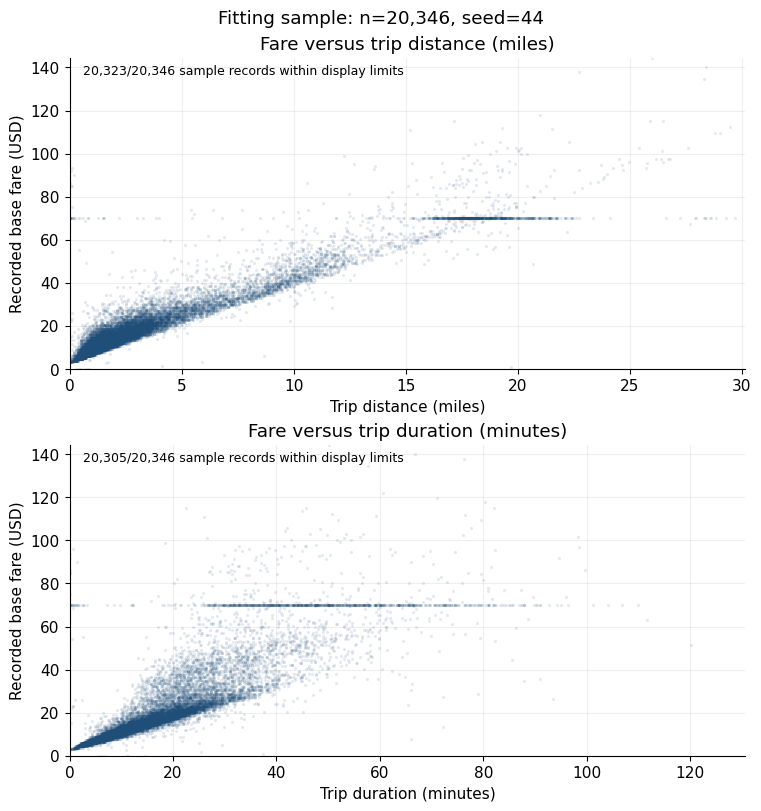

In [30]:
%matplotlib inline

import matplotlib.pyplot as plt

PLOT_SAMPLE_SEED = 44
PLOT_TARGET_RECORDS = 20_000
PLOT_MAX_RECORDS = 25_000

plot_sample_fraction = min(
    1.0, PLOT_TARGET_RECORDS / fit_record_count
)

fit_plot_sample = (
    fit_df
    .select(
        LABEL_COL,
        "trip_distance",
        "trip_duration_minutes",
        "RatecodeID",
    )
    .sample(
        withReplacement=False,
        fraction=plot_sample_fraction,
        seed=PLOT_SAMPLE_SEED,
    )
    .limit(PLOT_MAX_RECORDS)
    .toPandas()
)

plot_sample_count = len(fit_plot_sample)

print(f"Plot sample seed: {PLOT_SAMPLE_SEED}")
print(f"Collected sample records: {plot_sample_count:,}")
print(f"Maximum collection size: {PLOT_MAX_RECORDS:,}")

fare_display_upper = float(
    fit_quantiles[LABEL_COL]["p99_9"]
)

plot_settings = [
    ("trip_distance", "Trip distance (miles)"),
    ("trip_duration_minutes", "Trip duration (minutes)"),
]

with plt.rc_context({"font.size": 11}):
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(7.5, 8),
        sharey=True,
        constrained_layout=True,
    )

    for ax, (column, axis_label) in zip(axes, plot_settings):
        predictor_display_upper = float(
            fit_quantiles[column]["p99_9"]
        )

        in_view = (
            fit_plot_sample[column].between(
                0, predictor_display_upper
            )
            & fit_plot_sample[LABEL_COL].between(
                0, fare_display_upper
            )
        )

        ax.scatter(
            fit_plot_sample[column],
            fit_plot_sample[LABEL_COL],
            s=5,
            alpha=0.12,
            color="#1F4E79",
            linewidths=0,
            rasterized=True,
        )

        ax.set_xlim(0, predictor_display_upper)
        ax.set_ylim(0, fare_display_upper)
        ax.set_xlabel(axis_label)
        ax.set_ylabel("Recorded base fare (USD)")
        ax.set_title(f"Fare versus {axis_label.lower()}")

        ax.text(
            0.02,
            0.98,
            (
                f"{int(in_view.sum()):,}/{plot_sample_count:,} "
                "sample records within display limits"
            ),
            transform=ax.transAxes,
            va="top",
            fontsize=9,
        )

        ax.set_axisbelow(True)
        ax.grid(alpha=0.2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(
        f"Fitting sample: n={plot_sample_count:,}, "
        f"seed={PLOT_SAMPLE_SEED}"
    )

    plt.show()

**Scatter plot interpretation**

The plots use a reproducible sample of `20,346` fitting records, selected
with seed `44`. Collection remained below the 25,000-record limit.

Recorded base fare generally increases with trip distance and duration.
The distance plot shows a relatively concentrated increasing pattern,
while the duration plot shows greater variation in fares at similar
durations. These patterns support retaining both measurements as candidate
predictors, alongside rate type and geographical context.

A horizontal band near `$70` appears in both plots. This is consistent
with the earlier RatecodeID 2 summary, where the fitting subset's lower
quartile, median and upper quartile were all `$70`. The scatter plots alone
do not establish the rate type of individual observations.

The distance panel displays `20,323` sample records within its axis limits,
and the duration panel displays `20,305`. Observations outside these
display limits remain in the underlying fitting data and numerical
analysis. These visual patterns inform feature engineering; model
performance is established through validation metrics.

#### 2.4 Feature Selection and Preprocessing Policy

Feature selection is based on the `19,528,442` fitting records explored
in Sections 2.1–2.3. The objective remains estimating the recorded base
fare of a completed trip, when distance, duration, destination and
final rate code are available.

The following policy is shared by the competing regression models.
Its effectiveness is assessed using validation MAE, RMSE and R².

##### Included source fields

| Source field | Feature representation | Rationale |
|:---|:---|:---|
| `trip_distance` | Upper-capped distance and a capping indicator | After diagnostic capping, its correlation with fare increases from `0.0204` to `0.9271`. Distance is retained while limiting the influence of extreme recorded values. |
| `trip_duration_minutes` | Upper-capped duration and a capping indicator | Its capped correlation with fare is `0.8126`. Duration provides information about elapsed trip time alongside distance. |
| `passenger_count` | Cleaned and median-imputed count, plus an invalid-value indicator | Its marginal correlation is weak at `0.0427`, but this does not establish that it has no conditional predictive value. It is retained as a low-dimensional secondary feature, with explicit handling of missing and nonpositive counts. |
| `tpep_pickup_datetime` | Cyclical hour, weekday and month features | Fitting summaries show differences across pickup times. Cyclical encoding represents adjacency across midnight, week boundaries and year boundaries without treating these boundaries as large numerical jumps. |
| `RatecodeID` | One-hot encoded category | Fare distributions differ substantially between rate types. For example, rate code 1 has a median fare of `$12.80`, while rate code 2 has a median of `$70`. Codes represent categories rather than ordered quantities. |
| `pickup_borough` | One-hot encoded category | Pickup borough summaries show different fare distributions. This provides compact geographical context alongside distance and duration. |
| `dropoff_borough` | One-hot encoded category | Destination borough provides additional route context, including differences between trips ending within and outside Manhattan. |
| `VendorID` | One-hot encoded category | The three observed providers offer a low-dimensional control for differences in recorded trip data. This feature may capture reporting practices, so it is not interpreted as a causal determinant of fare. |

##### Excluded source fields

| Source field or group | Reason for exclusion from the feature vector |
|:---|:---|
| `fare_amount` | This is the prediction target. It is retained for evaluation and excluded from all predictor transformations. |
| `total_amount` | It contains the fare component and would compromise the independence of the fare benchmark. |
| Remaining billing fields | These describe charges or payment amounts associated with the completed bill. The benchmark uses trip characteristics rather than other bill components. |
| `payment_type` | Payment method describes settlement rather than the journey or applicable rate type. It is excluded from this trip-based benchmark. |
| `store_and_fwd_flag` | This describes transmission behaviour. Among nonmissing observations, approximately `99.41%` are `N`, providing little variation in the recorded operational flag. |
| `PULocationID`, `DOLocationID` | Boroughs are selected as the geographical representation for this implementation. The `263` pickup and `261` drop-off categories would add substantially more encoded dimensions. This is a deliberate granularity trade-off for the local environment, with possible loss of information about differences within boroughs. |
| `pickup_zone`, `dropoff_zone` | Zone names describe the same detailed geography represented by the location identifiers. They are excluded alongside that geographical resolution. |
| `pickup_service_zone`, `dropoff_service_zone` | These provide another geographical grouping. Boroughs and rate type are used to keep the representation compact and avoid adding several overlapping geographical descriptions. |
| `pickup_lookup_matched`, `dropoff_lookup_matched` | Both are constant `true` throughout the fitting subset and therefore provide no variation for prediction. |
| `tpep_dropoff_datetime` | Elapsed trip duration already represents the interval between pickup and drop-off. A second set of timestamp features is omitted to keep the temporal representation focused on pickup conditions. |
| `pickup_date` | Pickup calendar features are derived directly from `tpep_pickup_datetime`, so this separate date column is unnecessary for feature construction. |

The excluded billing fields are `extra`, `mta_tax`, `tip_amount`,
`tolls_amount`, `improvement_surcharge`, `congestion_surcharge` and
`airport_fee`.

Exclusion from the feature vector does not delete these fields from the
saved training or streaming subsets.

##### Numerical and categorical preprocessing

**Distance and duration**

The fitting subset's approximate 99.9th percentiles define the upper caps:

- Distance: `30.15` miles.
- Duration: `130.65` minutes.

Separate binary indicators identify observations exceeding each cap.
All eligible records remain available for modelling, and `fare_amount`
remains unchanged.

These caps limit the numerical influence of extreme measurements.
They also reduce detail for legitimate long journeys. The indicators
retain information about membership of the upper tail, while validation
metrics will show the resulting prediction error.

A further binary indicator records an implied speed above 100 mph,
calculated from the original distance and duration. This is a measurement
quality indicator; the unbounded speed ratio is excluded from the vector.

**Passenger count**

Missing, nonfinite, nonpositive or fractional passenger counts will be
converted to null in a derived cleaning column. A binary indicator records
this condition. A Spark `Imputer` will learn the median of valid passenger
counts from the fitting subset and apply that same replacement elsewhere.

**Categorical fields**

Missing or nonfinite rate codes will receive the explicit category
`__MISSING__`. Recorded code 99 remains a separate category, because
its median fare of `$29.50` differs from the `$18.75` median for missing codes.

Borough names will have surrounding whitespace removed. Null or empty
names will receive `__MISSING__`, while the recorded categories `Unknown`
and `N/A` remain separate. Their different fitting fare distributions
support preserving this distinction.

`StringIndexer` will learn category mappings from the fitting subset,
using `handleInvalid="keep"` to retain records containing unseen categories.
`OneHotEncoder` will convert the indices into binary vectors.

**Pickup time**

Hour, weekday and month will each produce a sine and cosine feature,
giving six temporal features. Their periods are 24 hours, seven days and
12 months respectively. Features will use the original pickup timestamp
with the Spark session timezone set to `America/New_York`.

The simulated publication timestamp introduced in Part B will be used
for streaming windows and watermarking.

##### Pipeline sequence and reuse

| Stage | Purpose |
|:---|:---|
| `SQLTransformer` | Create capped measurements, quality indicators, cleaned categories and cyclical time features. |
| `Imputer` | Replace invalid passenger counts using the fitting subset's median. |
| `StringIndexer` | Apply fitted mappings to the four categorical fields. |
| `OneHotEncoder` | Produce categorical feature vectors. |
| `VectorAssembler` | Combine the explicitly selected numerical and categorical features. |
| `StandardScaler` | Scale the assembled predictors using fitting statistics, with `withMean=False` to preserve sparse representations. |

Only predictor values are scaled; the target and predictions remain in USD.

All learned preprocessing stages will be fitted exclusively on `fit_df`.
The same fitted transformations will be applied to validation, final test
and streaming records. The cap values will be embedded in the persisted
pipeline's transformation rules so Part B can reproduce the preprocessing
without recalculating training statistics.

Reference: [Spark 3.5.5 feature transformers](https://archive.apache.org/dist/spark/docs/3.5.5/ml-features.html).

In [31]:
# Record the feature policy before constructing the Spark ML pipeline.
import math

FEATURES_COL = "features"
UNSCALED_FEATURES_COL = "features_unscaled"

# Use the unrounded quantiles already calculated from fitting records.
FEATURE_CAPS = {
    "trip_distance": float(
        fit_quantiles["trip_distance"]["p99_9"]
    ),
    "trip_duration_minutes": float(
        fit_quantiles["trip_duration_minutes"]["p99_9"]
    ),
}

assert all(
    math.isfinite(value) and value > 0
    for value in FEATURE_CAPS.values()
), "Feature caps must be finite and positive."

SPEED_FLAG_THRESHOLD_MPH = 100.0

# Raw fields required to construct predictions.
# The target is deliberately absent.
MODEL_INPUT_COLUMNS = [
    "trip_distance",
    "trip_duration_minutes",
    "passenger_count",
    "tpep_pickup_datetime",
    "RatecodeID",
    "pickup_borough",
    "dropoff_borough",
    "VendorID",
]

# Derived scalar columns that the next section will create.
NUMERIC_FEATURE_COLS = [
    "trip_distance_capped",
    "trip_duration_minutes_capped",
    "passenger_count_imputed",
    "passenger_invalid_flag",
    "distance_capped_flag",
    "duration_capped_flag",
    "speed_anomaly_flag",
    "pickup_hour_sin",
    "pickup_hour_cos",
    "pickup_dow_sin",
    "pickup_dow_cos",
    "pickup_month_sin",
    "pickup_month_cos",
]

CATEGORICAL_FEATURE_COLS = [
    "ratecode_category",
    "pickup_borough_category",
    "dropoff_borough_category",
    "vendor_category",
]

INDEX_FEATURE_COLS = [
    f"{name}_index" for name in CATEGORICAL_FEATURE_COLS
]

OHE_FEATURE_COLS = [
    f"{name}_ohe" for name in CATEGORICAL_FEATURE_COLS
]

ASSEMBLER_INPUT_COLS = (
    NUMERIC_FEATURE_COLS + OHE_FEATURE_COLS
)

# Explicitly account for every saved source column.
EXCLUDED_FEATURE_COLUMNS = [
    LABEL_COL,
    "total_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "congestion_surcharge",
    "airport_fee",
    "payment_type",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID",
    "pickup_zone",
    "dropoff_zone",
    "pickup_service_zone",
    "dropoff_service_zone",
    "pickup_lookup_matched",
    "dropoff_lookup_matched",
    "tpep_dropoff_datetime",
    "pickup_date",
]

input_fields = set(MODEL_INPUT_COLUMNS)
excluded_fields = set(EXCLUDED_FEATURE_COLUMNS)
source_fields = set(fit_df.columns)

assert input_fields.isdisjoint(excluded_fields), (
    "A source field has conflicting inclusion and exclusion decisions."
)

assert source_fields == input_fields | excluded_fields, (
    "Every source column must have an explicit feature decision."
)

assert LABEL_COL not in MODEL_INPUT_COLUMNS
assert LABEL_COL not in ASSEMBLER_INPUT_COLS

feature_cap_table = pd.DataFrame([
    {
        "source_column": name,
        "fitting_quantile": 0.999,
        "upper_cap": value,
    }
    for name, value in FEATURE_CAPS.items()
])

print("Raw model input fields:", len(MODEL_INPUT_COLUMNS))
print("Derived numerical features:", len(NUMERIC_FEATURE_COLS))
print("Categorical feature groups:", len(CATEGORICAL_FEATURE_COLS))
print(
    "Source columns covered by feature decisions:",
    len(input_fields | excluded_fields),
)
print(
    "Final vector width will be verified after fitting "
    "the preprocessing pipeline."
)

display(feature_cap_table.round({"upper_cap": 4}))

Raw model input fields: 8
Derived numerical features: 13
Categorical feature groups: 4
Source columns covered by feature decisions: 29
Final vector width will be verified after fitting the preprocessing pipeline.


,source_column,fitting_quantile,upper_cap
0,trip_distance,0.999,30.15
1,trip_duration_minutes,0.999,130.65


**Feature configuration validated:** The configuration specifies 8 raw
input fields, 13 derived numerical features and 4 categorical
feature groups. All 29 source columns have explicit, nonoverlapping
inclusion or exclusion decisions, and the target is excluded from the
predictor configuration.

The fitting-derived upper caps are `30.15` miles for distance and
`130.65` minutes for duration. These thresholds will be applied
consistently during training, evaluation and streaming inference.

The final feature vector dimension will be confirmed after fitting the
categorical encoders and preprocessing pipeline.

#### 2.5 Build and Fit the Feature Engineering Pipeline

This section implements the feature policy using standard Spark ML
components. All preprocessing stages are contained in a `Pipeline`.

The pipeline is fitted using only the eight selected input fields from
`fit_df`. The target is therefore unavailable to the preprocessing
estimators.

The resulting fitted stages will be shared by the competing regression
models. The selected regressor will subsequently be combined with these
stages to create the complete persisted prediction pipeline.

##### 2.5.1 Deterministic feature construction

A `SQLTransformer` creates the capped measurements, quality indicators,
cleaned categories and cyclical time features.

Distance and duration retain the previously established positive,
finite-value requirements. Passenger counts that fail the documented
validity rules become null for subsequent imputation.

Recorded rate code 99 remains distinct from missing codes. Borough
categories `Unknown` and `N/A` also remain distinct.

The cap values are embedded directly in the SQL statement. The persisted
transformer can therefore apply these rules without accessing the fitting
data or recalculating percentiles.

In [32]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    SQLTransformer,
    Imputer,
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    StandardScaler,
)

assert (
    spark.conf.get("spark.sql.session.timeZone")
    == "America/New_York"
), "Pickup time features require the documented New York timezone."

distance_cap = FEATURE_CAPS["trip_distance"]
duration_cap = FEATURE_CAPS["trip_duration_minutes"]


def finite_column_sql(column_name):
    """Build a finite-value condition for a fixed numeric source field."""
    value = f"CAST(`{column_name}` AS DOUBLE)"

    return (
        f"(`{column_name}` IS NOT NULL "
        f"AND NOT isnan({value}) "
        f"AND abs({value}) < CAST('Infinity' AS DOUBLE))"
    )


distance_valid_sql = (
    f"({finite_column_sql('trip_distance')} "
    "AND trip_distance > 0)"
)

duration_valid_sql = (
    f"({finite_column_sql('trip_duration_minutes')} "
    "AND trip_duration_minutes > 0)"
)

passenger_valid_sql = (
    f"({finite_column_sql('passenger_count')} "
    "AND passenger_count > 0 "
    "AND passenger_count = floor(passenger_count))"
)

derived_sql_expressions = [
    f"""
    CASE WHEN {distance_valid_sql}
        THEN least(
            trip_distance,
            CAST({distance_cap!r} AS DOUBLE)
        )
        ELSE CAST(NULL AS DOUBLE)
    END AS trip_distance_capped
    """,
    f"""
    CASE WHEN {duration_valid_sql}
        THEN least(
            trip_duration_minutes,
            CAST({duration_cap!r} AS DOUBLE)
        )
        ELSE CAST(NULL AS DOUBLE)
    END AS trip_duration_minutes_capped
    """,
    f"""
    CASE WHEN {passenger_valid_sql}
        THEN CAST(passenger_count AS DOUBLE)
        ELSE CAST(NULL AS DOUBLE)
    END AS passenger_count_clean
    """,
    f"""
    CASE WHEN {passenger_valid_sql}
        THEN 0.0 ELSE 1.0
    END AS passenger_invalid_flag
    """,
    f"""
    CASE WHEN trip_distance > {distance_cap!r}
        THEN 1.0 ELSE 0.0
    END AS distance_capped_flag
    """,
    f"""
    CASE WHEN trip_duration_minutes > {duration_cap!r}
        THEN 1.0 ELSE 0.0
    END AS duration_capped_flag
    """,
    f"""
    CASE WHEN {distance_valid_sql} AND {duration_valid_sql}
        AND 60.0 * trip_distance / trip_duration_minutes
            > {SPEED_FLAG_THRESHOLD_MPH!r}
        THEN 1.0 ELSE 0.0
    END AS speed_anomaly_flag
    """,
]

# Numeric identifiers are represented as categorical strings.
for source_name, output_name in [
    ("RatecodeID", "ratecode_category"),
    ("VendorID", "vendor_category"),
]:
    derived_sql_expressions.append(
        f"""
        CASE WHEN {finite_column_sql(source_name)}
            THEN CAST(`{source_name}` AS STRING)
            ELSE '__MISSING__'
        END AS `{output_name}`
        """
    )

# Preserve recorded borough categories while handling missing names.
for source_name, output_name in [
    ("pickup_borough", "pickup_borough_category"),
    ("dropoff_borough", "dropoff_borough_category"),
]:
    derived_sql_expressions.append(
        f"""
        CASE WHEN `{source_name}` IS NULL
            OR trim(`{source_name}`) = ''
            THEN '__MISSING__'
            ELSE trim(`{source_name}`)
        END AS `{output_name}`
        """
    )

# Spark dayofweek uses Sunday = 1; subtract one for a zero-based cycle.
temporal_cycles = [
    ("pickup_hour", "hour(tpep_pickup_datetime)", 24.0),
    (
        "pickup_dow",
        "(dayofweek(tpep_pickup_datetime) - 1)",
        7.0,
    ),
    (
        "pickup_month",
        "(month(tpep_pickup_datetime) - 1)",
        12.0,
    ),
]

for prefix, time_expression, period in temporal_cycles:
    angle_sql = (
        f"2.0 * pi() * {time_expression} / {period}"
    )

    derived_sql_expressions.extend([
        f"sin({angle_sql}) AS {prefix}_sin",
        f"cos({angle_sql}) AS {prefix}_cos",
    ])

feature_sql_statement = (
    "SELECT *,\n"
    + ",\n".join(derived_sql_expressions)
    + "\nFROM __THIS__"
)

feature_sql_transformer = SQLTransformer(
    statement=feature_sql_statement
)

print("SQL-derived columns:", len(derived_sql_expressions))
print("Distance cap:", distance_cap, "miles")
print("Duration cap:", duration_cap, "minutes")

SQL-derived columns: 17
Distance cap: 30.15 miles
Duration cap: 130.65 minutes


##### 2.5.2 Ordered preprocessing stages

`Imputer` learns the median of valid passenger counts. Its approximate
quantile precision uses the same relative error setting as the fitting
exploration.

`StringIndexer` learns mappings for the four categorical fields.
`handleInvalid="keep"` reserves an additional index for categories
not encountered during fitting.

`OneHotEncoder` receives those fitted indices, including the reserved
index. With `dropLast=True`, the reserved final category is represented
by an all-zero categorical vector. Records containing unseen categories
are retained. The encoder's `handleInvalid="error"` checks for unexpected
invalid numerical indices.

`VectorAssembler` combines the explicitly selected inputs in a fixed
order. Its `handleInvalid="error"` reports unexpected invalid numerical
features.

`StandardScaler` learns predictor standard deviations from fitting
records. `withStd=True` scales the assembled vector, while
`withMean=False` avoids converting sparse inputs into dense vectors.

The feature vector's dimension will be calculated from the fitted
encoder sizes and checked against the scaler.

In [33]:
passenger_imputer = Imputer(
    strategy="median",
    inputCols=["passenger_count_clean"],
    outputCols=["passenger_count_imputed"],
    relativeError=QUANTILE_RELATIVE_ERROR,
)

category_indexer = StringIndexer(
    inputCols=CATEGORICAL_FEATURE_COLS,
    outputCols=INDEX_FEATURE_COLS,
    handleInvalid="keep",
    stringOrderType="frequencyDesc",
)

category_encoder = OneHotEncoder(
    inputCols=INDEX_FEATURE_COLS,
    outputCols=OHE_FEATURE_COLS,
    dropLast=True,
    handleInvalid="error",
)

feature_assembler = VectorAssembler(
    inputCols=ASSEMBLER_INPUT_COLS,
    outputCol=UNSCALED_FEATURES_COL,
    handleInvalid="error",
)

feature_scaler = StandardScaler(
    inputCol=UNSCALED_FEATURES_COL,
    outputCol=FEATURES_COL,
    withMean=False,
    withStd=True,
)

feature_pipeline = Pipeline(stages=[
    feature_sql_transformer,
    passenger_imputer,
    category_indexer,
    category_encoder,
    feature_assembler,
    feature_scaler,
])

pipeline_stage_table = pd.DataFrame([
    {
        "stage_order": position,
        "component": type(stage).__name__,
    }
    for position, stage in enumerate(
        feature_pipeline.getStages(),
        start=1,
    )
])

display(pipeline_stage_table)

,stage_order,component
0,1,SQLTransformer
1,2,Imputer
2,3,StringIndexer
3,4,OneHotEncoder
4,5,VectorAssembler
5,6,StandardScaler


##### 2.5.3 Fit preprocessing on the fitting subset

The pipeline learns passenger imputation, category mappings, encoding
dimensions and scaling statistics from the fitting subset only.

The fitting input excludes `fare_amount`. Validation, final test and
streaming records do not participate in learning these transformations.

The outputs below report the actual fitted passenger replacement,
categorical dimensions and final feature vector size.

In [34]:
from time import perf_counter

preprocessing_started = perf_counter()

feature_pipeline_model = feature_pipeline.fit(
    fit_df.select(*MODEL_INPUT_COLUMNS)
)

preprocessing_fit_seconds = (
    perf_counter() - preprocessing_started
)

# Retrieve fitted components in their declared pipeline order.
passenger_imputer_model = feature_pipeline_model.stages[1]
category_indexer_model = feature_pipeline_model.stages[2]
category_encoder_model = feature_pipeline_model.stages[3]
feature_scaler_model = feature_pipeline_model.stages[5]

passenger_imputation_value = float(
    passenger_imputer_model.surrogateDF
    .first()["passenger_count_clean"]
)

assert (
    math.isfinite(passenger_imputation_value)
    and passenger_imputation_value > 0
), "The learned passenger replacement must be finite and positive."

# Encoder categorySizes include the indexer's reserved unseen category.
encoder_category_sizes = [
    int(size)
    for size in category_encoder_model.categorySizes
]

encoded_vector_sizes = [
    size - 1
    for size in encoder_category_sizes
]

FEATURE_VECTOR_SIZE = (
    len(NUMERIC_FEATURE_COLS)
    + sum(encoded_vector_sizes)
)

assert (
    feature_scaler_model.std.size == FEATURE_VECTOR_SIZE
), "Encoder and scaler dimensions do not match."

assert all(
    math.isfinite(float(value))
    for value in feature_scaler_model.std.toArray()
), "The learned scaling statistics contain nonfinite values."

fitted_category_table = pd.DataFrame([
    {
        "categorical_field": name,
        "observed_categories": len(
            category_indexer_model.labelsArray[position]
        ),
        "encoder_categories": encoder_category_sizes[position],
        "encoded_dimensions": encoded_vector_sizes[position],
    }
    for position, name in enumerate(CATEGORICAL_FEATURE_COLS)
])

print(f"Preprocessing fitted on: {fit_record_count:,} records")
print(
    "Preprocessing fitting time:",
    f"{preprocessing_fit_seconds:,.2f} seconds",
)
print("Passenger median replacement:", passenger_imputation_value)
print("Numerical dimensions:", len(NUMERIC_FEATURE_COLS))
print("Encoded categorical dimensions:", sum(encoded_vector_sizes))
print("Final feature vector dimension:", FEATURE_VECTOR_SIZE)

display(fitted_category_table)

Preprocessing fitted on: 19,528,442 records
Preprocessing fitting time: 112.33 seconds
Passenger median replacement: 1.0
Numerical dimensions: 13
Encoded categorical dimensions: 27
Final feature vector dimension: 40


,categorical_field,observed_categories,encoder_categories,encoded_dimensions
0,ratecode_category,8,9,8
1,pickup_borough_category,8,9,8
2,dropoff_borough_category,8,9,8
3,vendor_category,3,4,3


##### 2.5.4 Inspect sample feature vectors

Five fitting records are transformed to inspect the capped measurements,
passenger handling and resulting vectors.

The checks confirm that each sampled vector has the fitted dimension and
contains only finite values. The output schema and abbreviated vectors
are displayed as execution evidence.

These sample checks verify the transformation output. Full fitting and
validation feature preparation follows in the next section.

In [35]:
feature_sample_df = feature_pipeline_model.transform(
    fit_df.select(*MODEL_INPUT_COLUMNS).limit(5)
)

feature_sample_rows = feature_sample_df.select(
    "trip_distance",
    "trip_distance_capped",
    "trip_duration_minutes",
    "trip_duration_minutes_capped",
    "passenger_count",
    "passenger_count_imputed",
    "passenger_invalid_flag",
    FEATURES_COL,
).collect()

assert len(feature_sample_rows) == 5

for row in feature_sample_rows:
    vector = row[FEATURES_COL]

    assert vector is not None
    assert vector.size == FEATURE_VECTOR_SIZE
    assert all(
        math.isfinite(float(value))
        for value in vector.toArray()
    )

measurement_preview = pd.DataFrame([
    {
        "distance_recorded": row["trip_distance"],
        "distance_capped": row["trip_distance_capped"],
        "duration_recorded": row["trip_duration_minutes"],
        "duration_capped": row["trip_duration_minutes_capped"],
    }
    for row in feature_sample_rows
])

feature_preview = pd.DataFrame([
    {
        "sample_row": position,
        "passenger_recorded": row["passenger_count"],
        "passenger_imputed": row["passenger_count_imputed"],
        "passenger_invalid": float(row["passenger_invalid_flag"]),
        "vector_dimension": row[FEATURES_COL].size,
        "nonzero_entries": row[FEATURES_COL].numNonzeros(),
    }
    for position, row in enumerate(
        feature_sample_rows,
        start=1,
    )
])

print("Distance in miles; duration in minutes:")
display(measurement_preview.round(4))

print("Passenger handling and feature vector checks:")
display(feature_preview)

feature_sample_df.select(
    UNSCALED_FEATURES_COL,
    FEATURES_COL,
).printSchema()

feature_sample_df.select(FEATURES_COL).show(
    3,
    truncate=70,
)

print(
    "Sample checks passed:",
    "consistent vector dimensions and finite feature values.",
)

Distance in miles; duration in minutes:


,distance_recorded,distance_capped,duration_recorded,duration_capped
0,1.8,1.8,0.4667,0.4667
1,9.6,9.6,14.9333,14.9333
2,17.9,17.9,0.2667,0.2667
3,17.9,17.9,0.2167,0.2167
4,1.1,1.1,0.4333,0.4333


Passenger handling and feature vector checks:


,sample_row,passenger_recorded,passenger_imputed,passenger_invalid,vector_dimension,nonzero_entries
0,1,1.0,1.0,0.0,40,14
1,2,1.0,1.0,0.0,40,13
2,3,1.0,1.0,0.0,40,14
3,4,1.0,1.0,0.0,40,14
4,5,1.0,1.0,0.0,40,14


root
 |-- features_unscaled: vector (nullable = true)
 |-- features: vector (nullable = true)

+----------------------------------------------------------------------+
|                                                              features|
+----------------------------------------------------------------------+
|(40,[0,1,2,6,7,8,9,10,11,12,18,28,35,38],[0.4012154019821029,0.0342...|
|(40,[0,1,2,7,8,9,10,11,12,17,28,35,38],[2.139815477237882,1.0974028...|
|(40,[0,1,2,6,7,8,9,10,11,12,14,28,35,38],[3.9898642752664673,0.0195...|
+----------------------------------------------------------------------+
only showing top 3 rows

Sample checks passed: consistent vector dimensions and finite feature values.


**Preprocessing results and validation**

The six-stage preprocessing pipeline was fitted on `19,528,442` fitting
records in `112.33` seconds. The learned passenger count replacement
is `1.0`.

The final vector contains `40` dimensions: `13` numerical features and
`27` categorical dimensions. Rate type, pickup borough and drop-off borough
each contribute eight dimensions, while vendor contributes three.
The encoder sizes include the reserved unseen category before the final
category is dropped.

Both `features_unscaled` and `features` have Spark vector types. All five
inspected records produce vectors of the expected dimension with finite
values. Their scaled vectors contain only 13–14 nonzero entries,
consistent with a sparse representation.

The displayed distances and durations are below their respective upper
caps and therefore remain unchanged. Several examples nevertheless
combine substantial distances with very short durations. This illustrates
why the separate speed anomaly indicator is useful: extreme ratios can
occur even when both measurements are below their individual caps.

All five sampled passenger counts are valid values of `1.0`, so their
invalid-value indicators are zero and their counts remain unchanged.
This sample does not demonstrate replacement of an invalid passenger count.

These checks confirm the fitted dimensions and sampled feature validity.
Full fitting and validation feature checks remain to be completed.

#### 2.6 Validate and Prepare the Modelling Features

This section applies the existing fitted preprocessing pipeline to the
fitting and validation subsets.

Two targeted checks first verify passenger replacement and handling of
an unseen borough category. Full-subset checks then confirm:

- Record counts match the internal split.
- Every feature vector has the fitted dimension of 40.
- Feature vectors contain no null, NaN or infinite values.
- Fare labels remain finite and nonnegative.

Only `fare_amount` and the scaled `features` vector are cached for model
comparison. `StorageLevel.DISK_ONLY` is selected because the environment
has a 2 GB driver memory allocation and the fitting subset contains
approximately `19.5 million` records.

The validation aggregation materialises each feature cache. After its
checks pass, the corresponding raw subset cache is released.

The final test subset remains reserved for evaluating the selected model,
and the streaming holdout remains reserved for Part B.

##### 2.6.1 Passenger replacement and unseen-category checks

Five actual fitting records with invalid passenger counts are transformed
to verify that the learned replacement is applied and the indicator is set.

A separate controlled check changes the pickup borough of one fitting
record to a category absent from the fitted mapping. This record is used
only to test `.transform()` behaviour.

In [36]:
# Inspect actual records requiring passenger count replacement.
invalid_passenger_probe_df = feature_pipeline_model.transform(
    fit_df.where(
        ~F.coalesce(
            F.expr(passenger_valid_sql),
            F.lit(False),
        )
    )
    .select(*MODEL_INPUT_COLUMNS)
    .limit(5)
)

invalid_passenger_probe_rows = (
    invalid_passenger_probe_df.select(
        "passenger_count",
        "passenger_count_imputed",
        "passenger_invalid_flag",
        FEATURES_COL,
    ).collect()
)

assert len(invalid_passenger_probe_rows) == 5

for row in invalid_passenger_probe_rows:
    assert float(row["passenger_invalid_flag"]) == 1.0
    assert (
        row["passenger_count_imputed"]
        == passenger_imputation_value
    )
    assert row[FEATURES_COL].size == FEATURE_VECTOR_SIZE
    assert all(
        math.isfinite(float(value))
        for value in row[FEATURES_COL].toArray()
    )

display(pd.DataFrame([
    {
        "passenger_recorded": row["passenger_count"],
        "passenger_imputed": row["passenger_count_imputed"],
        "passenger_invalid": float(row["passenger_invalid_flag"]),
        "vector_dimension": row[FEATURES_COL].size,
    }
    for row in invalid_passenger_probe_rows
]))

# Confirm that an unseen borough is retained by the fitted pipeline.
unseen_borough_label = "__UNSEEN_BOROUGH_CHECK__"
pickup_category_position = CATEGORICAL_FEATURE_COLS.index(
    "pickup_borough_category"
)

pickup_labels = category_indexer_model.labelsArray[
    pickup_category_position
]

assert unseen_borough_label not in pickup_labels

unseen_borough_probe_df = (
    fit_df.select(*MODEL_INPUT_COLUMNS)
    .limit(1)
    .withColumn("pickup_borough", F.lit(unseen_borough_label))
)

unseen_borough_result = (
    feature_pipeline_model.transform(unseen_borough_probe_df)
    .select(
        INDEX_FEATURE_COLS[pickup_category_position],
        OHE_FEATURE_COLS[pickup_category_position],
        FEATURES_COL,
    )
    .first()
)

assert unseen_borough_result is not None
assert (
    unseen_borough_result[
        INDEX_FEATURE_COLS[pickup_category_position]
    ]
    == len(pickup_labels)
)
assert (
    unseen_borough_result[
        OHE_FEATURE_COLS[pickup_category_position]
    ].numNonzeros()
    == 0
)
assert (
    unseen_borough_result[FEATURES_COL].size
    == FEATURE_VECTOR_SIZE
)
assert all(
    math.isfinite(float(value))
    for value in unseen_borough_result[FEATURES_COL].toArray()
)

print("Invalid passenger replacement: passed for 5 records.")
print("Unseen borough handling: passed; the record was retained.")

,passenger_recorded,passenger_imputed,passenger_invalid,vector_dimension
0,0.0,1.0,1.0,40
1,0.0,1.0,1.0,40
2,NaN,1.0,1.0,40
3,NaN,1.0,1.0,40
4,NaN,1.0,1.0,40


Invalid passenger replacement: passed for 5 records.
Unseen borough handling: passed; the record was retained.


**Targeted preprocessing checks passed:** Two records with zero passenger
counts and three with missing counts, displayed as `NaN`, received the
fitting-derived median replacement of `1.0`. Each retained its invalid
passenger indicator and produced a finite, 40-dimensional feature vector.

The controlled unseen borough was assigned the reserved category index
and retained by the pipeline. Its categorical vector used the expected
all-zero representation, and the complete feature vector remained valid.

##### 2.6.2 Full-subset feature validation

The following helper performs distributed checks across every record.
It collects only one summary row per subset.

Feature vectors are temporarily converted to arrays within Spark to
inspect their dimensions and values. These arrays are not cached or
collected to Python. The modelling caches retain the original vector
column.

In [37]:
from pyspark.ml.functions import vector_to_array
from pyspark import StorageLevel


def feature_frame_statistics(feature_frame):
    """Inspect all rows in Spark and collect one summary row."""
    vector_values = F.when(
        F.col(FEATURES_COL).isNotNull(),
        vector_to_array(F.col(FEATURES_COL)),
    ).otherwise(
        F.lit(None).cast("array<double>")
    )

    checking_df = feature_frame.select(
        F.col(LABEL_COL),
        F.col(FEATURES_COL).isNull().alias("_null_vector"),
        vector_values.alias("_feature_values"),
    ).withColumn(
        "_vector_dimension",
        F.when(
            ~F.col("_null_vector"),
            F.size(F.col("_feature_values")),
        ),
    )

    contains_nonfinite = F.exists(
        F.col("_feature_values"),
        lambda value: (
            value.isNull()
            | F.isnan(value)
            | (F.abs(value) == F.lit(float("inf")))
        ),
    )

    label = F.col(LABEL_COL)

    valid_label = F.coalesce(
        label.isNotNull()
        & ~F.isnan(label)
        & (F.abs(label) < F.lit(float("inf")))
        & (label >= 0),
        F.lit(False),
    )

    def count_condition(condition, output_name):
        return F.coalesce(
            F.sum(F.when(condition, 1).otherwise(0)),
            F.lit(0),
        ).alias(output_name)

    return checking_df.agg(
        F.count("*").alias("record_count"),
        F.min("_vector_dimension").alias("min_dimension"),
        F.max("_vector_dimension").alias("max_dimension"),
        count_condition(
            F.col("_null_vector"),
            "null_vectors",
        ),
        count_condition(
            F.col("_vector_dimension") != FEATURE_VECTOR_SIZE,
            "wrong_dimensions",
        ),
        count_condition(
            contains_nonfinite,
            "nonfinite_vectors",
        ),
        count_condition(
            ~valid_label,
            "invalid_labels",
        ),
    ).first().asDict()


def assert_feature_frame(stats, subset_name, expected_count):
    """Require count reconciliation and valid features and labels."""
    assert stats["record_count"] == expected_count, (
        f"{subset_name}: expected {expected_count:,} rows, "
        f"found {stats['record_count']:,}."
    )

    for check_name in [
        "null_vectors",
        "wrong_dimensions",
        "nonfinite_vectors",
        "invalid_labels",
    ]:
        assert stats[check_name] == 0, (
            f"{subset_name}: "
            f"{check_name} = {stats[check_name]:,}."
        )

    assert (
        stats["min_dimension"]
        == stats["max_dimension"]
        == FEATURE_VECTOR_SIZE
    ), f"{subset_name}: inconsistent feature vector dimensions."

##### 2.6.3 Materialise the modelling caches

Both subsets use the same fitted preprocessing stages. The target passes
through unchanged and is retained alongside the resulting feature vector.

Each cache is validated before the corresponding raw cache is released.
These temporary Spark caches support repeated model fitting and evaluation;
they are separate from the model artefact that will be persisted later.

In [38]:
FEATURE_CACHE_STORAGE_LEVEL = StorageLevel.DISK_ONLY


def prepare_feature_subset(source_df, subset_name, expected_count):
    """Transform, cache and validate a modelling subset."""
    print(
        f"Preparing {subset_name.lower()} features "
        f"for {expected_count:,} records...",
        flush=True,
    )

    started = perf_counter()

    feature_frame = (
        feature_pipeline_model.transform(
            source_df.select(
                *MODEL_INPUT_COLUMNS,
                LABEL_COL,
            )
        )
        .select(LABEL_COL, FEATURES_COL)
        .persist(FEATURE_CACHE_STORAGE_LEVEL)
    )

    try:
        stats = feature_frame_statistics(feature_frame)
        assert_feature_frame(
            stats,
            subset_name,
            expected_count,
        )
    except Exception:
        feature_frame.unpersist(blocking=True)
        raise

    # Release the raw cache after the feature cache is materialised.
    source_df.unpersist(blocking=True)

    stats["subset"] = subset_name
    stats["expected_count"] = expected_count
    stats["elapsed_seconds"] = perf_counter() - started

    print(
        f"{subset_name}: {stats['record_count']:,} records verified "
        f"in {stats['elapsed_seconds']:,.2f} seconds.",
        flush=True,
    )

    return feature_frame, stats


fit_features_df, fit_feature_stats = prepare_feature_subset(
    fit_df,
    "Fitting",
    fit_record_count,
)

validation_features_df, validation_feature_stats = (
    prepare_feature_subset(
        validation_df,
        "Validation",
        validation_record_count,
    )
)

assert (
    fit_features_df.schema == validation_features_df.schema
), "Fitting and validation feature schemas differ."

feature_validation_results = [
    fit_feature_stats,
    validation_feature_stats,
]

feature_count_table = pd.DataFrame([
    {
        "subset": stats["subset"],
        "expected_count": stats["expected_count"],
        "feature_count": stats["record_count"],
        "retained_pct": round(
            100.0 * stats["record_count"] / stats["expected_count"],
            4,
        ),
    }
    for stats in feature_validation_results
])

integrity_check_labels = {
    "min_dimension": "Minimum vector dimension",
    "max_dimension": "Maximum vector dimension",
    "null_vectors": "Null feature vectors",
    "wrong_dimensions": "Incorrect vector dimensions",
    "nonfinite_vectors": "Vectors containing nonfinite values",
    "invalid_labels": "Invalid fare labels",
}

feature_integrity_table = pd.DataFrame([
    {
        "subset": stats["subset"],
        "check": description,
        "value": stats[check_name],
    }
    for stats in feature_validation_results
    for check_name, description in integrity_check_labels.items()
])

print("\nRecord count reconciliation:")
display(feature_count_table)

print("Full-subset integrity checks:")
display(feature_integrity_table)

print("Modelling schema:")
fit_features_df.printSchema()

print("Fitting cache:", fit_features_df.storageLevel)
print("Validation cache:", validation_features_df.storageLevel)
print("Raw fitting and validation caches released.")
print("Feature preparation and validation completed.")

Preparing fitting features for 19,528,442 records...
Fitting: 19,528,442 records verified in 205.62 seconds.
Preparing validation features for 4,182,941 records...
Validation: 4,182,941 records verified in 33.96 seconds.

Record count reconciliation:


,subset,expected_count,feature_count,retained_pct
0,Fitting,19528442,19528442,100.0
1,Validation,4182941,4182941,100.0


Full-subset integrity checks:


,subset,check,value
0,Fitting,Minimum vector dimension,40
1,Fitting,Maximum vector dimension,40
2,Fitting,Null feature vectors,0
3,Fitting,Incorrect vector dimensions,0
4,Fitting,Vectors containing nonfinite values,0
5,Fitting,Invalid fare labels,0
6,Validation,Minimum vector dimension,40
7,Validation,Maximum vector dimension,40
8,Validation,Null feature vectors,0
9,Validation,Incorrect vector dimensions,0


Modelling schema:
root
 |-- fare_amount: double (nullable = true)
 |-- features: vector (nullable = true)

Fitting cache: Disk Serialized 1x Replicated
Validation cache: Disk Serialized 1x Replicated
Raw fitting and validation caches released.
Feature preparation and validation completed.


**Feature preparation validated:** The fitting subset contains
`19,528,442` records and the validation subset contains `4,182,941`
records, matching their original counts with 100% retention.

Every feature vector has exactly `40` dimensions. Neither subset contains
null vectors, incorrect vector dimensions, nonfinite feature values, or
invalid fare labels. Both modelling DataFrames have the expected schema:
`fare_amount` as double and `features` as vector.

Feature transformation, cache materialisation and integrity verification
took `205.62` seconds for fitting and `33.96` seconds for validation.
These timings measure feature preparation, rather than regression training.

The verified feature DataFrames are cached using `DISK_ONLY` for reuse
during model comparison. The raw fitting and validation caches have been
released.

### 3. Model Comparison

#### 3.1 Comparison Design and Candidate Configuration

Two regression models will be compared using the same `19,528,442`
fitting records, 40-dimensional feature representation and
`4,182,941` validation records. The preprocessing pipeline was fitted
exclusively on fitting records and will be reused for both candidates.

| Candidate | Rationale for this dataset |
|:--|:--|
| Regularised Linear Regression | Provides an additive baseline for the strong relationships between capped distance, duration and fare. Rate codes and borough indicators allow different baseline fare levels. L2 regularisation limits coefficient magnitude where predictors overlap. |
| Random Forest Regression | Tests whether conditional relationships between distance, duration, rate codes and geography improve predictions. For example, distance may relate differently to standard metered fares and the concentrated $70 fares observed for RatecodeID 2. |

**Linear Regression configuration:** The model uses squared error loss,
an intercept and L2 regularisation with `regParam=0.01`. The normal solver
is suitable for the compact 40-dimensional representation. With
`standardization=False`, regularisation operates on the features already
scaled by the shared preprocessing pipeline.

**Random Forest configuration:** The model uses 20 trees, maximum depth
8 and 32 bins for continuous feature splitting. These settings balance
model flexibility and computation in the `local[2]` environment. Requiring
at least 50 observations in each child node limits splits supported by
very small groups. Bootstrap sampling and the `onethird` feature subset
strategy introduce variation between trees; seed 45 fixes the random
configuration.

`maxMemoryInMB=128` controls the forest's histogram aggregation memory
budget. Overall training memory also includes other data structures.

Both models use the same scaled features. Scaling supports the linear
model and preserves the ordering of continuous values used for tree
splits. These fixed configurations establish a reproducible comparison;
the conclusions will apply to the settings evaluated.

The fitted preprocessing stages will later be combined with the selected
regressor into a complete `PipelineModel`, allowing Part B to transform
raw incoming records using the same feature engineering.

In [39]:
from pyspark.ml.regression import (
    LinearRegression,
    RandomForestRegressor,
)

# Reuse the completed integrity checks without scanning both subsets again.
assert_feature_frame(
    fit_feature_stats,
    "Fitting",
    fit_record_count,
)
assert_feature_frame(
    validation_feature_stats,
    "Validation",
    validation_record_count,
)

assert fit_features_df.schema == validation_features_df.schema
assert fit_features_df.columns == [LABEL_COL, FEATURES_COL]
assert fit_features_df.storageLevel.useDisk
assert validation_features_df.storageLevel.useDisk

MODEL_SEED = 45

CANDIDATE_PARAMETERS = {
    "Linear Regression": {
        "loss": "squaredError",
        "regParam": 0.01,
        "elasticNetParam": 0.0,
        "fitIntercept": True,
        "standardization": False,
        "solver": "normal",
    },
    "Random Forest": {
        "numTrees": 20,
        "maxDepth": 8,
        "maxBins": 32,
        "minInstancesPerNode": 50,
        "impurity": "variance",
        "bootstrap": True,
        "subsamplingRate": 1.0,
        "featureSubsetStrategy": "onethird",
        "maxMemoryInMB": 128,
        "cacheNodeIds": False,
        "seed": MODEL_SEED,
    },
}

candidate_estimators = {
    "Linear Regression": LinearRegression(
        labelCol=LABEL_COL,
        featuresCol=FEATURES_COL,
        predictionCol=PREDICTION_COL,
        **CANDIDATE_PARAMETERS["Linear Regression"],
    ),
    "Random Forest": RandomForestRegressor(
        labelCol=LABEL_COL,
        featuresCol=FEATURES_COL,
        predictionCol=PREDICTION_COL,
        **CANDIDATE_PARAMETERS["Random Forest"],
    ),
}

candidate_parameter_table = pd.DataFrame(
    [
        {
            "candidate": candidate_name,
            "parameter": parameter_name,
            "value": str(parameter_value),
        }
        for candidate_name, parameters in CANDIDATE_PARAMETERS.items()
        for parameter_name, parameter_value in parameters.items()
    ]
)

print(f"Fitting records: {fit_record_count:,}")
print(f"Validation records: {validation_record_count:,}")
print(f"Feature dimensions: {FEATURE_VECTOR_SIZE}")
print(f"Target: {LABEL_COL} (USD)")
print(f"Random Forest seed: {MODEL_SEED}")
print("\nCandidate configurations:")
display(candidate_parameter_table)

Fitting records: 19,528,442
Validation records: 4,182,941
Feature dimensions: 40
Target: fare_amount (USD)
Random Forest seed: 45

Candidate configurations:


,candidate,parameter,value
0,Linear Regression,loss,squaredError
1,Linear Regression,regParam,0.01
2,Linear Regression,elasticNetParam,0.0
3,Linear Regression,fitIntercept,True
4,Linear Regression,standardization,False
5,Linear Regression,solver,normal
6,Random Forest,numTrees,20
7,Random Forest,maxDepth,8
8,Random Forest,maxBins,32
9,Random Forest,minInstancesPerNode,50


**Evaluation and selection policy**

| Metric | Interpretation | Preferred direction |
|:--|:--|:--|
| MAE | Mean absolute difference between predicted and recorded base fare, measured in USD. This directly expresses the average dollar error of the fare benchmark. | Lower |
| RMSE | Error measured in USD, with greater sensitivity to large prediction errors. This complements MAE because unusually large recorded fares remain in the dataset. | Lower |
| R² | Improvement in squared error relative to predicting the evaluation subset's mean fare. Values can be negative when predictions perform worse than this reference. | Higher |

The candidate with the lowest unrounded validation MAE will be
selected. Validation RMSE will resolve an exact MAE tie, while R² will
provide supporting evidence about predictive performance.

Training time will be reported alongside prediction quality to describe
the computational trade-off. It will exclude the shared preprocessing
fit and feature preparation already measured in Section 2.

Both candidates receive the same fitting DataFrame, and all validation
records will be evaluated. Metrics will use each model's returned
predictions directly, with the target remaining in USD.

The final test subset is reserved for evaluating the selected model.
The streaming holdout remains excluded from model training and selection.

In [40]:
from pyspark.ml.evaluation import RegressionEvaluator

regression_evaluators = {
    metric_name: RegressionEvaluator(
        labelCol=LABEL_COL,
        predictionCol=PREDICTION_COL,
        metricName=metric_name,
        throughOrigin=False,
    )
    for metric_name in REGRESSION_METRICS
}

metric_configuration_table = pd.DataFrame(
    [
        {
            "metric": metric_name.upper(),
            "selection_role": (
                "Primary"
                if metric_name == PRIMARY_METRIC
                else (
                    "Exact MAE tie-breaker"
                    if metric_name == "rmse"
                    else "Supporting"
                )
            ),
            "preferred_direction": (
                "Higher"
                if evaluator.isLargerBetter()
                else "Lower"
            ),
        }
        for metric_name, evaluator in regression_evaluators.items()
    ]
)

display(metric_configuration_table)
print("Candidate estimators and regression evaluators configured.")

,metric,selection_role,preferred_direction
0,MAE,Primary,Lower
1,RMSE,Exact MAE tie-breaker,Lower
2,R2,Supporting,Higher


Candidate estimators and regression evaluators configured.


**Comparison configuration verified:** Both regression candidates are
configured to use the same `19,528,442` fitting records, `4,182,941`
validation records and 40-dimensional feature representation.

Linear Regression uses L2 regularisation with `regParam=0.01`.
Random Forest uses the documented configuration with random seed 45.

Model selection will minimise validation MAE, with RMSE resolving
an exact MAE tie. Higher R² will provide supporting evidence.
The final choice will be justified using the measured validation results.

#### 3.2 Model Training and Validation Comparison

Both candidates are trained sequentially on the same cached fitting
features. The fitted preprocessing pipeline is reused, ensuring identical
imputation values, category mappings, feature caps and scaling.

Each fitted model generates predictions for all `4,182,941` validation
records. Before calculating metrics, the evaluation checks that the
prediction count matches the validation count and that every prediction
is finite.

Negative predictions are reported and retained in the evaluation.
This allows the metrics to reflect each model's actual output and
identifies a potential limitation for a non-negative fare target.

Training time measures the estimator's `.fit()` operation. Evaluation
time includes prediction materialisation, prediction integrity checks
and calculation of all three regression metrics. These are observed
execution times for this run and environment.

Only the fare label and prediction are cached during evaluation. This
temporary cache is released after each candidate, while the shared
fitting and validation feature caches remain available.

The final test subset and streaming holdout are excluded from this
comparison.

In [41]:
import math
from time import perf_counter
from pyspark import StorageLevel

# Initialise once before running the two candidate cells.
candidate_models = {}
candidate_training_seconds = {}
candidate_validation_results = {}


def evaluate_regression_model(
    model,
    feature_frame,
    expected_count,
    subset_name,
):
    """Check every prediction and evaluate the complete subset using Spark."""
    started = perf_counter()

    predictions_df = model.transform(feature_frame).select(
        LABEL_COL,
        PREDICTION_COL,
    ).persist(StorageLevel.DISK_ONLY)

    try:
        prediction = F.col(PREDICTION_COL)

        finite_prediction = F.coalesce(
            prediction.isNotNull()
            & ~F.isnan(prediction)
            & (F.abs(prediction) < F.lit(float("inf"))),
            F.lit(False),
        )

        checks = predictions_df.agg(
            F.count("*").alias("evaluated_records"),
            F.count(
                F.when(~finite_prediction, F.lit(1))
            ).alias("invalid_predictions"),
            F.count(
                F.when(prediction < 0, F.lit(1))
            ).alias("negative_predictions"),
        ).first().asDict()

        assert checks["evaluated_records"] == expected_count, (
            f"{subset_name}: expected {expected_count:,} predictions, "
            f"found {checks['evaluated_records']:,}."
        )

        assert checks["invalid_predictions"] == 0, (
            f"{subset_name}: "
            f"{checks['invalid_predictions']:,} invalid predictions."
        )

        metrics = {
            metric_name: float(evaluator.evaluate(predictions_df))
            for metric_name, evaluator in regression_evaluators.items()
        }

        assert all(
            math.isfinite(value) for value in metrics.values()
        ), f"{subset_name}: a regression metric is nonfinite."

        assert metrics["mae"] >= 0 and metrics["rmse"] >= 0

        return {
            **metrics,
            **checks,
            "evaluation_seconds": perf_counter() - started,
        }

    finally:
        predictions_df.unpersist(blocking=True)


def train_and_validate_candidate(candidate_name):
    """Retain the fitted regressor and its full validation results."""
    if candidate_name not in candidate_models:
        print(f"Training {candidate_name}...", flush=True)

        started = perf_counter()

        candidate_models[candidate_name] = (
            candidate_estimators[candidate_name].fit(fit_features_df)
        )

        candidate_training_seconds[candidate_name] = (
            perf_counter() - started
        )
    else:
        print(
            f"Reusing fitted {candidate_name} from this kernel.",
            flush=True,
        )

    print(
        f"Evaluating {candidate_name} on "
        f"{validation_record_count:,} validation records...",
        flush=True,
    )

    evaluation = evaluate_regression_model(
        model=candidate_models[candidate_name],
        feature_frame=validation_features_df,
        expected_count=validation_record_count,
        subset_name=f"{candidate_name} validation",
    )

    result = {
        "candidate": candidate_name,
        "training_seconds": candidate_training_seconds[candidate_name],
        **evaluation,
    }

    candidate_validation_results[candidate_name] = result

    print(f"Training time: {result['training_seconds']:.2f} seconds")
    print(f"Evaluation time: {result['evaluation_seconds']:.2f} seconds")
    print(f"Verified predictions: {result['evaluated_records']:,}")
    print(f"Invalid predictions: {result['invalid_predictions']:,}")
    print(f"Negative predictions: {result['negative_predictions']:,}")
    print(
        f"MAE: ${result['mae']:.4f} | "
        f"RMSE: ${result['rmse']:.4f} | "
        f"R²: {result['r2']:.6f}"
    )

    return result

In [42]:
lr_validation_result = train_and_validate_candidate(
    "Linear Regression"
)

Training Linear Regression...
Evaluating Linear Regression on 4,182,941 validation records...
Training time: 34.44 seconds
Evaluation time: 10.75 seconds
Verified predictions: 4,182,941
Invalid predictions: 0
Negative predictions: 126
MAE: $1.6311 | RMSE: $4.6351 | R²: 0.933440


In [43]:
rf_validation_result = train_and_validate_candidate(
    "Random Forest"
)

Training Random Forest...
Evaluating Random Forest on 4,182,941 validation records...
Training time: 887.47 seconds
Evaluation time: 30.63 seconds
Verified predictions: 4,182,941
Invalid predictions: 0
Negative predictions: 0
MAE: $1.2010 | RMSE: $3.6033 | R²: 0.959775


In [44]:
assert set(candidate_validation_results) == set(candidate_estimators), (
    "Complete training and validation for both candidates first."
)

# Preserve unrounded results for subsequent model selection.
model_comparison_df = pd.DataFrame(
    [
        candidate_validation_results[candidate_name]
        for candidate_name in candidate_estimators
    ]
)

print("Validation model comparison:")
display(
    model_comparison_df[
        ["candidate", "mae", "rmse", "r2"]
    ].rename(
        columns={
            "mae": "MAE (USD)",
            "rmse": "RMSE (USD)",
            "r2": "R²",
        }
    ).round(4)
)

print("\nObserved execution times:")
display(
    model_comparison_df[
        ["candidate", "training_seconds", "evaluation_seconds"]
    ].rename(
        columns={
            "training_seconds": "Training (seconds)",
            "evaluation_seconds": "Evaluation (seconds)",
        }
    ).round(2)
)

print("\nValidation prediction checks:")
display(
    model_comparison_df[
        [
            "candidate",
            "evaluated_records",
            "invalid_predictions",
            "negative_predictions",
        ]
    ]
)

print(
    "\nComparison complete. Unrounded metrics and both fitted "
    "regressors remain available in this kernel."
)

Validation model comparison:


,candidate,MAE (USD),RMSE (USD),R²
0,Linear Regression,1.6311,4.6351,0.9334
1,Random Forest,1.2010,3.6033,0.9598



Observed execution times:


,candidate,Training (seconds),Evaluation (seconds)
0,Linear Regression,34.44,10.75
1,Random Forest,887.47,30.63



Validation prediction checks:


,candidate,evaluated_records,invalid_predictions,negative_predictions
0,Linear Regression,4182941,0,126
1,Random Forest,4182941,0,0



Comparison complete. Unrounded metrics and both fitted regressors remain available in this kernel.


**Validation comparison and interpretation:** Both models produced finite
predictions for all `4,182,941` validation records, with no records
lost during evaluation.

Random Forest achieved the lowest MAE: `$1.2010`, compared with
`$1.6311` for Linear Regression. This reduces average absolute fare
error by approximately `$0.4301` per trip, or `26.37%`.

Random Forest also reduced RMSE from `$4.6351` to `$3.6033`, an
improvement of approximately `22.26%`. The improvement therefore holds
when larger errors receive greater weight. R² increased from
`0.933440` to `0.959775`.

These results favour Random Forest for the completed-trip fare benchmark.
Its stronger performance is consistent with the conditional fare
relationships suggested by the exploration, including the concentrated
`$70` fares for RatecodeID 2 and different fare distributions across
geographic categories.

**Computational trade-off:** Random Forest training took `887.47`
seconds, compared with `34.44` seconds for Linear Regression,
approximately `25.77` times as long. Validation evaluation took
`30.63` seconds for Random Forest and `10.75` seconds for Linear
Regression. These evaluation timings include prediction materialisation,
integrity checks and metric calculation. Streaming latency will be
assessed separately in Part B.

**Prediction plausibility:** Random Forest produced `0` negative
predictions. Linear Regression produced `126`, approximately
`0.0030%` of validation predictions. These predictions remained in the
reported metrics.

Random Forest is preferred because it minimises the primary validation
metric, with supporting improvements in RMSE, R² and prediction
plausibility. The conclusion applies to the configurations evaluated;
the reserved final test subset will provide a further assessment of
generalisation.

#### 3.3 Final Model Selection and Complete Pipeline

The final candidate is selected using the lowest unrounded validation
MAE, with RMSE resolving an exact MAE tie. The comparison in Section 3.2
supports Random Forest, which achieved MAE `$1.2010`, RMSE `$3.6033`
and R² `0.959775`.

The selected fitted regressor is combined with the six fitted
preprocessing stages to create one complete `PipelineModel`. This
preserves the fitting-derived caps, passenger replacement value,
category mappings, encoding and scaling.

The model's input contract consists of the eight fields documented in
`MODEL_INPUT_COLUMNS`, with pickup time interpreted using
`America/New_York`. The recorded fare is required for evaluation but
is excluded from the prediction inputs.

A bounded sample of five fitting records will verify the complete
pipeline. A temporary `verification_id` aligns predictions from the
combined pipeline with predictions from separate preprocessing and
regressor calls. The checks confirm record retention, finite
40-dimensional features, prediction types and agreement between
both execution paths.

In [45]:
from pyspark.ml import PipelineModel

assert set(candidate_validation_results) == set(candidate_estimators)
assert model_comparison_df["candidate"].is_unique

# Sorting uses the original, unrounded metric values.
selection_ranking_df = model_comparison_df.sort_values(
    by=[PRIMARY_METRIC, "rmse"],
    ascending=True,
    kind="stable",
).reset_index(drop=True)

BEST_MODEL_NAME = str(selection_ranking_df.iloc[0]["candidate"])
best_regressor = candidate_models[BEST_MODEL_NAME]
best_validation_result = candidate_validation_results[
    BEST_MODEL_NAME
].copy()

assert best_regressor.getFeaturesCol() == FEATURES_COL
assert best_regressor.getPredictionCol() == PREDICTION_COL
assert best_regressor.numFeatures == FEATURE_VECTOR_SIZE

# Combine the already fitted feature stages and selected regressor.
bestModel = PipelineModel(
    stages=list(feature_pipeline_model.stages) + [best_regressor]
)

assert len(bestModel.stages) == 7
assert len({stage.uid for stage in bestModel.stages}) == 7

best_model_stage_table = pd.DataFrame(
    [
        {
            "stage_order": position,
            "component": type(stage).__name__,
        }
        for position, stage in enumerate(bestModel.stages, start=1)
    ]
)

print(f"Selected candidate: {BEST_MODEL_NAME}")
print(f"Validation MAE: ${best_validation_result['mae']:.6f}")
print(f"Validation RMSE: ${best_validation_result['rmse']:.6f}")
print(f"Validation R²: {best_validation_result['r2']:.6f}")
print(f"Complete pipeline stages: {len(bestModel.stages)}")

display(best_model_stage_table)

Selected candidate: Random Forest
Validation MAE: $1.200988
Validation RMSE: $3.603324
Validation R²: 0.959775
Complete pipeline stages: 7


,stage_order,component
0,1,SQLTransformer
1,2,ImputerModel
2,3,StringIndexerModel
3,4,OneHotEncoderModel
4,5,VectorAssembler
5,6,StandardScalerModel
6,7,RandomForestRegressionModel


In [46]:
from pyspark.sql.types import LongType, StructField, StructType

assert (
    spark.conf.get("spark.sql.session.timeZone")
    == "America/New_York"
)

# Collect only five records containing the eight raw model inputs.
raw_verification_df = fit_df.select(
    *MODEL_INPUT_COLUMNS
).limit(5)

raw_verification_rows = raw_verification_df.collect()
assert len(raw_verification_rows) == 5

verification_schema = StructType(
    list(raw_verification_df.schema.fields)
    + [
        StructField(
            "verification_id",
            LongType(),
            nullable=False,
        )
    ]
)

verification_records = [
    tuple(row) + (index,)
    for index, row in enumerate(raw_verification_rows)
]

# Retain the same small input DataFrame for subsequent reload checks.
model_verification_input_df = spark.createDataFrame(
    verification_records,
    schema=verification_schema,
)

assert LABEL_COL not in model_verification_input_df.columns

print("Verification records:", len(verification_records))
print("Raw feature input fields:", len(MODEL_INPUT_COLUMNS))
print("Verification input columns:", model_verification_input_df.columns)

Verification records: 5
Raw feature input fields: 8
Verification input columns: ['trip_distance', 'trip_duration_minutes', 'passenger_count', 'tpep_pickup_datetime', 'RatecodeID', 'pickup_borough', 'dropoff_borough', 'VendorID', 'verification_id']


In [47]:
from pyspark.ml.linalg import VectorUDT
from pyspark.sql.types import DoubleType

model_verification_output_df = bestModel.transform(
    model_verification_input_df
)

assert isinstance(
    model_verification_output_df.schema[FEATURES_COL].dataType,
    VectorUDT,
)
assert isinstance(
    model_verification_output_df.schema[PREDICTION_COL].dataType,
    DoubleType,
)

model_verification_reference_rows = (
    model_verification_output_df
    .select("verification_id", FEATURES_COL, PREDICTION_COL)
    .orderBy("verification_id")
    .collect()
)

separate_prediction_rows = (
    best_regressor.transform(
        feature_pipeline_model.transform(model_verification_input_df)
    )
    .select("verification_id", PREDICTION_COL)
    .orderBy("verification_id")
    .collect()
)

assert (
    len(model_verification_reference_rows)
    == len(separate_prediction_rows)
    == len(verification_records)
)

pipeline_verification_records = []

for complete_row, separate_row in zip(
    model_verification_reference_rows,
    separate_prediction_rows,
):
    assert (
        complete_row["verification_id"]
        == separate_row["verification_id"]
    )

    vector = complete_row[FEATURES_COL]
    complete_prediction = float(complete_row[PREDICTION_COL])
    separate_prediction = float(separate_row[PREDICTION_COL])

    assert vector is not None and len(vector) == FEATURE_VECTOR_SIZE
    assert all(math.isfinite(float(value)) for value in vector)
    assert math.isfinite(complete_prediction)
    assert math.isfinite(separate_prediction)

    assert math.isclose(
        complete_prediction,
        separate_prediction,
        rel_tol=1e-12,
        abs_tol=1e-12,
    )

    pipeline_verification_records.append(
        {
            "verification_id": complete_row["verification_id"],
            "vector_dimension": len(vector),
            "pipeline_prediction": complete_prediction,
            "separate_prediction": separate_prediction,
            "absolute_difference": abs(
                complete_prediction - separate_prediction
            ),
        }
    )

pipeline_verification_table = pd.DataFrame(
    pipeline_verification_records
)

print("Sample predicted fares in USD:")
display(pipeline_verification_table)

print("\nPrediction output schema:")
model_verification_output_df.select(
    FEATURES_COL,
    PREDICTION_COL,
).printSchema()

print(
    "Complete pipeline verification passed: five records retained, "
    "finite feature vectors and matching predictions."
)

Sample predicted fares in USD:


,verification_id,vector_dimension,pipeline_prediction,separate_prediction,absolute_difference
0,0,40,44.107725,44.107725,0.0
1,1,40,52.399786,52.399786,0.0
2,2,40,71.520337,71.520337,0.0
3,3,40,58.767528,58.767528,0.0
4,4,40,48.921011,48.921011,0.0



Prediction output schema:
root
 |-- features: vector (nullable = true)
 |-- prediction: double (nullable = false)

Complete pipeline verification passed: five records retained, finite feature vectors and matching predictions.


**Complete pipeline verified:** Random Forest was selected using the
unrounded validation metrics: MAE `$1.200988`, RMSE `$3.603324`
and R² `0.959775`.

The assembled pipeline contains all six preprocessing stages followed
by the fitted `RandomForestRegressionModel`.

All five verification records were scored using the eight raw feature
inputs, with `fare_amount` absent. Every resulting feature vector was
finite and contained `40` dimensions. Predictions from the complete
pipeline matched the separate preprocessing and regressor calls, with
an absolute difference of `0.0` for every record.

The output schema confirms `features` as vector and `prediction` as
a non-nullable double. These checks establish consistency of the
assembled prediction path. Generalisation will next be assessed using
the reserved final test subset.

### 4. Evaluation

#### 4.1 Final Test Evaluation

The selected Random Forest pipeline is evaluated on the `4,184,433`
final test records reserved before feature exploration and model
comparison.

The complete pipeline applies feature engineering and prediction to
the raw test inputs. All fitted preprocessing parameters and model
weights remain fixed. The recorded fare is retained solely for
calculating MAE, RMSE and R².

The evaluation verifies prediction count reconciliation and finite
predictions, and reports any negative predictions. Comparing test
metrics with validation metrics assesses consistency of performance
on previously unused records from the approved 2023 dataset.

Test evaluation time includes the full preprocessing pipeline,
prediction materialisation, integrity checks and metric calculation.
Validation evaluation used already prepared features, so the two
timings cover different amounts of work.

In [48]:
assert bestModel.stages[-1].uid == best_regressor.uid
assert best_validation_result["candidate"] == BEST_MODEL_NAME
assert (
    spark.conf.get("spark.sql.session.timeZone")
    == "America/New_York"
)

final_test_input_df = test_df.select(
    *MODEL_INPUT_COLUMNS,
    LABEL_COL,
)

print(f"Selected model: {BEST_MODEL_NAME}")
print(f"Final test records: {test_record_count:,}")
print("Evaluating the complete fitted pipeline...", flush=True)

# Reuse the evaluation helper defined in Section 3.2.
final_test_result = evaluate_regression_model(
    model=bestModel,
    feature_frame=final_test_input_df,
    expected_count=test_record_count,
    subset_name="Final test",
)

print(f"Verified predictions: {final_test_result['evaluated_records']:,}")
print(f"Invalid predictions: {final_test_result['invalid_predictions']:,}")
print(f"Negative predictions: {final_test_result['negative_predictions']:,}")
print(
    f"Complete pipeline evaluation time: "
    f"{final_test_result['evaluation_seconds']:.2f} seconds"
)
print(
    f"MAE: ${final_test_result['mae']:.6f} | "
    f"RMSE: ${final_test_result['rmse']:.6f} | "
    f"R²: {final_test_result['r2']:.6f}"
)

Selected model: Random Forest
Final test records: 4,184,433
Evaluating the complete fitted pipeline...
Verified predictions: 4,184,433
Invalid predictions: 0
Negative predictions: 0
Complete pipeline evaluation time: 35.02 seconds
MAE: $1.231128 | RMSE: $70.077305 | R²: 0.059206


In [49]:
final_evaluation_table = pd.DataFrame(
    [
        {
            "subset": "Validation",
            "mae": best_validation_result["mae"],
            "rmse": best_validation_result["rmse"],
            "r2": best_validation_result["r2"],
        },
        {
            "subset": "Final test",
            "mae": final_test_result["mae"],
            "rmse": final_test_result["rmse"],
            "r2": final_test_result["r2"],
        },
    ]
)

print(f"Selected model: {BEST_MODEL_NAME}")
print("\nValidation and final test metrics:")
display(
    final_evaluation_table.rename(
        columns={
            "mae": "MAE (USD)",
            "rmse": "RMSE (USD)",
            "r2": "R²",
        }
    ).round(6)
)

metric_display_names = {
    "mae": "MAE (USD)",
    "rmse": "RMSE (USD)",
    "r2": "R²",
}

generalisation_gap_table = pd.DataFrame(
    [
        {
            "metric": metric_display_names[metric_name],
            "test_minus_validation": (
                final_test_result[metric_name]
                - best_validation_result[metric_name]
            ),
        }
        for metric_name in REGRESSION_METRICS
    ]
)

print("\nTest minus validation differences:")
display(generalisation_gap_table.round(6))

print(
    "Positive differences indicate higher error for MAE and RMSE; "
    "a positive R² difference indicates improvement."
)

Selected model: Random Forest

Validation and final test metrics:


,subset,MAE (USD),RMSE (USD),R²
0,Validation,1.200988,3.603324,0.959775
1,Final test,1.231128,70.077305,0.059206



Test minus validation differences:


,metric,test_minus_validation
0,MAE (USD),0.030141
1,RMSE (USD),66.473981
2,R²,-0.900569


Positive differences indicate higher error for MAE and RMSE; a positive R² difference indicates improvement.


In [50]:
assert final_test_result["evaluated_records"] == test_record_count
assert final_test_result["invalid_predictions"] == 0

cache_cleanup_records = []

for cache_name, cached_df in [
    ("Fitting features", fit_features_df),
    ("Validation features", validation_features_df),
    ("Raw final test records", test_df),
]:
    cached_df.unpersist(blocking=True)

    cache_released = (
        not cached_df.storageLevel.useDisk
        and not cached_df.storageLevel.useMemory
    )

    assert cache_released, f"{cache_name}: cache was not released."

    cache_cleanup_records.append(
        {
            "cache": cache_name,
            "released": cache_released,
        }
    )

display(pd.DataFrame(cache_cleanup_records))

print(
    "Completed modelling caches released. "
    "The fitted pipeline and evaluation results remain available."
)

,cache,released
0,Fitting features,True
1,Validation features,True
2,Raw final test records,True


Completed modelling caches released. The fitted pipeline and evaluation results remain available.


#### 4.1.1 Final-test error diagnostics

The selected Random Forest achieved a final-test MAE of `$1.231128`,
approximately `2.51%` higher than its validation MAE. However, RMSE
increased from `$3.603324` to `$70.077305`, and R² decreased from
`0.959775` to `0.059206`.

This discrepancy requires investigation. MAE measures average absolute
error, whereas RMSE gives greater weight to large errors. The fitting
subset contained recorded fares as high as `$6,300.90`, so examining
extreme recorded fares and prediction errors is particularly relevant.

The following diagnostic:
- verifies that the full-test metrics can be reproduced;
- summarises the distribution of recorded fares and absolute errors;
- inspects the ten largest prediction errors; and
- measures their contribution to total absolute and squared error.

The selected model and original test subset remain fixed. The full-test
metrics remain the reported evaluation results; these diagnostics support
their interpretation.

In [51]:
import math
from pyspark import StorageLevel

ERROR_QUANTILES = [0.50, 0.95, 0.99, 0.999]
ERROR_QUANTILE_NAMES = ["P50", "P95", "P99", "P99.9"]
TOP_ERROR_COUNT = 10

assert spark.conf.get("spark.sql.session.timeZone") == "America/New_York"

# Retain raw inputs and useful context, without storing feature vectors.
diagnostic_source_columns = list(dict.fromkeys(
    MODEL_INPUT_COLUMNS
    + [LABEL_COL, "PULocationID", "DOLocationID", "total_amount"]
))

print(f"Rechecking {test_record_count:,} final-test records...")

test_error_diagnostics_df = (
    bestModel
    .transform(test_df.select(*diagnostic_source_columns))
    .select(*diagnostic_source_columns, PREDICTION_COL)
    .withColumn(
        "error_usd",
        F.col(PREDICTION_COL) - F.col(LABEL_COL)
    )
    .withColumn("absolute_error_usd", F.abs(F.col("error_usd")))
    .withColumn(
        "squared_error_usd2",
        F.col("error_usd") * F.col("error_usd")
    )
    .persist(StorageLevel.DISK_ONLY)
)

finite_squared_error = F.coalesce(
    F.col("squared_error_usd2").isNotNull()
    & ~F.isnan(F.col("squared_error_usd2"))
    & (F.abs(F.col("squared_error_usd2")) < F.lit(float("inf"))),
    F.lit(False)
)

try:
    test_error_summary = (
        test_error_diagnostics_df
        .agg(
            F.count("*").alias("records"),
            F.count(
                F.when(~finite_squared_error, 1)
            ).alias("invalid_error_rows"),
            F.sum("absolute_error_usd").alias("absolute_error_sum"),
            F.sum("squared_error_usd2").alias("squared_error_sum"),
            F.var_pop(LABEL_COL).alias("fare_variance_pop"),
            F.max(LABEL_COL).alias("maximum_fare"),
            F.max("absolute_error_usd").alias("maximum_absolute_error"),
            F.percentile_approx(
                LABEL_COL, ERROR_QUANTILES, 10000
            ).alias("fare_quantiles"),
            F.percentile_approx(
                "absolute_error_usd", ERROR_QUANTILES, 10000
            ).alias("error_quantiles")
        )
        .first()
        .asDict()
    )

    diagnostic_count = int(test_error_summary["records"])

    assert diagnostic_count == test_record_count
    assert diagnostic_count == final_test_result["evaluated_records"]
    assert test_error_summary["invalid_error_rows"] == 0
    assert test_error_summary["fare_variance_pop"] > 0

    # Reproduce the metrics from aggregated errors.
    # R² uses total label variation around the test-subset mean.
    test_diagnostic_metrics = {
        "mae": (
            test_error_summary["absolute_error_sum"] / diagnostic_count
        ),
        "rmse": math.sqrt(
            test_error_summary["squared_error_sum"] / diagnostic_count
        ),
        "r2": 1.0 - (
            test_error_summary["squared_error_sum"]
            / (
                diagnostic_count
                * test_error_summary["fare_variance_pop"]
            )
        )
    }

    for metric in REGRESSION_METRICS:
        assert math.isclose(
            test_diagnostic_metrics[metric],
            float(final_test_result[metric]),
            rel_tol=1e-6,
            abs_tol=1e-6
        ), f"{metric.upper()} did not reproduce; investigate both values."

    metric_reproduction_table = pd.DataFrame([
        {
            "Metric": metric.upper(),
            "Original result": float(final_test_result[metric]),
            "Recomputed result": test_diagnostic_metrics[metric]
        }
        for metric in REGRESSION_METRICS
    ])

    test_error_distribution_table = pd.DataFrame([
        {
            "Quantity": "Recorded fare (USD)",
            **dict(zip(
                ERROR_QUANTILE_NAMES,
                test_error_summary["fare_quantiles"]
            )),
            "Maximum": test_error_summary["maximum_fare"]
        },
        {
            "Quantity": "Absolute error (USD)",
            **dict(zip(
                ERROR_QUANTILE_NAMES,
                test_error_summary["error_quantiles"]
            )),
            "Maximum": test_error_summary["maximum_absolute_error"]
        }
    ])

    print(f"Verified records: {diagnostic_count:,}")
    print("Invalid error rows:", test_error_summary["invalid_error_rows"])
    print("Full-test metrics reproduced within tolerance.")

    display(metric_reproduction_table.round(6))
    display(test_error_distribution_table.round(6))

except Exception:
    test_error_diagnostics_df.unpersist(blocking=True)
    raise

Rechecking 4,184,433 final-test records...
Verified records: 4,184,433
Invalid error rows: 0
Full-test metrics reproduced within tolerance.


,Metric,Original result,Recomputed result
0,MAE,1.231128,1.231128
1,RMSE,70.077305,70.077305
2,R2,0.059206,0.059206


,Quantity,P50,P95,P99,P99.9,Maximum
0,Recorded fare (USD),13.500000,70.000000,75.200000,144.800000,143163.450000
1,Absolute error (USD),0.556084,3.916701,10.719078,37.057024,143156.708692


In [52]:
try:
    # Spark ranks the records; only ten rows are collected.
    top_test_error_rows = (
        test_error_diagnostics_df
        .orderBy(
            F.desc("squared_error_usd2"),
            F.desc(LABEL_COL),
            F.asc("tpep_pickup_datetime"),
            F.asc("PULocationID"),
            F.asc("DOLocationID")
        )
        .limit(TOP_ERROR_COUNT)
        .collect()
    )

    top_test_errors_table = pd.DataFrame([
        row.asDict() for row in top_test_error_rows
    ])
    top_test_errors_table.insert(
        0, "Error rank", range(1, len(top_test_errors_table) + 1)
    )

    print("Ten largest absolute prediction errors:")

    display(
        top_test_errors_table[
            [
                "Error rank",
                LABEL_COL,
                PREDICTION_COL,
                "absolute_error_usd",
                "trip_distance",
                "trip_duration_minutes",
                "RatecodeID",
                "total_amount"
            ]
        ].round(6)
    )

    concentration_records = []

    for top_k in [1, 5, 10]:
        selected_rows = top_test_error_rows[:top_k]

        absolute_error_sum = math.fsum(
            float(row["absolute_error_usd"]) for row in selected_rows
        )
        squared_error_sum = math.fsum(
            float(row["squared_error_usd2"]) for row in selected_rows
        )

        concentration_records.append({
            "Largest errors included": len(selected_rows),
            "Share of test records (%)": (
                100.0 * len(selected_rows) / diagnostic_count
            ),
            "Absolute error share (%)": (
                100.0 * absolute_error_sum
                / test_error_summary["absolute_error_sum"]
            ),
            "Squared error share (%)": (
                100.0 * squared_error_sum
                / test_error_summary["squared_error_sum"]
            )
        })

    test_error_concentration_table = pd.DataFrame(
        concentration_records
    )

    print("Cumulative contribution to full-test error:")
    display(test_error_concentration_table.round(6))

finally:
    test_error_diagnostics_df.unpersist(blocking=True)
    print("Temporary diagnostic cache released.")

Ten largest absolute prediction errors:


,Error rank,fare_amount,prediction,absolute_error_usd,trip_distance,trip_duration_minutes,RatecodeID,total_amount
0,1,143163.45,6.741308,143156.708692,0.70,4.716667,1.0,143167.45
1,2,850.00,29.821376,820.178624,1.70,0.750000,5.0,851.00
2,3,800.00,44.637525,755.362475,0.20,1.833333,5.0,801.00
3,4,806.60,61.033014,745.566986,13.00,1047.150000,1.0,809.10
4,5,1040.40,365.306283,675.093717,244.33,277.866667,4.0,1079.45
5,6,740.80,80.826098,659.973902,29.97,958.900000,1.0,745.80
6,7,852.10,249.618711,602.481289,124.60,115.366667,4.0,862.40
7,8,800.00,209.562707,590.437293,77.68,110.666667,5.0,807.55
8,9,913.00,349.523548,563.476452,141.71,179.916667,4.0,927.75
9,10,868.90,325.069954,543.830046,128.91,146.966667,4.0,890.75


Cumulative contribution to full-test error:


,Largest errors included,Share of test records (%),Absolute error share (%),Squared error share (%)
0,1,0.000024,2.778893,99.731421
1,5,0.000119,2.837054,99.742394
2,10,0.000239,2.894516,99.750961


Temporary diagnostic cache released.


**Interpretation of final-test diagnostics**

The repeated evaluation reproduced all three original test metrics across
`4,184,433` records, with `0` invalid error rows. The diagnostic therefore
confirms that the reported metric values are reproducible.

The largest error involves a recorded fare of `$143,163.45` for a
`0.70-mile` journey lasting approximately `4.72` minutes. The model predicted
`$6.741308`, producing an absolute error of `$143,156.708692`. The recorded
`total_amount` is also unusually large at `$143,167.45`. This fare greatly
exceeds the fitting-subset maximum of `$6,300.90`. A source recording issue
is a plausible explanation, although confirming its origin would require
external verification.

This single observation contributes `99.731421%` of total squared error
but only `2.778893%` of total absolute error. That concentration explains
why RMSE increased sharply while MAE remained close to validation.
The full-test results are MAE `$1.231128`, RMSE `$70.077305` and
R² `0.059206`. The approximate median absolute error is `$0.556084`,
and the 95th percentile is `$3.916701`, showing that the largest error
is far removed from typical prediction errors.

Other large errors reveal additional limitations. For example, a journey
of `244.33` miles and `277.87` minutes exceeds the fitting-derived
distance and duration caps of `30.15` miles and `130.65` minutes.
The pipeline preserves cap-exceedance indicators, but the capped numerical
features lose the magnitude above those thresholds. This compression may
contribute to inaccurate estimates for exceptionally long journeys.

The original full-test metrics remain the reported evaluation results.
Random Forest remains selected under the predefined validation MAE rule.
The final test documents limitations in predicting extreme recorded fares
and exceptionally long journeys.

### 5. Model Persistence and Verification

#### 5.1 Saving the Selected Pipeline

The selected pipeline is saved to `models/a2_model` using Spark ML's
standard persistence API.

The artefact contains the complete feature engineering sequence and the
trained Random Forest: SQLTransformer, ImputerModel, StringIndexerModel,
OneHotEncoderModel, VectorAssembler, StandardScalerModel and
RandomForestRegressionModel.

Saving the complete pipeline preserves the fitting-derived feature caps,
passenger imputation value, category mappings, scaling statistics and
trained regression model.

This artefact is the direct dependency for Part B. The streaming consumer
will load it with `PipelineModel.load()` and apply `.transform()` to
incoming records. Its Spark SQL timezone must remain
`America/New_York` to preserve the interpretation of pickup-time features.

In [53]:
from time import perf_counter
from pyspark.ml import PipelineModel

MODEL_RELATIVE_PATH = "models/a2_model"
MODEL_PATH = PROJECT_ROOT / MODEL_RELATIVE_PATH

assert isinstance(bestModel, PipelineModel)
assert len(bestModel.stages) == 7
assert bestModel.stages[-1].uid == best_regressor.uid
assert bestModel.stages[-1].numFeatures == FEATURE_VECTOR_SIZE

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

save_started = perf_counter()

bestModel.write().overwrite().save(str(MODEL_PATH))

model_save_seconds = perf_counter() - save_started

assert (MODEL_PATH / "metadata").is_dir()
assert (MODEL_PATH / "stages").is_dir()

saved_model_files = [
    path for path in MODEL_PATH.rglob("*") if path.is_file()
]
saved_model_bytes = sum(
    path.stat().st_size for path in saved_model_files
)

print(f"Selected model: {BEST_MODEL_NAME}")
print(f"Saved pipeline: {MODEL_RELATIVE_PATH}")
print(f"Saved stages: {len(bestModel.stages)}")
print(f"Feature dimensions: {FEATURE_VECTOR_SIZE}")
print(f"Artefact files: {len(saved_model_files)}")
print(f"Artefact size: {saved_model_bytes / (1024 ** 2):.2f} MiB")
print(f"Persistence time: {model_save_seconds:.2f} seconds")

Selected model: Random Forest
Saved pipeline: models/a2_model
Saved stages: 7
Feature dimensions: 40
Artefact files: 56
Artefact size: 0.46 MiB
Persistence time: 17.14 seconds


#### 5.2 Reloading and Verifying the Saved Pipeline

A new PipelineModel is loaded from the saved artefact and applied to the
existing five-record verification sample.

The sample contains the eight raw model input fields and a verification
identifier. It demonstrates that prediction can run without the target
column or precomputed feature vectors.

Verification checks:
- preservation of all seven stages and their identifiers;
- equality of the complete output schema, including metadata;
- retention of all five verification records;
- finite, 40-dimensional feature vectors;
- matching feature values before and after persistence; and
- finite predictions matching the original fitted pipeline.

The expected prediction output is a `double` representing estimated base
fare in USD.

In [54]:
import math
from pyspark.ml.linalg import VectorUDT
from pyspark.sql.types import DoubleType

assert spark.conf.get("spark.sql.session.timeZone") == "America/New_York"
assert LABEL_COL not in model_verification_input_df.columns

# Load a new model instance from disk.
reloaded_best_model = PipelineModel.load(str(MODEL_PATH))

assert len(reloaded_best_model.stages) == 7
assert (
    [type(stage).__name__ for stage in reloaded_best_model.stages]
    == [type(stage).__name__ for stage in bestModel.stages]
)
assert (
    [stage.uid for stage in reloaded_best_model.stages]
    == [stage.uid for stage in bestModel.stages]
)
assert reloaded_best_model.stages[-1].numFeatures == FEATURE_VECTOR_SIZE

# Apply the loaded pipeline directly to raw input fields.
reloaded_verification_df = reloaded_best_model.transform(
    model_verification_input_df
)

reload_schema_matches = (
    reloaded_verification_df.schema.jsonValue()
    == model_verification_output_df.schema.jsonValue()
)
assert reload_schema_matches, "The reloaded output schema changed."

assert isinstance(
    reloaded_verification_df.schema[FEATURES_COL].dataType,
    VectorUDT
)
assert isinstance(
    reloaded_verification_df.schema[PREDICTION_COL].dataType,
    DoubleType
)

reloaded_verification_rows = (
    reloaded_verification_df
    .select("verification_id", FEATURES_COL, PREDICTION_COL)
    .orderBy("verification_id")
    .collect()
)

reference_rows_by_id = {
    int(row["verification_id"]): row
    for row in model_verification_reference_rows
}

assert len(reference_rows_by_id) == 5
assert len(reloaded_verification_rows) == 5
assert {
    int(row["verification_id"]) for row in reloaded_verification_rows
} == set(reference_rows_by_id)

reload_verification_records = []

for loaded_row in reloaded_verification_rows:
    verification_id = int(loaded_row["verification_id"])
    reference_row = reference_rows_by_id[verification_id]

    loaded_vector = loaded_row[FEATURES_COL]
    reference_vector = reference_row[FEATURES_COL]

    assert loaded_vector is not None
    assert loaded_vector.size == FEATURE_VECTOR_SIZE

    loaded_values = loaded_vector.toArray()
    reference_values = reference_vector.toArray()

    assert len(loaded_values) == len(reference_values)
    assert all(
        math.isfinite(float(value)) for value in loaded_values
    )

    feature_values_match = all(
        math.isclose(
            float(loaded_value),
            float(reference_value),
            rel_tol=1e-12,
            abs_tol=1e-12
        )
        for loaded_value, reference_value
        in zip(loaded_values, reference_values)
    )
    assert feature_values_match

    loaded_prediction = float(loaded_row[PREDICTION_COL])
    original_prediction = float(reference_row[PREDICTION_COL])

    assert math.isfinite(loaded_prediction)
    assert math.isclose(
        loaded_prediction,
        original_prediction,
        rel_tol=1e-12,
        abs_tol=1e-12
    )

    reload_verification_records.append({
        "verification_id": verification_id,
        "vector_dimension": loaded_vector.size,
        "feature_values_match": feature_values_match,
        "original_prediction": original_prediction,
        "reloaded_prediction": loaded_prediction,
        "absolute_difference": abs(
            loaded_prediction - original_prediction
        )
    })

reload_verification_table = pd.DataFrame(
    reload_verification_records
)

print(f"Reloaded pipeline: {MODEL_RELATIVE_PATH}")
print(f"Reloaded stages: {len(reloaded_best_model.stages)}")
print(f"Verified records: {len(reloaded_verification_rows)}")
print(f"Complete output schema matches: {reload_schema_matches}")

print("\nPrediction output schema:")
reloaded_verification_df.select(
    FEATURES_COL, PREDICTION_COL
).printSchema()

print("\nSample predicted base fares in USD:")
display(reload_verification_table.round(6))

print(
    "Persistence verification passed: matching schemas, "
    "feature vectors and predictions."
)

Reloaded pipeline: models/a2_model
Reloaded stages: 7
Verified records: 5
Complete output schema matches: True

Prediction output schema:
root
 |-- features: vector (nullable = true)
 |-- prediction: double (nullable = false)


Sample predicted base fares in USD:


,verification_id,vector_dimension,feature_values_match,original_prediction,reloaded_prediction,absolute_difference
0,0,40,True,44.107725,44.107725,0.0
1,1,40,True,52.399786,52.399786,0.0
2,2,40,True,71.520337,71.520337,0.0
3,3,40,True,58.767528,58.767528,0.0
4,4,40,True,48.921011,48.921011,0.0


Persistence verification passed: matching schemas, feature vectors and predictions.


## Part B: Streaming, Kafka and Reflection

### 1. Streaming Data Simulation

#### 1.1 Replay Design

Part B simulates newly arriving completed taxi trips by replaying records
from the saved streaming holdout, `data/stream_data.parquet`.

The consumer will load the complete persisted pipeline from
`models/a2_model`. It will apply the saved preprocessing stages and Random
Forest to incoming records without retraining.

Each Kafka message will contain one JSON array of trip records. The
producer will send batches of `1,000` records by default, with an exact
five-second pause between batches. Batch size will be parameterised.

The local demonstration will replay up to `60` batches, representing
`60,000` held-out trips. This requires `295` seconds of pauses, plus reading,
serialisation and Kafka delivery time. The complete streaming holdout
remains available for a full replay.

Two timestamps have different purposes:

- `tpep_pickup_datetime` preserves the original historical pickup time
  used by the model's temporal features.
- `event_timestamp` records the batch publication time and will drive
  streaming windows and watermarking.

Both timestamps will be transmitted as ISO 8601 strings with an explicit
UTC offset. The consumer will convert them to Spark timestamps while
retaining the `America/New_York` session timezone used in Part A.

Windowed results will describe the count and average predicted base fare
of replayed events. Their time axis represents simulated arrival time.

#### 1.2 Explicit Message Contract

Each outgoing record contains the eight raw model inputs, the observed
`fare_amount` for inspection, and the new `event_timestamp`.

The observed fare is excluded from the feature vector. Predictions
continue to depend only on the eight inputs established in Part A.

The JSON schema is declared explicitly as an array of structures.
Timestamp fields are initially parsed as strings and will be converted
to timestamp columns in the consumer.

`RatecodeID` must retain its double type, and `VendorID` must retain its
long integer type. This preserves their string representations when the
saved preprocessing pipeline constructs categorical features.

Missing numerical values will be serialised as JSON `null`. The saved
pipeline already handles missing passenger counts and rate codes.

In [67]:
from pyspark.sql.types import (
    ArrayType,
    DoubleType,
    LongType,
    StringType,
    StructField,
    StructType,
)

# Shared settings for the producer demonstration and streaming consumer.
STREAM_BOOTSTRAP_SERVERS = "kafka:9092"
STREAM_TOPIC = "a2_taxi_events"

STREAM_BATCH_SIZE = 1000
STREAM_PAUSE_SECONDS = 5
STREAM_DEMO_BATCH_LIMIT = 60
STREAM_TRIGGER_INTERVAL = "5 seconds"

# Existing artefacts created and verified in Part A.
STREAM_DATA_PATH = PROJECT_ROOT / "data/stream_data.parquet"
STREAM_MODEL_PATH = PROJECT_ROOT / "models/a2_model"
STREAM_SPLIT_METADATA_PATH = PROJECT_ROOT / "data/split_metadata.json"

# Schema of one record inside the producer's JSON array.
STREAM_EVENT_SCHEMA = StructType([
    StructField("trip_distance", DoubleType(), True),
    StructField("trip_duration_minutes", DoubleType(), True),
    StructField("passenger_count", DoubleType(), True),
    StructField("tpep_pickup_datetime", StringType(), True),
    StructField("RatecodeID", DoubleType(), True),
    StructField("pickup_borough", StringType(), True),
    StructField("dropoff_borough", StringType(), True),
    StructField("VendorID", LongType(), True),
    StructField("fare_amount", DoubleType(), True),
    StructField("event_timestamp", StringType(), True),
])

# One Kafka message contains an array, rather than one individual record.
STREAM_BATCH_SCHEMA = ArrayType(
    STREAM_EVENT_SCHEMA,
    containsNull=False,
)

STREAM_SOURCE_COLUMNS = [
    field.name
    for field in STREAM_EVENT_SCHEMA.fields
    if field.name != "event_timestamp"
]

STREAM_MODEL_INPUT_COLUMNS = [
    column
    for column in STREAM_SOURCE_COLUMNS
    if column != "fare_amount"
]

assert len(STREAM_MODEL_INPUT_COLUMNS) == 8

display(pd.DataFrame([
    {
        "JSON field": field.name,
        "Declared JSON parsing type": field.dataType.simpleString(),
        "Consumer type": (
            "timestamp"
            if field.name in {
                "tpep_pickup_datetime",
                "event_timestamp",
            }
            else field.dataType.simpleString()
        ),
    }
    for field in STREAM_EVENT_SCHEMA.fields
]))

print("Kafka topic:", STREAM_TOPIC)
print("Bootstrap servers:", STREAM_BOOTSTRAP_SERVERS)
print("Default records per batch:", STREAM_BATCH_SIZE)
print("Pause between batches:", STREAM_PAUSE_SECONDS, "seconds")
print("Consumer trigger interval:", STREAM_TRIGGER_INTERVAL)

,JSON field,Declared JSON parsing type,Consumer type
0,trip_distance,double,double
1,trip_duration_minutes,double,double
2,passenger_count,double,double
3,tpep_pickup_datetime,string,timestamp
4,RatecodeID,double,double
5,pickup_borough,string,string
6,dropoff_borough,string,string
7,VendorID,bigint,bigint
8,fare_amount,double,double
9,event_timestamp,string,timestamp


Kafka topic: a2_taxi_events
Bootstrap servers: kafka:9092
Default records per batch: 1000
Pause between batches: 5 seconds
Consumer trigger interval: 5 seconds


#### 1.3 Saved Data and Model Readiness Checks

Before implementing the producer, the following checks confirm that:

- the saved streaming dataset and split metadata exist;
- the persisted source columns have the expected types;
- Parquet footer record counts match the saved split metadata;
- the active Spark version and timezone match the preparation environment;
- the saved model reloads as the complete seven-stage pipeline; and
- the regression model expects the established 40-dimensional feature vector.

Record counts are obtained from Parquet file metadata, avoiding another
full scan of the streaming holdout.

These checks inspect artefact integrity and configuration. Streaming
predictions will be generated after the Kafka consumer is implemented.

In [68]:
import json
import math
import pyarrow as pa
import pyarrow.parquet as pq

from pyspark.ml import PipelineModel

assert STREAM_DATA_PATH.is_dir(), (
    "Missing saved streaming dataset: data/stream_data.parquet."
)
assert STREAM_MODEL_PATH.is_dir(), (
    "Missing saved Part A pipeline: models/a2_model."
)
assert STREAM_SPLIT_METADATA_PATH.is_file(), (
    "Missing split metadata: data/split_metadata.json."
)

stream_split_metadata = json.loads(
    STREAM_SPLIT_METADATA_PATH.read_text(encoding="utf-8")
)

assert spark.version == stream_split_metadata["spark_version"] == "3.5.5"
assert (
    spark.conf.get("spark.sql.session.timeZone")
    == stream_split_metadata["session_timezone"]
    == "America/New_York"
)

metadata_stream_path = (
    PROJECT_ROOT
    / stream_split_metadata["streaming_holdout"]["path"]
).resolve()

assert STREAM_DATA_PATH.resolve() == metadata_stream_path

# Check the persisted Parquet schema without collecting trip records.
stream_source_schema_df = spark.read.parquet(str(STREAM_DATA_PATH))

expected_source_types = {
    "trip_distance": "double",
    "trip_duration_minutes": "double",
    "passenger_count": "double",
    "tpep_pickup_datetime": "timestamp",
    "RatecodeID": "double",
    "pickup_borough": "string",
    "dropoff_borough": "string",
    "VendorID": "bigint",
    "fare_amount": "double",
}

actual_source_types = {
    field.name: field.dataType.simpleString()
    for field in stream_source_schema_df.schema.fields
}

source_type_mismatches = {
    column: {
        "expected": expected_type,
        "actual": actual_source_types.get(column),
    }
    for column, expected_type in expected_source_types.items()
    if actual_source_types.get(column) != expected_type
}

assert not source_type_mismatches, (
    f"Streaming source schema mismatch: {source_type_mismatches}"
)

# Read row counts from Parquet footers, rather than scanning all rows.
stream_parquet_files = sorted(
    STREAM_DATA_PATH.rglob("part-*.parquet")
)

assert stream_parquet_files, "No streaming Parquet part files found."

stream_footer_record_count = sum(
    pq.ParquetFile(path).metadata.num_rows
    for path in stream_parquet_files
)

expected_stream_record_count = int(
    stream_split_metadata["streaming_holdout"]["record_count"]
)

assert stream_footer_record_count == expected_stream_record_count, (
    f"Streaming count mismatch: metadata expects "
    f"{expected_stream_record_count:,}, but Parquet footers report "
    f"{stream_footer_record_count:,}."
)

# Load the saved artefact directly for Part B inference.
streaming_model = PipelineModel.load(str(STREAM_MODEL_PATH))

expected_streaming_stages = [
    "SQLTransformer",
    "ImputerModel",
    "StringIndexerModel",
    "OneHotEncoderModel",
    "VectorAssembler",
    "StandardScalerModel",
    "RandomForestRegressionModel",
]

actual_streaming_stages = [
    stage.__class__.__name__
    for stage in streaming_model.stages
]

assert actual_streaming_stages == expected_streaming_stages
assert streaming_model.stages[-1].numFeatures == 40

demo_record_count = min(
    stream_footer_record_count,
    STREAM_BATCH_SIZE * STREAM_DEMO_BATCH_LIMIT,
)

demo_batch_count = math.ceil(
    demo_record_count / STREAM_BATCH_SIZE
)

full_replay_batch_count = math.ceil(
    stream_footer_record_count / STREAM_BATCH_SIZE
)

demo_pause_seconds = (
    max(0, demo_batch_count - 1) * STREAM_PAUSE_SECONDS
)

full_replay_pause_hours = (
    max(0, full_replay_batch_count - 1)
    * STREAM_PAUSE_SECONDS
    / 3600
)

print("PyArrow version:", pa.__version__)
print("Streaming Parquet files:", len(stream_parquet_files))
print(f"Verified held-out records: {stream_footer_record_count:,}")
print("Required source column types: passed")
print("Loaded pipeline stages:", len(streaming_model.stages))
print("Expected feature dimensions:", streaming_model.stages[-1].numFeatures)
print("Spark version and timezone: passed")

display(pd.DataFrame({
    "stage_order": range(1, len(actual_streaming_stages) + 1),
    "component": actual_streaming_stages,
}))

print(f"Demonstration records: {demo_record_count:,}")
print("Demonstration batches:", demo_batch_count)
print("Demonstration pause time:", demo_pause_seconds, "seconds")
print(
    "Full replay pause time:",
    f"{full_replay_pause_hours:.2f} hours",
    "(excluding reading, serialisation and delivery)",
)

print("Part B data and model readiness checks passed.")

PyArrow version: 23.0.1
Streaming Parquet files: 17
Verified held-out records: 9,296,344
Required source column types: passed
Loaded pipeline stages: 7
Expected feature dimensions: 40
Spark version and timezone: passed


,stage_order,component
0,1,SQLTransformer
1,2,ImputerModel
2,3,StringIndexerModel
3,4,OneHotEncoderModel
4,5,VectorAssembler
5,6,StandardScalerModel
6,7,RandomForestRegressionModel


Demonstration records: 60,000
Demonstration batches: 60
Demonstration pause time: 295 seconds
Full replay pause time: 12.91 hours (excluding reading, serialisation and delivery)
Part B data and model readiness checks passed.


##### Readiness Interpretation

The saved streaming holdout contains `9,296,344` records across `17`
Parquet files, matching the split metadata. All required source column
types are correct.

The complete persisted pipeline reloads with seven stages and expects
`40` feature dimensions. Spark version and session timezone match the
Part A environment.

The demonstration is configured for `60` batches of `1,000` records,
giving `60,000` held-out events and `295` seconds of pauses. Replaying
the entire holdout would require `12.91` hours of pauses, excluding
reading, serialisation and delivery time.

### 2. Kafka Producer

#### 2.1 Producer Implementation

The standalone `producer.py` script reads the saved streaming holdout
using bounded PyArrow batches. Incomplete batches are carried across
Parquet files, preserving all records during a complete replay.

Each batch becomes one UTF-8 JSON array. Every record receives the same
UTC `event_timestamp`, captured immediately before publication.

The producer waits for a Kafka acknowledgement before logging a successful
batch. Logs include the batch number, record count, publication timestamp,
payload size, partition, offset and cumulative record count.

An exact five-second sleep occurs between published batches. Actual
publication intervals also include reading, serialisation and delivery
time.

Batch size, topic, broker address and replay limit are command-line
parameters. The default demonstration sends up to 60 batches of 1,000
records. Setting `--max-batches 0` enables a complete replay.

A 900,000-byte payload limit detects oversized messages before sending.
The producer preserves recorded feature values; preprocessing remains
inside the persisted model.

In [69]:
%%writefile producer.py
"""Replay the saved Assessment 2 holdout as JSON-array Kafka messages."""

import argparse
import json
import math
import sys
import time
from datetime import datetime, timezone
from itertools import islice
from pathlib import Path

import pyarrow.parquet as pq


PROJECT_ROOT = Path(__file__).resolve().parent
PAUSE_SECONDS = 5
MAX_PAYLOAD_BYTES = 900_000

SOURCE_COLUMNS = [
    "trip_distance",
    "trip_duration_minutes",
    "passenger_count",
    "tpep_pickup_datetime",
    "RatecodeID",
    "pickup_borough",
    "dropoff_borough",
    "VendorID",
    "fare_amount",
]


def finite_float_or_none(value):
    """Preserve finite numbers and encode missing/nonfinite values as null."""
    if value is None:
        return None
    number = float(value)
    return number if math.isfinite(number) else None


def pickup_timestamp_as_utc(value):
    """Preserve the instant stored in Spark's timestamp Parquet column."""
    if not isinstance(value, datetime):
        raise ValueError("The saved pickup timestamp is missing or invalid.")
    if value.tzinfo is None:
        # Direct Parquet reads expose Spark's stored UTC instant.
        value = value.replace(tzinfo=timezone.utc)
    return value.astimezone(timezone.utc).isoformat(timespec="microseconds")


def prepare_record(row):
    """Keep source values; feature engineering belongs to the saved model."""
    record = {
        "trip_distance": finite_float_or_none(row["trip_distance"]),
        "trip_duration_minutes": finite_float_or_none(
            row["trip_duration_minutes"]
        ),
        "passenger_count": finite_float_or_none(row["passenger_count"]),
        "tpep_pickup_datetime": pickup_timestamp_as_utc(
            row["tpep_pickup_datetime"]
        ),
        "RatecodeID": finite_float_or_none(row["RatecodeID"]),
        "pickup_borough": row["pickup_borough"],
        "dropoff_borough": row["dropoff_borough"],
        "VendorID": (
            None if row["VendorID"] is None else int(row["VendorID"])
        ),
        "fare_amount": finite_float_or_none(row["fare_amount"]),
    }
    for column in ["trip_distance", "trip_duration_minutes", "fare_amount"]:
        if record[column] is None:
            raise ValueError(f"Saved record has an invalid {column}.")
    return record


def iter_record_batches(parquet_files, batch_size):
    """Read bounded batches and carry incomplete batches across files."""
    pending = []
    for path in parquet_files:
        parquet_file = pq.ParquetFile(
            path,
            coerce_int96_timestamp_unit="us",
        )
        try:
            missing = set(SOURCE_COLUMNS) - set(parquet_file.schema_arrow.names)
            if missing:
                raise ValueError(f"{path.name} is missing columns: {sorted(missing)}")
            for arrow_batch in parquet_file.iter_batches(
                batch_size=batch_size,
                columns=SOURCE_COLUMNS,
            ):
                for row in arrow_batch.to_pylist():
                    pending.append(prepare_record(row))
                    if len(pending) == batch_size:
                        yield pending
                        pending = []
        finally:
            parquet_file.close()
    if pending:
        yield pending


def log_event(action, **fields):
    """Write one structured log entry to stdout."""
    print(json.dumps({"action": action, **fields}, allow_nan=False), flush=True)


def parse_arguments(argv=None):
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument(
        "--data-path", type=Path,
        default=PROJECT_ROOT / "data/stream_data.parquet",
    )
    parser.add_argument("--bootstrap-servers", default="kafka:9092")
    parser.add_argument("--topic", default="a2_taxi_events")
    parser.add_argument("--batch-size", type=int, default=1000)
    parser.add_argument(
        "--max-batches", type=int, default=60,
        help="Maximum batches to replay; use 0 for the complete holdout.",
    )
    parser.add_argument(
        "--dry-run", action="store_true",
        help="Inspect JSON batches locally without Kafka or timing pauses.",
    )
    args = parser.parse_args(argv)
    if args.batch_size <= 0:
        parser.error("--batch-size must be positive.")
    if args.max_batches < 0:
        parser.error("--max-batches must be zero or positive.")
    return args


def main(argv=None):
    args = parse_arguments(argv)
    parquet_files = sorted(args.data_path.rglob("part-*.parquet"))
    if not parquet_files:
        raise FileNotFoundError(f"No saved Parquet part files in {args.data_path}.")

    producer = None
    if not args.dry_run:
        from kafka import KafkaProducer

        producer = KafkaProducer(
            bootstrap_servers=args.bootstrap_servers.split(","),
            client_id="ito5202-a2-producer",
            acks="all",
            max_in_flight_requests_per_connection=1,
            max_request_size=1_048_576,
            request_timeout_ms=20_000,
            delivery_timeout_ms=30_000,
            max_block_ms=20_000,
            allow_auto_create_topics=False,
        )

    source_batches = iter_record_batches(parquet_files, args.batch_size)
    batches = (
        islice(source_batches, args.max_batches)
        if args.max_batches else source_batches
    )
    record_count = 0
    batch_count = 0
    previous_batch_started = None
    started = time.perf_counter()
    log_event(
        "started", dry_run=args.dry_run, topic=args.topic,
        source_files=len(parquet_files), batch_size=args.batch_size,
        max_batches=args.max_batches, pause_seconds=PAUSE_SECONDS,
    )

    try:
        for batch_number, records in enumerate(batches, start=1):
            if not args.dry_run and batch_number > 1:
                time.sleep(PAUSE_SECONDS)

            batch_started = time.perf_counter()
            publication_time = datetime.now(timezone.utc)
            event_timestamp = publication_time.isoformat(timespec="microseconds")
            for record in records:
                record["event_timestamp"] = event_timestamp

            payload = json.dumps(
                records, ensure_ascii=False, allow_nan=False,
                separators=(",", ":"),
            ).encode("utf-8")
            if len(payload) > MAX_PAYLOAD_BYTES:
                raise ValueError(
                    f"Payload has {len(payload):,} bytes, exceeding the "
                    f"{MAX_PAYLOAD_BYTES:,}-byte limit. Reduce --batch-size."
                )

            delivery = {}
            if producer is not None:
                send_started = time.perf_counter()
                metadata = producer.send(
                    args.topic, value=payload,
                    timestamp_ms=int(publication_time.timestamp() * 1000),
                ).get(timeout=35)
                delivery = {
                    "partition": metadata.partition,
                    "offset": metadata.offset,
                    "delivery_seconds": round(
                        time.perf_counter() - send_started, 6
                    ),
                }

            record_count += len(records)
            batch_count += 1
            log_event(
                "dry_run_batch" if args.dry_run else "published_batch",
                batch=batch_number, records=len(records),
                event_timestamp=event_timestamp, topic=args.topic,
                payload_bytes=len(payload), cumulative_records=record_count,
                interval_seconds=(
                    None if previous_batch_started is None
                    else round(batch_started - previous_batch_started, 6)
                ),
                **delivery,
            )
            if args.dry_run and batch_number == 1:
                log_event("preview", record=records[0])
            previous_batch_started = batch_started
        if batch_count == 0:
            raise ValueError("The saved streaming dataset contains no records.")
    finally:
        source_batches.close()
        if producer is not None:
            producer.close(timeout=10)

    log_event(
        "completed", dry_run=args.dry_run,
        batches=batch_count, records_processed=record_count,
        elapsed_seconds=round(time.perf_counter() - started, 3),
    )


if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        log_event("interrupted")
        sys.exit(130)
    except Exception as error:
        print(
            json.dumps({"action": "error", "message": str(error)}),
            file=sys.stderr, flush=True,
        )
        sys.exit(1)

Overwriting producer.py


#### 2.2 Local Dry Run and Payload Validation

A two-batch dry run checks the actual saved streaming data before Kafka
publication. This mode performs reading and JSON serialisation locally.

The checks confirm:

- successful standalone script execution;
- two batches containing 1,000 records each;
- a ten-field record matching the explicitly declared message contract;
- successful parsing with the declared JSON array schema; and
- preservation of the original pickup timestamp through serialisation.

Preserving the pickup instant prevents a timezone shift from changing the
model's temporal features. Kafka delivery and publication timing will be
verified separately using an actual producer session.

In [70]:
import subprocess
import sys

producer_path = PROJECT_ROOT / "producer.py"
assert producer_path.is_file(), "Run the producer creation cell first."

producer_dry_run = subprocess.run(
    [
        sys.executable,
        str(producer_path),
        "--data-path", str(STREAM_DATA_PATH),
        "--bootstrap-servers", STREAM_BOOTSTRAP_SERVERS,
        "--topic", STREAM_TOPIC,
        "--batch-size", str(STREAM_BATCH_SIZE),
        "--max-batches", "2",
        "--dry-run",
    ],
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True,
)

if producer_dry_run.returncode != 0:
    print(producer_dry_run.stdout)
    print(producer_dry_run.stderr)
    producer_dry_run.check_returncode()

producer_dry_logs = [
    json.loads(line)
    for line in producer_dry_run.stdout.splitlines()
    if line.strip()
]

producer_dry_batches = [
    entry
    for entry in producer_dry_logs
    if entry["action"] == "dry_run_batch"
]

producer_preview = next(
    entry["record"]
    for entry in producer_dry_logs
    if entry["action"] == "preview"
)

assert len(producer_dry_batches) == 2
assert all(
    entry["records"] == STREAM_BATCH_SIZE
    for entry in producer_dry_batches
)
assert set(producer_preview) == {
    field.name for field in STREAM_EVENT_SCHEMA.fields
}

print("Producer script:", producer_path.name)
print("Dry-run exit code:", producer_dry_run.returncode)

display(pd.DataFrame(producer_dry_batches)[[
    "batch",
    "records",
    "event_timestamp",
    "payload_bytes",
    "cumulative_records",
]])

print("First outgoing record:")
display(pd.DataFrame(
    list(producer_preview.items()),
    columns=["JSON field", "Preview value"],
))

print("Dry-run batching and record field checks passed.")

Producer script: producer.py
Dry-run exit code: 0


,batch,records,event_timestamp,payload_bytes,cumulative_records
0,1,1000,2026-10-06T08:36:09.821766+00:00,296790,1000
1,2,1000,2026-10-06T08:36:09.851468+00:00,298138,2000


First outgoing record:


,JSON field,Preview value
0,trip_distance,0.1
1,trip_duration_minutes,1.016667
2,passenger_count,0.0
3,tpep_pickup_datetime,2023-01-02T12:40:41.000000+00:00
4,RatecodeID,5.0
5,pickup_borough,EWR
6,dropoff_borough,EWR
7,VendorID,1
8,fare_amount,0.0
9,event_timestamp,2026-10-06T08:36:09.821766+00:00


Dry-run batching and record field checks passed.


In [71]:
STREAM_TIMESTAMP_FORMAT = "yyyy-MM-dd'T'HH:mm:ss.SSSSSSXXX"

producer_preview_json = json.dumps(
    [producer_preview],
    allow_nan=False,
)

producer_preview_df = (
    spark.createDataFrame(
        [(producer_preview_json,)],
        "payload string",
    )
    .select(
        F.explode(
            F.from_json(
                F.col("payload"),
                STREAM_BATCH_SCHEMA,
                options={
                    "mode": "FAILFAST",
                    "allowNonNumericNumbers": "false",
                },
            )
        ).alias("event")
    )
    .select("event.*")
    .withColumn(
        "tpep_pickup_datetime",
        F.to_timestamp(
            "tpep_pickup_datetime",
            STREAM_TIMESTAMP_FORMAT,
        ),
    )
    .withColumn(
        "event_timestamp",
        F.to_timestamp(
            "event_timestamp",
            STREAM_TIMESTAMP_FORMAT,
        ),
    )
)

# The producer reads files in sorted order, skipping empty files.
first_nonempty_parquet = next(
    path
    for path in stream_parquet_files
    if pq.ParquetFile(path).metadata.num_rows > 0
)

source_pickup_epoch = (
    spark.read.parquet(str(first_nonempty_parquet))
    .select(
        F.col("tpep_pickup_datetime").cast("double").alias("pickup_epoch")
    )
    .first()["pickup_epoch"]
)

preview_timestamp_values = producer_preview_df.select(
    F.col("tpep_pickup_datetime").cast("double").alias("pickup_epoch"),
    F.col("event_timestamp").cast("double").alias("event_epoch"),
).first()

assert preview_timestamp_values["pickup_epoch"] is not None
assert preview_timestamp_values["event_epoch"] is not None
assert preview_timestamp_values["pickup_epoch"] == source_pickup_epoch, (
    "The pickup timestamp changed during producer JSON serialisation."
)

producer_preview_df.select(
    "tpep_pickup_datetime",
    "event_timestamp",
).printSchema()

producer_preview_df.select(
    "tpep_pickup_datetime",
    "event_timestamp",
    "trip_distance",
    "fare_amount",
).show(1, truncate=False)

print("Explicit JSON array parsing: passed")
print("Both timestamp conversions: passed")
print("Original pickup timestamp instant preserved: passed")

root
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- event_timestamp: timestamp (nullable = true)

+--------------------+--------------------------+-------------+-----------+
|tpep_pickup_datetime|event_timestamp           |trip_distance|fare_amount|
+--------------------+--------------------------+-------------+-----------+
|2023-01-02 07:40:41 |2026-10-06 04:36:09.821766|0.1          |0.0        |
+--------------------+--------------------------+-------------+-----------+

Explicit JSON array parsing: passed
Both timestamp conversions: passed
Original pickup timestamp instant preserved: passed


##### Dry-Run Validation Interpretation

The producer completed successfully and prepared two batches of `1,000`
records, totalling `2,000` held-out trips. Payload sizes were
`296,790` bytes and `298,138 bytes`, both below the configured
900,000-byte limit.

The outgoing record contains all ten declared fields. Explicit JSON array
parsing and both timestamp conversions passed.

The pickup timestamp was serialised as `12:40:41 UTC` and displayed by
Spark as `07:40:41 America/New_York`, preserving the same instant.

The preview retains the recorded passenger count of zero for handling by
the saved preprocessing pipeline. Its zero fare satisfies the existing
non-negative fare eligibility rule.

This dry run validates reading, serialisation and schema compatibility.
Kafka delivery and five-second publication pauses remain to be verified
in the live producer test.

#### 2.3 Kafka Topics and Live Producer Verification

The producer test publishes three batches of `1,000` records to
`a2_taxi_producer_test`.

The separate `a2_taxi_events` topic is reserved for the streaming
prediction demonstration. New topics use two partitions and a replication
factor of one, matching the local Docker environment.

Verification checks:

- successful producer execution and Kafka acknowledgements;
- three messages containing `3,000` trip records;
- publication intervals of at least five seconds;
- matching record counts and payload sizes after retrieval; and
- matching publication timestamps throughout each received batch.

The delivery audit reads the offset ranges recorded by this producer
session. Joining on partition and offset identifies the current messages
when the test is repeated.

In [72]:
from kafka import KafkaAdminClient

PRODUCER_TEST_TOPIC = "a2_taxi_producer_test"
PRODUCER_TEST_BATCHES = 3

required_topics = [STREAM_TOPIC, PRODUCER_TEST_TOPIC]

kafka_admin = KafkaAdminClient(
    bootstrap_servers=STREAM_BOOTSTRAP_SERVERS.split(","),
    client_id="ito5202-a2-topic-setup",
    bootstrap_timeout_ms=20_000,
    request_timeout_ms=20_000,
)

try:
    existing_topics = set(kafka_admin.list_topics())

    missing_topics = {
        topic: {
            "num_partitions": 2,
            "replication_factor": 1,
        }
        for topic in required_topics
        if topic not in existing_topics
    }

    if missing_topics:
        kafka_admin.create_topics(
            new_topics=missing_topics,
            timeout_ms=20_000,
        )

    kafka_admin.wait_for_topics(
        required_topics,
        timeout_ms=20_000,
    )

    topic_descriptions = kafka_admin.describe_topics(required_topics)

    topic_audit = [
        {
            "topic": description["name"],
            "partitions": len(description["partitions"]),
            "leaders_ready": all(
                partition["leader_id"] >= 0
                for partition in description["partitions"]
            ),
        }
        for description in topic_descriptions
    ]

    assert {row["topic"] for row in topic_audit} == set(required_topics)
    assert all(row["leaders_ready"] for row in topic_audit)

    display(pd.DataFrame(topic_audit))

finally:
    kafka_admin.close()

print("Kafka topic readiness checks passed.")

,topic,partitions,leaders_ready
0,a2_taxi_events,2,True
1,a2_taxi_producer_test,2,True


Kafka topic readiness checks passed.


In [73]:
producer_live_test = subprocess.run(
    [
        sys.executable,
        str(producer_path),
        "--data-path", str(STREAM_DATA_PATH),
        "--bootstrap-servers", STREAM_BOOTSTRAP_SERVERS,
        "--topic", PRODUCER_TEST_TOPIC,
        "--batch-size", str(STREAM_BATCH_SIZE),
        "--max-batches", str(PRODUCER_TEST_BATCHES),
    ],
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True,
)

if producer_live_test.returncode != 0:
    print(producer_live_test.stdout)
    print(producer_live_test.stderr)
    producer_live_test.check_returncode()

producer_live_logs = [
    json.loads(line)
    for line in producer_live_test.stdout.splitlines()
    if line.strip()
]

published_test_batches = [
    entry
    for entry in producer_live_logs
    if entry["action"] == "published_batch"
]

producer_test_completion = next(
    entry
    for entry in producer_live_logs
    if entry["action"] == "completed"
)

expected_test_records = PRODUCER_TEST_BATCHES * STREAM_BATCH_SIZE

assert len(published_test_batches) == PRODUCER_TEST_BATCHES
assert producer_test_completion["dry_run"] is False
assert producer_test_completion["records_processed"] == expected_test_records

assert all(
    entry["records"] == STREAM_BATCH_SIZE
    and entry["topic"] == PRODUCER_TEST_TOPIC
    and entry["partition"] >= 0
    and entry["offset"] >= 0
    for entry in published_test_batches
)

assert len({
    (entry["partition"], entry["offset"])
    for entry in published_test_batches
}) == PRODUCER_TEST_BATCHES

producer_test_table = pd.DataFrame(
    published_test_batches
).sort_values("batch")

measured_intervals = producer_test_table["interval_seconds"].iloc[1:]

assert measured_intervals.ge(STREAM_PAUSE_SECONDS).all(), (
    "A measured publication interval was shorter than five seconds."
)

print("Producer exit code:", producer_live_test.returncode)

display(producer_test_table[[
    "batch",
    "records",
    "event_timestamp",
    "interval_seconds",
    "payload_bytes",
]])

print("Kafka delivery acknowledgements:")
display(producer_test_table[[
    "batch",
    "topic",
    "partition",
    "offset",
    "delivery_seconds",
]])

print(f"Acknowledged trip records: {expected_test_records:,}")
print(
    "Measured publication intervals:",
    [round(value, 6) for value in measured_intervals],
)
print("Producer delivery and timing checks passed.")

Producer exit code: 0


,batch,records,event_timestamp,interval_seconds,payload_bytes
0,1,1000,2026-10-06T08:36:19.977843+00:00,NaN,296790
1,2,1000,2026-10-06T08:36:25.618272+00:00,5.653884,298138
2,3,1000,2026-10-06T08:36:31.432478+00:00,5.814219,300947


Kafka delivery acknowledgements:


,batch,topic,partition,offset,delivery_seconds
0,1,a2_taxi_producer_test,0,3,0.618267
1,2,a2_taxi_producer_test,1,0,0.771393
2,3,a2_taxi_producer_test,0,4,0.128613


Acknowledged trip records: 3,000
Measured publication intervals: [5.653884, 5.814219]
Producer delivery and timing checks passed.


##### Kafka Delivery Audit

A bounded Spark batch read retrieves the acknowledged Kafka offset ranges.

Each payload is parsed using the previously declared JSON array schema.
The audit compares received record counts, byte lengths and event
timestamps with the producer's delivery logs.

Only the three scalar audit rows are collected to Python.

In [74]:
test_partition_ids = sorted({
    int(entry["partition"])
    for entry in published_test_batches
})

test_starting_offsets = {
    PRODUCER_TEST_TOPIC: {
        str(partition): min(
            int(entry["offset"])
            for entry in published_test_batches
            if entry["partition"] == partition
        )
        for partition in test_partition_ids
    }
}

# Kafka ending offsets are exclusive.
test_ending_offsets = {
    PRODUCER_TEST_TOPIC: {
        str(partition): max(
            int(entry["offset"])
            for entry in published_test_batches
            if entry["partition"] == partition
        ) + 1
        for partition in test_partition_ids
    }
}

test_receipts_df = spark.createDataFrame(
    [
        (
            int(entry["partition"]),
            int(entry["offset"]),
            int(entry["batch"]),
            int(entry["records"]),
            entry["event_timestamp"],
            int(entry["payload_bytes"]),
        )
        for entry in published_test_batches
    ],
    "partition int, offset long, batch int, expected_records int, "
    "expected_event_timestamp string, expected_payload_bytes long",
)

test_kafka_messages_df = (
    spark.read
    .format("kafka")
    .option("kafka.bootstrap.servers", STREAM_BOOTSTRAP_SERVERS)
    .option(
        "assign",
        json.dumps({PRODUCER_TEST_TOPIC: test_partition_ids}),
    )
    .option("startingOffsets", json.dumps(test_starting_offsets))
    .option("endingOffsets", json.dumps(test_ending_offsets))
    .option("failOnDataLoss", "true")
    .load()
    .select(
        "partition",
        "offset",
        F.length("value").alias("received_payload_bytes"),
        F.from_json(
            F.col("value").cast("string"),
            STREAM_BATCH_SCHEMA,
            options={
                "mode": "FAILFAST",
                "allowNonNumericNumbers": "false",
            },
        ).alias("events"),
    )
)

test_delivery_audit_df = (
    test_kafka_messages_df
    .join(
        F.broadcast(test_receipts_df),
        ["partition", "offset"],
        "inner",
    )
    .select(
        "batch",
        "partition",
        "offset",
        "expected_records",
        F.size("events").alias("received_records"),
        "expected_payload_bytes",
        "received_payload_bytes",
        F.exists(
            "events",
            lambda event: (
                event["event_timestamp"].isNull()
                | (
                    event["event_timestamp"]
                    != F.col("expected_event_timestamp")
                )
            ),
        ).alias("timestamp_mismatch"),
    )
)

test_delivery_audit_rows = (
    test_delivery_audit_df.orderBy("batch").collect()
)

assert len(test_delivery_audit_rows) == PRODUCER_TEST_BATCHES

for row in test_delivery_audit_rows:
    assert row["received_records"] == row["expected_records"]
    assert row["received_payload_bytes"] == row["expected_payload_bytes"]
    assert row["timestamp_mismatch"] is False

received_test_records = sum(
    row["received_records"]
    for row in test_delivery_audit_rows
)

assert received_test_records == expected_test_records

display(pd.DataFrame([
    row.asDict()
    for row in test_delivery_audit_rows
])[[
    "batch",
    "partition",
    "offset",
    "received_records",
    "received_payload_bytes",
    "timestamp_mismatch",
]])

print(f"Kafka messages verified: {len(test_delivery_audit_rows)}")
print(f"Trip records received and reconciled: {received_test_records:,}")
print("Payload sizes and batch publication timestamps: passed")
print("Kafka delivery audit completed.")

,batch,partition,offset,received_records,received_payload_bytes,timestamp_mismatch
0,1,0,3,1000,296790,False
1,2,1,0,1000,298138,False
2,3,0,4,1000,300947,False


Kafka messages verified: 3
Trip records received and reconciled: 3,000
Payload sizes and batch publication timestamps: passed
Kafka delivery audit completed.


**Live producer verification:** The producer completed successfully with exit
code 0. Three JSON-array messages were acknowledged by Kafka, each containing
`1,000` held-out trip records. Reading the acknowledged offsets recovered all
`3,000` records. Each received payload matched its original byte count, and every
record retained the expected batch publication timestamp.

**Timing verification:** The measured publication intervals were `5.166330` and
`5.183462` seconds. The script pauses for exactly `5` seconds between batches;
publication intervals additionally include delivery and processing overhead.
Kafka acknowledgement times ranged from `0.072537` to `0.149850` seconds.

This confirms successful delivery and explicit JSON parsing for the three-batch
live test. The main assessment topic remains separate from the producer test.

### 3. Structured Streaming Consumer and ML Integration

#### 3.1 Kafka Input and Explicit JSON Parsing

The consumer reads JSON-array messages from `a2_taxi_events` using Spark's
Kafka streaming source. Each array is expanded into individual trip records
using `posexplode`. The array position is retained alongside the Kafka topic,
partition and offset so prediction records can be traced to their source.

The consumer uses the explicitly declared `STREAM_BATCH_SCHEMA`. Schema
inference is not used. Malformed JSON, empty arrays and missing or invalid
timestamps cause processing to fail rather than silently discard records.

The two timestamps have separate purposes:

- `tpep_pickup_datetime` preserves the original trip timestamp and supports
  the model's historical temporal features.
- `event_timestamp` represents simulated arrival time and will support
  sliding windows and watermarking.

Both timestamps are converted from ISO strings containing explicit UTC
offsets. The Spark session remains in `America/New_York`, matching Part A.

Before starting the replay, the current end offset of each Kafka partition
is recorded. Fresh prediction queries will share these starting offsets,
allowing them to process the same incoming messages without including
earlier demonstration sessions.

A limit of 10 Kafka messages per trigger allows accumulated messages to be
processed while bounding each micro-batch. With the documented producer
batch size of 1,000 records, this corresponds to up to 10,000 trip records.
Kafka offsets count messages, not the individual records inside an array.

Reference:
[Spark 3.5.5 Kafka Integration Guide](https://archive.apache.org/dist/spark/docs/3.5.5/structured-streaming-kafka-integration.html).

In [75]:
from kafka import KafkaConsumer, TopicPartition
from pyspark.sql import functions as F

STREAM_MAX_OFFSETS_PER_TRIGGER = 10

assert spark.version == "3.5.5"
assert (
    spark.conf.get("spark.sql.session.timeZone")
    == "America/New_York"
)

# This client reads partition metadata and offsets.
# Spark remains the consumer responsible for processing trip records.
offset_reader = KafkaConsumer(
    bootstrap_servers=STREAM_BOOTSTRAP_SERVERS.split(","),
    client_id="ito5202-a2-offset-snapshot",
    group_id=None,
    enable_auto_commit=False,
    allow_auto_create_topics=False,
    request_timeout_ms=20_000,
)

try:
    stream_partition_ids = sorted(
        offset_reader.partitions_for_topic(STREAM_TOPIC)
    )

    if not stream_partition_ids:
        raise RuntimeError(
            f"No partitions found for Kafka topic {STREAM_TOPIC!r}. "
            "Check the topic creation and broker readiness results."
        )

    stream_topic_partitions = [
        TopicPartition(STREAM_TOPIC, partition_id)
        for partition_id in stream_partition_ids
    ]

    stream_start_offsets = offset_reader.end_offsets(
        stream_topic_partitions,
        timeout_ms=20_000,
    )
finally:
    offset_reader.close(
        autocommit=False,
        timeout_ms=5_000,
    )

# Explicit offsets prevent separate queries from resolving "latest"
# at different times.
STREAM_STARTING_OFFSETS = {
    STREAM_TOPIC: {
        str(topic_partition.partition): int(offset)
        for topic_partition, offset in stream_start_offsets.items()
    }
}

STREAM_STARTING_OFFSETS_JSON = json.dumps(
    STREAM_STARTING_OFFSETS,
    sort_keys=True,
)

stream_offset_snapshot_table = pd.DataFrame([
    {
        "topic": topic_partition.topic,
        "partition": topic_partition.partition,
        "starting_offset": int(offset),
    }
    for topic_partition, offset in sorted(
        stream_start_offsets.items(),
        key=lambda item: item[0].partition,
    )
])

display(stream_offset_snapshot_table)

print("Kafka bootstrap servers:", STREAM_BOOTSTRAP_SERVERS)
print("Main streaming topic:", STREAM_TOPIC)
print("Maximum Kafka messages per trigger:",
      STREAM_MAX_OFFSETS_PER_TRIGGER)
print("Planned trigger interval:", STREAM_TRIGGER_INTERVAL)

,topic,partition,starting_offset
0,a2_taxi_events,0,0
1,a2_taxi_events,1,0


Kafka bootstrap servers: kafka:9092
Main streaming topic: a2_taxi_events
Maximum Kafka messages per trigger: 10
Planned trigger interval: 5 seconds


In [76]:
kafka_stream_df = (
    spark.readStream
    .format("kafka")
    .option(
        "kafka.bootstrap.servers",
        STREAM_BOOTSTRAP_SERVERS,
    )
    .option("subscribe", STREAM_TOPIC)
    .option("startingOffsets", STREAM_STARTING_OFFSETS_JSON)
    .option(
        "maxOffsetsPerTrigger",
        STREAM_MAX_OFFSETS_PER_TRIGGER,
    )
    .option("failOnDataLoss", "true")
    .load()
)


def parse_kafka_events(kafka_df):
    """Parse JSON arrays and retain message and record identifiers."""
    parsed_batches = kafka_df.select(
        F.col("topic").alias("kafka_topic"),
        F.col("partition").alias("kafka_partition"),
        F.col("offset").alias("kafka_offset"),
        F.col("timestamp").alias("kafka_timestamp"),
        F.from_json(
            F.col("value").cast("string"),
            STREAM_BATCH_SCHEMA,
            options={
                "mode": "FAILFAST",
                "allowNonNumericNumbers": "false",
            },
        ).alias("events"),
    )

    # Reject null or empty arrays before expanding the records.
    parsed_batches = parsed_batches.withColumn(
        "events",
        F.when(
            F.col("events").isNotNull()
            & (F.size("events") > 0),
            F.col("events"),
        ).otherwise(
            F.raise_error(
                F.lit("Expected a non-empty JSON event array")
            ).cast(STREAM_BATCH_SCHEMA)
        ),
    )

    expanded_events = parsed_batches.select(
        "kafka_topic",
        "kafka_partition",
        "kafka_offset",
        "kafka_timestamp",
        F.posexplode("events").alias("event_index", "event"),
    )

    event_records = expanded_events.select(
        "kafka_topic",
        "kafka_partition",
        "kafka_offset",
        "kafka_timestamp",
        "event_index",
        "event.*",
    )

    for timestamp_column in (
        "tpep_pickup_datetime",
        "event_timestamp",
    ):
        converted_timestamp = F.to_timestamp(
            F.col(timestamp_column),
            STREAM_TIMESTAMP_FORMAT,
        )

        event_records = event_records.withColumn(
            timestamp_column,
            F.when(
                converted_timestamp.isNotNull(),
                converted_timestamp,
            ).otherwise(
                F.raise_error(
                    F.lit(
                        f"Missing or invalid {timestamp_column}"
                    )
                ).cast("timestamp")
            ),
        )

    return event_records


stream_events_df = parse_kafka_events(kafka_stream_df)

assert kafka_stream_df.isStreaming
assert stream_events_df.isStreaming

# Confirm the parsed model inputs have the saved Parquet source types.
for column_name, expected_type in expected_source_types.items():
    actual_type = (
        stream_events_df.schema[column_name]
        .dataType.simpleString()
    )

    assert actual_type == expected_type, (
        f"{column_name}: expected {expected_type}, "
        f"received {actual_type}"
    )

assert (
    stream_events_df.schema["event_timestamp"]
    .dataType.simpleString()
    == "timestamp"
)

stream_events_df.printSchema()

print("Kafka source is streaming:", kafka_stream_df.isStreaming)
print("Parsed trip records are streaming:",
      stream_events_df.isStreaming)
print("Consumer input column types: passed")

root
 |-- kafka_topic: string (nullable = true)
 |-- kafka_partition: integer (nullable = true)
 |-- kafka_offset: long (nullable = true)
 |-- kafka_timestamp: timestamp (nullable = true)
 |-- event_index: integer (nullable = false)
 |-- trip_distance: double (nullable = true)
 |-- trip_duration_minutes: double (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- pickup_borough: string (nullable = true)
 |-- dropoff_borough: string (nullable = true)
 |-- VendorID: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- event_timestamp: timestamp (nullable = true)

Kafka source is streaming: True
Parsed trip records are streaming: True
Consumer input column types: passed


#### 3.2 Apply the Persisted ML Pipeline

The consumer loads `models/a2_model`, the complete pipeline selected,
saved and verified in Part A. Its six preprocessing stages and Random
Forest regressor are applied together using `.transform()`.

The saved pipeline preserves the fitting-derived caps, passenger
replacement value, categorical mappings, feature order and scaling
statistics. No training or recalculation of these statistics occurs
during streaming.

All seven stages perform transformations at inference time. Applying the
loaded pipeline to the streaming DataFrame places those transformations
in the query plan, which Spark executes for each incoming micro-batch.

The output contains a continuous `prediction` in USD. The observed
`fare_amount` remains available for context but is excluded from the
feature vector. Predictions benchmark completed trips.

The sink DataFrame retains source identifiers, timestamps, trip fields
and predictions. Intermediate feature vectors are excluded from the
persisted output to keep prediction records compact.

In [77]:
from pyspark.ml import PipelineModel
from pyspark.sql.types import DoubleType

# Load the artefact from disk for streaming inference.
streaming_model = PipelineModel.load(str(STREAM_MODEL_PATH))

expected_stream_stage_classes = [
    "SQLTransformer",
    "ImputerModel",
    "StringIndexerModel",
    "OneHotEncoderModel",
    "VectorAssembler",
    "StandardScalerModel",
    "RandomForestRegressionModel",
]

actual_stream_stage_classes = [
    type(stage).__name__
    for stage in streaming_model.stages
]

assert (
    actual_stream_stage_classes
    == expected_stream_stage_classes
)

stream_regressor = streaming_model.stages[-1]

assert stream_regressor.getFeaturesCol() == FEATURES_COL
assert stream_regressor.getPredictionCol() == PREDICTION_COL
assert stream_regressor.numFeatures == 40

assert set(STREAM_MODEL_INPUT_COLUMNS).issubset(
    stream_events_df.columns
)

# The complete saved pipeline becomes part of the streaming plan.
stream_predictions_with_features_df = streaming_model.transform(
    stream_events_df
)

assert stream_predictions_with_features_df.isStreaming
assert isinstance(
    stream_predictions_with_features_df.schema[
        PREDICTION_COL
    ].dataType,
    DoubleType,
)

stream_feature_dimension = (
    stream_predictions_with_features_df.schema[FEATURES_COL]
    .metadata.get("ml_attr", {})
    .get("num_attrs")
)

assert (
    stream_feature_dimension
    == stream_regressor.numFeatures
    == 40
)

# Preserve raw source fields for audit, without writing feature vectors.
stream_predictions_df = (
    stream_predictions_with_features_df.select(
        "kafka_topic",
        "kafka_partition",
        "kafka_offset",
        "event_index",
        "kafka_timestamp",
        *STREAM_SOURCE_COLUMNS,
        "event_timestamp",
        PREDICTION_COL,
    )
)

assert stream_predictions_df.isStreaming
assert FEATURES_COL not in stream_predictions_df.columns
assert "features_unscaled" not in stream_predictions_df.columns

stream_prediction_schema_table = pd.DataFrame([
    {
        "output_column": field.name,
        "spark_type": field.dataType.simpleString(),
    }
    for field in stream_predictions_df.schema.fields
])

display(stream_prediction_schema_table)

print("Persisted pipeline:", STREAM_MODEL_PATH.relative_to(PROJECT_ROOT))
print("Loaded pipeline stages:", len(streaming_model.stages))
print("Feature dimensions:", stream_feature_dimension)
print("Prediction type:",
      stream_predictions_df.schema[PREDICTION_COL]
      .dataType.simpleString())
print("Prediction DataFrame is streaming:",
      stream_predictions_df.isStreaming)
print("Streaming input and prediction schema checks passed.")

,output_column,spark_type
0,kafka_topic,string
1,kafka_partition,int
2,kafka_offset,bigint
3,event_index,int
4,kafka_timestamp,timestamp
5,trip_distance,double
6,trip_duration_minutes,double
7,passenger_count,double
8,tpep_pickup_datetime,timestamp
9,RatecodeID,double


Persisted pipeline: models/a2_model
Loaded pipeline stages: 7
Feature dimensions: 40
Prediction type: double
Prediction DataFrame is streaming: True
Streaming input and prediction schema checks passed.


#### 3.3 Named Prediction Queries and Output Sinks

Two named queries consume the prediction DataFrame. Both use the starting
Kafka offsets captured in Section 3.1 and a five-second processing trigger,
matching the producer's configured batch interval.

The console query displays up to five predictions per micro-batch.
The Parquet query saves every prediction, including its timestamps and
source identifiers.

Each query has a separate checkpoint directory. A unique run directory
keeps this integration test separate from subsequent demonstrations.
The Parquet output provides the durable evidence used for reconciliation
and the notebook's saved prediction preview.

The queries execute independently, so each applies the saved pipeline
to its incoming records. Their processing times will be inspected through
Spark's query progress information.

Reference:
[Spark 3.5.5 Structured Streaming Guide](https://archive.apache.org/dist/spark/docs/3.5.5/structured-streaming-programming-guide.html).

In [ ]:
from datetime import datetime, timezone
from uuid import uuid4

CONSUMER_TEST_BATCHES = 3

CONSUMER_TEST_RUN_ID = (
    datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    + "_"
    + uuid4().hex[:8]
)

CONSUMER_TEST_RUN_DIR = (
    PROJECT_ROOT / "outputs" / "streaming" / CONSUMER_TEST_RUN_ID
)

CONSUMER_TEST_PREDICTIONS_PATH = (
    CONSUMER_TEST_RUN_DIR / "predictions"
)

CONSUMER_TEST_CHECKPOINT_ROOT = (
    PROJECT_ROOT / "checkpoints" / CONSUMER_TEST_RUN_ID
)

CONSUMER_TEST_RUN_DIR.mkdir(parents=True, exist_ok=False)

consumer_query_names = {
    "a2_predictions_parquet",
    "a2_predictions_console",
}

assert not any(
    query.name in consumer_query_names
    for query in spark.streams.active
), "A prediction query is already running."

consumer_test_queries = []

try:
    prediction_parquet_query = (
        stream_predictions_df.writeStream
        .queryName("a2_predictions_parquet")
        .format("parquet")
        .outputMode("append")
        .option("path", str(CONSUMER_TEST_PREDICTIONS_PATH))
        .option(
            "checkpointLocation",
            str(CONSUMER_TEST_CHECKPOINT_ROOT / "parquet"),
        )
        .trigger(processingTime=STREAM_TRIGGER_INTERVAL)
        .start()
    )

    consumer_test_queries.append(prediction_parquet_query)

    prediction_console_query = (
        stream_predictions_df.select(
            "kafka_partition",
            "kafka_offset",
            "event_index",
            "event_timestamp",
            "pickup_borough",
            "fare_amount",
            PREDICTION_COL,
        )
        .writeStream
        .queryName("a2_predictions_console")
        .format("console")
        .outputMode("append")
        .option("numRows", 5)
        .option("truncate", False)
        .option(
            "checkpointLocation",
            str(CONSUMER_TEST_CHECKPOINT_ROOT / "console"),
        )
        .trigger(processingTime=STREAM_TRIGGER_INTERVAL)
        .start()
    )

    consumer_test_queries.append(prediction_console_query)

except Exception:
    for query in consumer_test_queries:
        if query.isActive:
            query.stop()
    raise

display(pd.DataFrame([
    {
        "query_name": query.name,
        "query_id": str(query.id),
        "active": query.isActive,
    }
    for query in consumer_test_queries
]))

print(
    "Prediction output:",
    CONSUMER_TEST_PREDICTIONS_PATH.relative_to(PROJECT_ROOT),
)
print(
    "Checkpoint root:",
    CONSUMER_TEST_CHECKPOINT_ROOT.relative_to(PROJECT_ROOT),
)
print("Processing trigger:", STREAM_TRIGGER_INTERVAL)

#### 3.4 Live Consumer Verification

The standalone producer now publishes three batches to the main assessment
topic while both prediction queries are running. Each batch contains
`1,000` records read from the saved streaming holdout.

After the producer finishes, `processAllAvailable()` waits for the available
Kafka messages to be processed and committed. Query progress is captured,
and both queries are stopped.

The saved Parquet output is checked for the expected record count, unique
source identifiers, valid timestamps and finite predictions. Its Kafka
message identifiers must match the producer's delivery acknowledgements.

A small prediction preview and query progress table are displayed inside
the notebook so the streaming evidence remains visible in the submitted
notebook and PDF.

In [79]:
import subprocess
import sys

try:
    for query in consumer_test_queries:
        query_error = query.exception()

        if query_error is not None:
            raise RuntimeError(
                f"{query.name} failed: {query_error}"
            )

        assert query.isActive, (
            f"{query.name} stopped before the producer test."
        )

    consumer_producer_result = subprocess.run(
        [
            sys.executable,
            str(producer_path),
            "--data-path",
            str(STREAM_DATA_PATH),
            "--bootstrap-servers",
            STREAM_BOOTSTRAP_SERVERS,
            "--topic",
            STREAM_TOPIC,
            "--batch-size",
            str(STREAM_BATCH_SIZE),
            "--max-batches",
            str(CONSUMER_TEST_BATCHES),
        ],
        cwd=str(PROJECT_ROOT),
        capture_output=True,
        text=True,
        timeout=60,
    )

    print(consumer_producer_result.stdout)

    if consumer_producer_result.stderr.strip():
        print(consumer_producer_result.stderr)

    print("Producer exit code:", consumer_producer_result.returncode)

    if consumer_producer_result.returncode != 0:
        raise RuntimeError("The consumer-test producer failed.")

    consumer_producer_logs = [
        json.loads(line)
        for line in consumer_producer_result.stdout.splitlines()
        if line.strip()
    ]

    consumer_published_batches = [
        entry
        for entry in consumer_producer_logs
        if entry.get("action") == "published_batch"
    ]

    consumer_completion_logs = [
        entry
        for entry in consumer_producer_logs
        if entry.get("action") == "completed"
    ]

    assert len(consumer_published_batches) == CONSUMER_TEST_BATCHES
    assert len(consumer_completion_logs) == 1
    assert consumer_completion_logs[0]["dry_run"] is False

    consumer_test_expected_records = sum(
        batch["records"]
        for batch in consumer_published_batches
    )

    assert consumer_test_expected_records == (
        CONSUMER_TEST_BATCHES * STREAM_BATCH_SIZE
    )

    # The producer has finished; drain the finite remaining backlog.
    for query in consumer_test_queries:
        query.processAllAvailable()

        query_error = query.exception()
        if query_error is not None:
            raise RuntimeError(
                f"{query.name} failed: {query_error}"
            )

    consumer_query_progress = [
        dict(progress, query_name=query.name)
        for query in consumer_test_queries
        for progress in query.recentProgress
    ]

finally:
    # Stop only the queries created for this integration test.
    for query in consumer_test_queries:
        if query.isActive:
            query.stop()

print("Acknowledged trip records:", consumer_test_expected_records)
print(
    "Both prediction queries stopped:",
    all(not query.isActive for query in consumer_test_queries),
)

{"action": "started", "dry_run": false, "topic": "a2_taxi_events", "source_files": 17, "batch_size": 1000, "max_batches": 3, "pause_seconds": 5}
{"action": "published_batch", "batch": 1, "records": 1000, "event_timestamp": "2026-10-06T08:38:28.107162+00:00", "topic": "a2_taxi_events", "payload_bytes": 296790, "cumulative_records": 1000, "interval_seconds": null, "partition": 1, "offset": 0, "delivery_seconds": 0.840409}
{"action": "published_batch", "batch": 2, "records": 1000, "event_timestamp": "2026-10-06T08:38:33.999657+00:00", "topic": "a2_taxi_events", "payload_bytes": 298138, "cumulative_records": 2000, "interval_seconds": 5.892363, "partition": 0, "offset": 0, "delivery_seconds": 0.580828}
{"action": "published_batch", "batch": 3, "records": 1000, "event_timestamp": "2026-10-06T08:38:39.660970+00:00", "topic": "a2_taxi_events", "payload_bytes": 300947, "cumulative_records": 3000, "interval_seconds": 5.66142, "partition": 0, "offset": 1, "delivery_seconds": 0.348544}
{"action": 

In [80]:
assert any(
    CONSUMER_TEST_PREDICTIONS_PATH.glob("part-*.parquet")
), "No prediction Parquet files were committed."

consumer_saved_predictions_df = spark.read.parquet(
    str(CONSUMER_TEST_PREDICTIONS_PATH)
)

invalid_prediction_condition = (
    F.col(PREDICTION_COL).isNull()
    | F.isnan(F.col(PREDICTION_COL))
    | (
        F.abs(F.col(PREDICTION_COL))
        >= F.lit(float("inf"))
    )
)

invalid_timestamp_condition = (
    F.col("event_timestamp").isNull()
    | F.col("tpep_pickup_datetime").isNull()
)

consumer_integrity = (
    consumer_saved_predictions_df.agg(
        F.count("*").alias("prediction_records"),
        F.countDistinct(
            F.struct(
                "kafka_topic",
                "kafka_partition",
                "kafka_offset",
                "event_index",
            )
        ).alias("unique_record_identifiers"),
        F.countDistinct(
            F.struct(
                "kafka_topic",
                "kafka_partition",
                "kafka_offset",
            )
        ).alias("kafka_messages"),
        F.sum(
            F.when(invalid_prediction_condition, 1).otherwise(0)
        ).alias("invalid_predictions"),
        F.sum(
            F.when(invalid_timestamp_condition, 1).otherwise(0)
        ).alias("invalid_timestamps"),
        F.sum(
            F.when(F.col(PREDICTION_COL) < 0, 1).otherwise(0)
        ).alias("negative_predictions"),
    )
    .first()
    .asDict()
)

assert (
    consumer_integrity["prediction_records"]
    == consumer_test_expected_records
)
assert (
    consumer_integrity["unique_record_identifiers"]
    == consumer_test_expected_records
)
assert consumer_integrity["kafka_messages"] == CONSUMER_TEST_BATCHES
assert consumer_integrity["invalid_predictions"] == 0
assert consumer_integrity["invalid_timestamps"] == 0
assert consumer_integrity["negative_predictions"] == 0

# Only three grouped message identifiers are collected.
consumer_message_rows = (
    consumer_saved_predictions_df
    .groupBy("kafka_topic", "kafka_partition", "kafka_offset")
    .count()
    .collect()
)

expected_message_records = {
    (batch["topic"], batch["partition"], batch["offset"]):
        batch["records"]
    for batch in consumer_published_batches
}

received_message_records = {
    (row["kafka_topic"], row["kafka_partition"], row["kafka_offset"]):
        row["count"]
    for row in consumer_message_rows
}

assert received_message_records == expected_message_records

display(pd.DataFrame([consumer_integrity]))

print("Producer acknowledgements and saved predictions: reconciled")
print("Consumer integration test passed.")

,prediction_records,unique_record_identifiers,kafka_messages,invalid_predictions,invalid_timestamps,negative_predictions
0,3000,3000,3,0,0,0


Producer acknowledgements and saved predictions: reconciled
Consumer integration test passed.


In [81]:
consumer_prediction_preview = (
    consumer_saved_predictions_df
    .select(
        "kafka_partition",
        "kafka_offset",
        "event_index",
        "event_timestamp",
        "pickup_borough",
        "fare_amount",
        F.round(
            F.col(PREDICTION_COL), 4
        ).alias("predicted_fare_usd"),
    )
    .orderBy("kafka_partition", "kafka_offset", "event_index")
    .limit(10)
    .toPandas()
)

display(consumer_prediction_preview)

consumer_progress_table = pd.DataFrame([
    {
        "query_name": progress["query_name"],
        "micro_batch": progress["batchId"],
        "input_kafka_messages": progress["numInputRows"],
        "processing_seconds": (
            progress.get("durationMs", {})
            .get("triggerExecution", 0) / 1000.0
        ),
    }
    for progress in consumer_query_progress
    if progress["numInputRows"] > 0
])

display(consumer_progress_table)

# Save execution evidence alongside this run's prediction directory.
(CONSUMER_TEST_RUN_DIR / "producer_stdout.jsonl").write_text(
    consumer_producer_result.stdout,
    encoding="utf-8",
)

(CONSUMER_TEST_RUN_DIR / "query_progress.json").write_text(
    json.dumps(consumer_query_progress, indent=2),
    encoding="utf-8",
)

(CONSUMER_TEST_RUN_DIR / "run_metadata.json").write_text(
    json.dumps(
        {
            "purpose": "Three-batch consumer integration test",
            "run_id": CONSUMER_TEST_RUN_ID,
            "topic": STREAM_TOPIC,
            "starting_offsets": STREAM_STARTING_OFFSETS,
            "batch_size": STREAM_BATCH_SIZE,
            "producer_batches": CONSUMER_TEST_BATCHES,
            "trigger_interval": STREAM_TRIGGER_INTERVAL,
            "model_path": str(
                STREAM_MODEL_PATH.relative_to(PROJECT_ROOT)
            ),
            "integrity_checks": consumer_integrity,
        },
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "Saved integration-test evidence:",
    CONSUMER_TEST_RUN_DIR.relative_to(PROJECT_ROOT),
)

,kafka_partition,kafka_offset,event_index,event_timestamp,pickup_borough,fare_amount,predicted_fare_usd
0,0,0,0,2026-10-06 04:38:33.999657,Manhattan,81.1,82.5167
1,0,0,1,2026-10-06 04:38:33.999657,Manhattan,87.4,92.6342
2,0,0,2,2026-10-06 04:38:33.999657,Manhattan,89.5,92.1713
3,0,0,3,2026-10-06 04:38:33.999657,Manhattan,85.3,80.7724
4,0,0,4,2026-10-06 04:38:33.999657,Manhattan,97.9,92.1629
5,0,0,5,2026-10-06 04:38:33.999657,Manhattan,83.9,80.7509
6,0,0,6,2026-10-06 04:38:33.999657,Manhattan,88.8,91.4082
7,0,0,7,2026-10-06 04:38:33.999657,Manhattan,86.0,89.6445
8,0,0,8,2026-10-06 04:38:33.999657,Manhattan,90.9,89.0281
9,0,0,9,2026-10-06 04:38:33.999657,Manhattan,100.0,99.7763


,query_name,micro_batch,input_kafka_messages,processing_seconds
0,a2_predictions_parquet,1,1,5.948
1,a2_predictions_parquet,2,1,5.251
2,a2_predictions_parquet,3,1,4.199
3,a2_predictions_console,1,1,5.156
4,a2_predictions_console,2,1,3.123
5,a2_predictions_console,3,1,3.034


Saved integration-test evidence: output/streaming/20261006T083743Z_3afaf495


**Consumer integration verified:** The producer successfully published three
1,000-record batches to `a2_taxi_events`. Both named streaming queries processed
the replay, and the Parquet output contains all `3,000` predictions with unique
source identifiers. The saved message identifiers and record counts reconcile
with the producer's Kafka acknowledgements.

There are no invalid predictions, invalid timestamps or negative predictions.
The preview displays publication timestamps in the configured New York
timezone, preserving the UTC instants supplied by the producer. Both queries
were stopped after processing the available records.

**Processing observation:** Parquet micro-batches took `4.199`– `5.948` seconds.
Two exceeded the configured five-second trigger interval. Console
micro-batches took `3.034` – `5.156` seconds. These three-batch measurements provide
initial performance evidence; the longer windowed demonstration will allow
further inspection of processing time and backlog.

### 4. Sliding Window Aggregation and Watermarking

#### 4.1 Monitoring Objective and Window Configuration

The monitoring objective is to track mean predicted base fare and processed
trip volume by pickup borough as completed-trip records arrive.

The dataset contains individual trips with timestamps recorded to seconds.
For this simulation, windows use `event_timestamp`, the batch publication
time. Window results describe the simulated arrival sequence. The original
pickup timestamp continues to supply the model's historical temporal features.

| Setting | Configuration | Rationale |
|---|---|---|
| Window duration | 60 seconds | Covers approximately 12 nominal producer intervals, smoothing variation between individual batches. |
| Slide interval | 10 seconds | Starts a new reporting window every two nominal producer intervals. |
| Processing trigger | 5 seconds | Matches the producer's configured pause and permits updates as new batches arrive. |
| Watermark delay | 30 seconds | Allows six nominal producer intervals of event-time lateness. |
| Grouping | Pickup borough | Provides geographical context for changes in predicted fare and processed volume. |

The ten-second slide controls the spacing between window starts. Existing
window values can still update at each five-second processing trigger.

Each event belongs to six overlapping windows. Counts describe individual
window slots and must not be summed across overlapping slots as a unique
trip total.

##### Watermark justification

The thirty-second delay provides tolerance for records arriving out of order
across Kafka partitions. It also provides several batch intervals of
headroom relative to the integration test's maximum acknowledgement time
of `0.840409` seconds and maximum Parquet micro-batch duration of `5.948` seconds.

This is an initial setting for the controlled replay. The longer
demonstration will inspect watermark progress and records dropped as late.

The watermark follows the maximum processed event time, rather than elapsed
wall-clock time. Records less than thirty seconds behind that maximum are
guaranteed to be included. Older records may be excluded.

Live console results will use Update mode, allowing changed window values
to appear before finalisation while watermarking permits old state to be
removed. Finalised window results will also be saved using Append mode.

When the producer finishes, windows beyond the final watermark can remain
open. Waiting alone does not advance event time.

Reference:
[Spark 3.5.5 Event-Time Windows and Watermarking](https://archive.apache.org/dist/spark/docs/3.5.5/structured-streaming-programming-guide.html#handling-late-data-and-watermarking).

In [82]:
WINDOW_DURATION_SECONDS = 60
WINDOW_SLIDE_SECONDS = 10
WATERMARK_DELAY_SECONDS = 30

WINDOW_DURATION = f"{WINDOW_DURATION_SECONDS} seconds"
WINDOW_SLIDE = f"{WINDOW_SLIDE_SECONDS} seconds"
WATERMARK_DELAY = f"{WATERMARK_DELAY_SECONDS} seconds"

assert 0 < WINDOW_SLIDE_SECONDS < WINDOW_DURATION_SECONDS
assert WINDOW_DURATION_SECONDS % WINDOW_SLIDE_SECONDS == 0
assert WATERMARK_DELAY_SECONDS > 0

assert all(
    not query.isActive
    for query in consumer_test_queries
), "The consumer integration-test queries must be stopped."

# Two shuffle partitions suit this local[2] demonstration and its
# small number of borough/window grouping keys.
previous_shuffle_partitions = spark.conf.get(
    "spark.sql.shuffle.partitions"
)

MONITOR_SHUFFLE_PARTITIONS = 2

spark.conf.set(
    "spark.sql.shuffle.partitions",
    str(MONITOR_SHUFFLE_PARTITIONS),
)

display(pd.DataFrame([
    {
        "setting": "Window duration",
        "seconds": WINDOW_DURATION_SECONDS,
        "nominal_producer_intervals": (
            WINDOW_DURATION_SECONDS / STREAM_PAUSE_SECONDS
        ),
    },
    {
        "setting": "Slide interval",
        "seconds": WINDOW_SLIDE_SECONDS,
        "nominal_producer_intervals": (
            WINDOW_SLIDE_SECONDS / STREAM_PAUSE_SECONDS
        ),
    },
    {
        "setting": "Watermark delay",
        "seconds": WATERMARK_DELAY_SECONDS,
        "nominal_producer_intervals": (
            WATERMARK_DELAY_SECONDS / STREAM_PAUSE_SECONDS
        ),
    },
]))

print("Previous shuffle partitions:", previous_shuffle_partitions)
print("Monitoring shuffle partitions:", MONITOR_SHUFFLE_PARTITIONS)
print(
    "Window memberships per event:",
    WINDOW_DURATION_SECONDS // WINDOW_SLIDE_SECONDS,
)

,setting,seconds,nominal_producer_intervals
0,Window duration,60,12.0
1,Slide interval,10,2.0
2,Watermark delay,30,6.0


Previous shuffle partitions: 200
Monitoring shuffle partitions: 2
Window memberships per event: 6


##### Fresh starting point for the monitoring demonstration

The three-batch integration test has finished. New starting offsets are
captured so the monitoring demonstration processes its own replay.

The existing JSON parsing function and disk-loaded pipeline are reused.
The model is not retrained. New queries will receive separate output and
checkpoint directories when the demonstration starts.

The shuffle partition setting will remain fixed throughout this stateful
run because checkpointed aggregation state depends on its partitioning.

In [83]:
def capture_kafka_end_offsets(bootstrap_servers, topic):
    """Return the next available offset for each topic partition."""
    offset_client = KafkaConsumer(
        bootstrap_servers=bootstrap_servers.split(","),
        client_id="ito5202-a2-monitor-offsets",
        group_id=None,
        enable_auto_commit=False,
        allow_auto_create_topics=False,
        request_timeout_ms=20_000,
    )

    try:
        partition_ids = sorted(
            offset_client.partitions_for_topic(topic)
        )

        if not partition_ids:
            raise RuntimeError(
                f"No Kafka partitions found for {topic!r}."
            )

        topic_partitions = [
            TopicPartition(topic, partition_id)
            for partition_id in partition_ids
        ]

        end_offsets = offset_client.end_offsets(
            topic_partitions,
            timeout_ms=20_000,
        )

        return {
            topic: {
                str(topic_partition.partition): int(offset)
                for topic_partition, offset in end_offsets.items()
            }
        }

    finally:
        offset_client.close(
            autocommit=False,
            timeout_ms=5_000,
        )


MONITOR_STARTING_OFFSETS = capture_kafka_end_offsets(
    STREAM_BOOTSTRAP_SERVERS,
    STREAM_TOPIC,
)

MONITOR_STARTING_OFFSETS_JSON = json.dumps(
    MONITOR_STARTING_OFFSETS,
    sort_keys=True,
)

display(pd.DataFrame([
    {
        "topic": STREAM_TOPIC,
        "partition": int(partition_id),
        "starting_offset": offset,
    }
    for partition_id, offset in sorted(
        MONITOR_STARTING_OFFSETS[STREAM_TOPIC].items(),
        key=lambda item: int(item[0]),
    )
]))

,topic,partition,starting_offset
0,a2_taxi_events,0,2
1,a2_taxi_events,1,1


In [84]:
monitor_kafka_stream_df = (
    spark.readStream
    .format("kafka")
    .option(
        "kafka.bootstrap.servers",
        STREAM_BOOTSTRAP_SERVERS,
    )
    .option("subscribe", STREAM_TOPIC)
    .option(
        "startingOffsets",
        MONITOR_STARTING_OFFSETS_JSON,
    )
    .option(
        "maxOffsetsPerTrigger",
        STREAM_MAX_OFFSETS_PER_TRIGGER,
    )
    .option("failOnDataLoss", "true")
    .load()
)

monitor_events_df = parse_kafka_events(
    monitor_kafka_stream_df
)

# Reuse the complete pipeline loaded from models/a2_model.
monitor_predictions_df = (
    streaming_model.transform(monitor_events_df)
    .select(
        "kafka_topic",
        "kafka_partition",
        "kafka_offset",
        "event_index",
        "kafka_timestamp",
        *STREAM_SOURCE_COLUMNS,
        "event_timestamp",
        PREDICTION_COL,
    )
)

assert monitor_predictions_df.isStreaming

print("Monitoring prediction stream defined.")
print("Persisted pipeline stages:", len(streaming_model.stages))
print("Fresh starting offsets:", MONITOR_STARTING_OFFSETS_JSON)

Monitoring prediction stream defined.
Persisted pipeline stages: 7
Fresh starting offsets: {"a2_taxi_events": {"0": 2, "1": 1}}


In [85]:
# Apply the watermark before grouping, using the same event-time column.
monitor_watermarked_predictions_df = (
    monitor_predictions_df.withWatermark(
        "event_timestamp",
        WATERMARK_DELAY,
    )
)

monitor_windows_df = (
    monitor_watermarked_predictions_df
    .groupBy(
        F.window(
            F.col("event_timestamp"),
            WINDOW_DURATION,
            WINDOW_SLIDE,
        ).alias("window"),
        F.col("pickup_borough"),
    )
    .agg(
        F.count("*").alias("trip_count"),
        F.avg(
            F.col(PREDICTION_COL)
        ).alias("mean_predicted_fare_usd"),
    )
)

# Flatten the window boundaries for readable console and Parquet output.
monitor_window_output_df = monitor_windows_df.select(
    F.col("window.start").alias("window_start"),
    F.col("window.end").alias("window_end"),
    "pickup_borough",
    "trip_count",
    "mean_predicted_fare_usd",
)

assert monitor_windows_df.isStreaming
assert monitor_window_output_df.isStreaming
assert (
    monitor_window_output_df.schema["trip_count"]
    .dataType.simpleString()
    == "bigint"
)
assert (
    monitor_window_output_df.schema["mean_predicted_fare_usd"]
    .dataType.simpleString()
    == "double"
)

monitor_window_output_df.printSchema()

print("Sliding window duration:", WINDOW_DURATION)
print("Slide interval:", WINDOW_SLIDE)
print("Watermark delay:", WATERMARK_DELAY)
print("Aggregation grouping: window and pickup borough")
print("Metrics: trip count and mean predicted fare in USD")
print("Watermarked streaming aggregation plan defined.")

root
 |-- window_start: timestamp (nullable = true)
 |-- window_end: timestamp (nullable = true)
 |-- pickup_borough: string (nullable = true)
 |-- trip_count: long (nullable = false)
 |-- mean_predicted_fare_usd: double (nullable = true)

Sliding window duration: 60 seconds
Slide interval: 10 seconds
Watermark delay: 30 seconds
Aggregation grouping: window and pickup borough
Metrics: trip count and mean predicted fare in USD
Watermarked streaming aggregation plan defined.


### 4.2 Live streaming demonstration

This demonstration replays `60` batches of `1,000` previously held-out trip
records through Kafka. The producer pauses for exactly five seconds
between batches. Measured publication intervals also include reading,
serialisation and delivery overhead.

Three named streaming queries run concurrently:

| Query | Output | Mode |
|---|---|---|
| `a2_monitor_predictions_parquet` | Individual fare predictions in Parquet | Append |
| `a2_window_console` | Updated window counts and mean predicted fares | Update |
| `a2_window_parquet` | Finalised window results in Parquet | Append |

Each query has its own checkpoint directory. A new run directory stores
the outputs, producer log, query progress and execution settings.

The producer runs as a separate background process. Its progress can be
inspected while Spark processes incoming events. After publication
finishes, the queries process the remaining available data and stop.

Window finalisation depends on event-time watermark advancement.
Stopping the producer does not automatically finalise every trailing
window. Section 4.3 therefore verifies saved windows against the
watermark reached during this run.

In [87]:
import json
import subprocess
import sys
import time

from datetime import datetime, timezone
from pathlib import Path
from uuid import uuid4

import pandas as pd


assert monitor_predictions_df.isStreaming
assert monitor_window_output_df.isStreaming
assert producer_path.is_file(), f"Producer script not found: {producer_path}"

MONITOR_DEMO_BATCHES = int(STREAM_DEMO_BATCH_LIMIT)
MONITOR_EXPECTED_RECORDS = MONITOR_DEMO_BATCHES * STREAM_BATCH_SIZE

MONITOR_QUERY_NAMES = {
    "a2_monitor_predictions_parquet",
    "a2_window_console",
    "a2_window_parquet",
}

assert not any(
    query.name in MONITOR_QUERY_NAMES
    for query in spark.streams.active
), "A monitoring query is already running."

MONITOR_RUN_ID = (
    datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    + "_"
    + uuid4().hex[:8]
)

MONITOR_RUN_DIR = (
    PROJECT_ROOT / "outputs" / "streaming" / MONITOR_RUN_ID
)
MONITOR_CHECKPOINT_ROOT = (
    PROJECT_ROOT / "checkpoints" / MONITOR_RUN_ID
)

MONITOR_PREDICTIONS_PATH = MONITOR_RUN_DIR / "predictions"
MONITOR_WINDOWS_PATH = MONITOR_RUN_DIR / "finalised_windows"

MONITOR_PRODUCER_LOG_PATH = MONITOR_RUN_DIR / "producer_stdout.jsonl"
MONITOR_PROGRESS_PATH = MONITOR_RUN_DIR / "query_progress.json"
MONITOR_RUN_METADATA_PATH = MONITOR_RUN_DIR / "run_metadata.json"

MONITOR_RUN_DIR.mkdir(parents=True, exist_ok=False)
MONITOR_CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=False)

monitor_queries = []

try:
    monitor_queries.append(
        monitor_predictions_df.writeStream
        .format("parquet")
        .outputMode("append")
        .queryName("a2_monitor_predictions_parquet")
        .option("path", str(MONITOR_PREDICTIONS_PATH))
        .option(
            "checkpointLocation",
            str(MONITOR_CHECKPOINT_ROOT / "predictions"),
        )
        .trigger(processingTime=STREAM_TRIGGER_INTERVAL)
        .start()
    )

    monitor_queries.append(
        monitor_window_output_df.writeStream
        .format("console")
        .outputMode("update")
        .queryName("a2_window_console")
        .option("numRows", 5)
        .option("truncate", False)
        .option(
            "checkpointLocation",
            str(MONITOR_CHECKPOINT_ROOT / "window_console"),
        )
        .trigger(processingTime=STREAM_TRIGGER_INTERVAL)
        .start()
    )

    monitor_queries.append(
        monitor_window_output_df.writeStream
        .format("parquet")
        .outputMode("append")
        .queryName("a2_window_parquet")
        .option("path", str(MONITOR_WINDOWS_PATH))
        .option(
            "checkpointLocation",
            str(MONITOR_CHECKPOINT_ROOT / "window_parquet"),
        )
        .trigger(processingTime=STREAM_TRIGGER_INTERVAL)
        .start()
    )

except Exception:
    for query in monitor_queries:
        query.stop()
    raise


monitor_run_metadata = {
    "run_id": MONITOR_RUN_ID,
    "status": "queries_started",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "topic": STREAM_TOPIC,
    "bootstrap_servers": STREAM_BOOTSTRAP_SERVERS,
    "starting_offsets": MONITOR_STARTING_OFFSETS,
    "batch_size": STREAM_BATCH_SIZE,
    "planned_batches": MONITOR_DEMO_BATCHES,
    "expected_records": MONITOR_EXPECTED_RECORDS,
    "producer_pause_seconds": STREAM_PAUSE_SECONDS,
    "trigger_interval": STREAM_TRIGGER_INTERVAL,
    "max_offsets_per_trigger": STREAM_MAX_OFFSETS_PER_TRIGGER,
    "window_seconds": WINDOW_DURATION_SECONDS,
    "slide_seconds": WINDOW_SLIDE_SECONDS,
    "watermark_seconds": WATERMARK_DELAY_SECONDS,
    "shuffle_partitions": MONITOR_SHUFFLE_PARTITIONS,
    "model_path": STREAM_MODEL_PATH.relative_to(PROJECT_ROOT).as_posix(),
    "prediction_path": (
        MONITOR_PREDICTIONS_PATH.relative_to(PROJECT_ROOT).as_posix()
    ),
    "window_path": (
        MONITOR_WINDOWS_PATH.relative_to(PROJECT_ROOT).as_posix()
    ),
    "queries": [
        {
            "query_name": query.name,
            "query_id": str(query.id),
            "query_run_id": str(query.runId),
        }
        for query in monitor_queries
    ],
}

MONITOR_RUN_METADATA_PATH.write_text(
    json.dumps(monitor_run_metadata, indent=2, sort_keys=True),
    encoding="utf-8",
)

display(
    pd.DataFrame(
        [
            {
                "query_name": query.name,
                "active": query.isActive,
            }
            for query in monitor_queries
        ]
    )
)

print("Run:", MONITOR_RUN_ID)
print("Planned trip records:", f"{MONITOR_EXPECTED_RECORDS:,}")
print(
    "Prediction output:",
    MONITOR_PREDICTIONS_PATH.relative_to(PROJECT_ROOT),
)
print(
    "Finalised window output:",
    MONITOR_WINDOWS_PATH.relative_to(PROJECT_ROOT),
)

AssertionError: A monitoring query is already running.

In [88]:
if (
    "monitor_producer_process" in globals()
    and monitor_producer_process.poll() is None
):
    raise RuntimeError(
        "The monitoring producer is already running. "
        "Use the status cell to inspect it."
    )

monitor_producer_command = [
    sys.executable,
    str(producer_path),
    "--data-path",
    str(STREAM_DATA_PATH),
    "--bootstrap-servers",
    STREAM_BOOTSTRAP_SERVERS,
    "--topic",
    STREAM_TOPIC,
    "--batch-size",
    str(STREAM_BATCH_SIZE),
    "--max-batches",
    str(MONITOR_DEMO_BATCHES),
]

monitor_producer_log_file = MONITOR_PRODUCER_LOG_PATH.open(
    "w",
    encoding="utf-8",
)

monitor_demo_started = time.monotonic()

try:
    monitor_producer_process = subprocess.Popen(
        monitor_producer_command,
        cwd=str(PROJECT_ROOT),
        stdout=monitor_producer_log_file,
        stderr=subprocess.STDOUT,
        text=True,
    )
except Exception:
    monitor_producer_log_file.close()
    for query in monitor_queries:
        query.stop()
    raise

print("Producer process ID:", monitor_producer_process.pid)
print("Batch size:", STREAM_BATCH_SIZE)
print("Maximum batches:", MONITOR_DEMO_BATCHES)
print("Pause between batches:", STREAM_PAUSE_SECONDS, "seconds")
print(
    "Producer log:",
    MONITOR_PRODUCER_LOG_PATH.relative_to(PROJECT_ROOT),
)

Producer process ID: 43697
Batch size: 1000
Maximum batches: 60
Pause between batches: 5 seconds
Producer log: output/streaming/20261006T094835Z_00163aef/producer_stdout.jsonl


In [89]:
# Preserve progress from each completed micro-batch.
if "monitor_progress_cache" not in globals():
    monitor_progress_cache = {}
else:
    # Retain only entries belonging to this run's query IDs.
    current_query_ids = {str(query.id) for query in monitor_queries}
    monitor_progress_cache = {
        key: value
        for key, value in monitor_progress_cache.items()
        if str(value.get("id")) in current_query_ids
    }


def read_monitor_producer_log():
    """Read complete JSON log entries; preserve other text in the raw log."""
    entries = []

    for line in MONITOR_PRODUCER_LOG_PATH.read_text(
        encoding="utf-8"
    ).splitlines():
        try:
            entry = json.loads(line)
        except json.JSONDecodeError:
            # A live read may encounter a partly written line.
            continue

        if isinstance(entry, dict):
            entries.append(entry)

    return entries


def capture_monitor_progress():
    """Archive query progress without duplicating micro-batches."""
    for query in monitor_queries:
        for progress in query.recentProgress:
            entry = dict(progress)
            entry["query_name"] = query.name

            monitor_progress_cache[
                (query.name, int(entry["batchId"]))
            ] = entry


capture_monitor_progress()

monitor_live_entries = read_monitor_producer_log()
monitor_live_batches = [
    entry
    for entry in monitor_live_entries
    if entry.get("action") == "published_batch"
]

print(
    "Producer running:",
    monitor_producer_process.poll() is None,
)
print(
    "Published batches:",
    f"{len(monitor_live_batches)}/{MONITOR_DEMO_BATCHES}",
)
print(
    "Acknowledged trip records:",
    f"{sum(entry['records'] for entry in monitor_live_batches):,}",
)

monitor_status_rows = []

for query in monitor_queries:
    latest = query.lastProgress or {}

    processed_messages = sum(
        int(entry.get("numInputRows", 0))
        for (query_name, _), entry in monitor_progress_cache.items()
        if query_name == query.name
    )

    monitor_status_rows.append(
        {
            "query_name": query.name,
            "active": query.isActive,
            "processed_kafka_messages": processed_messages,
            "latest_trigger_seconds": (
                latest.get("durationMs", {}).get("triggerExecution", 0)
                / 1000
            ),
        }
    )

display(pd.DataFrame(monitor_status_rows))

Producer running: True
Published batches: 3/60
Acknowledged trip records: 3,000


,query_name,active,processed_kafka_messages,latest_trigger_seconds
0,a2_monitor_predictions_parquet,True,2,3.710
1,a2_window_console,True,2,3.937
2,a2_window_parquet,True,2,4.038


In [90]:
MONITOR_PRODUCER_TIMEOUT_SECONDS = 900

monitor_run_completed = False
monitor_run_error = None
monitor_cleanup_errors = []

monitor_published_batches = []
monitor_producer_exit_code = None

next_status_report = time.monotonic()

try:
    while monitor_producer_process.poll() is None:
        capture_monitor_progress()

        for query in monitor_queries:
            if not query.isActive:
                raise RuntimeError(
                    f"{query.name} stopped unexpectedly: "
                    f"{query.exception()}"
                )

        elapsed_seconds = time.monotonic() - monitor_demo_started

        if elapsed_seconds > MONITOR_PRODUCER_TIMEOUT_SECONDS:
            raise TimeoutError(
                "Producer exceeded the demonstration time limit."
            )

        if time.monotonic() >= next_status_report:
            live_entries = read_monitor_producer_log()
            live_batches = [
                entry
                for entry in live_entries
                if entry.get("action") == "published_batch"
            ]

            acknowledged_records = sum(
                entry["records"] for entry in live_batches
            )

            print(
                f"Elapsed: {elapsed_seconds:.0f}s | "
                f"Batches: {len(live_batches)}/{MONITOR_DEMO_BATCHES} | "
                f"Acknowledged trips: {acknowledged_records:,}"
            )

            next_status_report = time.monotonic() + 30

        time.sleep(5)

    monitor_producer_exit_code = monitor_producer_process.wait()

    if monitor_producer_exit_code != 0:
        log_tail = MONITOR_PRODUCER_LOG_PATH.read_text(
            encoding="utf-8"
        ).splitlines()[-10:]

        raise RuntimeError(
            f"Producer exited with code {monitor_producer_exit_code}.\n"
            + "\n".join(log_tail)
        )

    monitor_log_entries = read_monitor_producer_log()

    monitor_published_batches = [
        entry
        for entry in monitor_log_entries
        if entry.get("action") == "published_batch"
    ]

    monitor_completed_entries = [
        entry
        for entry in monitor_log_entries
        if entry.get("action") == "completed"
    ]

    assert len(monitor_published_batches) == MONITOR_DEMO_BATCHES
    assert len(monitor_completed_entries) == 1

    assert [
        entry["batch"] for entry in monitor_published_batches
    ] == list(range(1, MONITOR_DEMO_BATCHES + 1))

    assert all(
        entry["records"] == STREAM_BATCH_SIZE
        for entry in monitor_published_batches
    )

    assert sum(
        entry["records"] for entry in monitor_published_batches
    ) == MONITOR_EXPECTED_RECORDS

    assert monitor_completed_entries[0]["dry_run"] is False
    assert (
        monitor_completed_entries[0]["records_processed"]
        == MONITOR_EXPECTED_RECORDS
    )

    monitor_publication_intervals = [
        float(entry["interval_seconds"])
        for entry in monitor_published_batches[1:]
    ]

    assert all(
        interval >= STREAM_PAUSE_SECONDS
        for interval in monitor_publication_intervals
    )

    print("Publication finished. Processing remaining available data...")

    # The producer has finished, so no new demonstration messages arrive.
    for query in monitor_queries:
        query.processAllAvailable()

        query_error = query.exception()
        if query_error is not None:
            raise RuntimeError(
                f"{query.name} failed: {query_error}"
            )

    capture_monitor_progress()
    monitor_run_completed = True

except BaseException as error:
    monitor_run_error = f"{type(error).__name__}: {error}"
    raise

finally:
    # Also clean up if the cell is interrupted or an assertion fails.
    if monitor_producer_process.poll() is None:
        monitor_producer_process.terminate()

        try:
            monitor_producer_process.wait(timeout=10)
        except subprocess.TimeoutExpired:
            monitor_producer_process.kill()
            monitor_producer_process.wait(timeout=10)

    monitor_producer_exit_code = monitor_producer_process.returncode

    for query in monitor_queries:
        try:
            query.stop()
        except Exception as error:
            monitor_cleanup_errors.append(
                f"{query.name}: {type(error).__name__}: {error}"
            )

    try:
        capture_monitor_progress()
    except Exception as error:
        monitor_cleanup_errors.append(
            f"Progress capture: {type(error).__name__}: {error}"
        )

    monitor_producer_log_file.close()

    monitor_saved_progress = [
        monitor_progress_cache[key]
        for key in sorted(monitor_progress_cache)
    ]

    MONITOR_PROGRESS_PATH.write_text(
        json.dumps(monitor_saved_progress, indent=2, sort_keys=True),
        encoding="utf-8",
    )

    monitor_queries_stopped = all(
        not query.isActive for query in monitor_queries
    )

    monitor_run_metadata.update(
        {
            "status": (
                "completed"
                if (
                    monitor_run_completed
                    and monitor_queries_stopped
                    and not monitor_cleanup_errors
                )
                else "failed"
            ),
            "finished_at_utc": (
                datetime.now(timezone.utc).isoformat()
            ),
            "elapsed_seconds": round(
                time.monotonic() - monitor_demo_started, 3
            ),
            "producer_command": monitor_producer_command,
            "producer_exit_code": monitor_producer_exit_code,
            "acknowledged_batches": len(monitor_published_batches),
            "acknowledged_records": sum(
                entry["records"]
                for entry in monitor_published_batches
            ),
            "queries_stopped": monitor_queries_stopped,
            "error": monitor_run_error,
            "cleanup_errors": monitor_cleanup_errors,
        }
    )

    MONITOR_RUN_METADATA_PATH.write_text(
        json.dumps(monitor_run_metadata, indent=2, sort_keys=True),
        encoding="utf-8",
    )


assert monitor_queries_stopped
assert not monitor_cleanup_errors, monitor_cleanup_errors

print("Producer exit code:", monitor_producer_exit_code)
print("Published batches:", len(monitor_published_batches))
print("Acknowledged trip records:", f"{MONITOR_EXPECTED_RECORDS:,}")
print("All three queries stopped:", monitor_queries_stopped)

print(
    "Publication interval range:",
    f"{min(monitor_publication_intervals):.3f}–"
    f"{max(monitor_publication_intervals):.3f} seconds",
)

print("\nProducer log preview — first and last three batches:")

display(
    pd.DataFrame(
        monitor_published_batches[:3]
        + monitor_published_batches[-3:]
    )[
        [
            "batch",
            "records",
            "event_timestamp",
            "interval_seconds",
        ]
    ]
)

print(
    "Saved execution evidence:",
    MONITOR_RUN_DIR.relative_to(PROJECT_ROOT),
)
print("Prediction and window reconciliation follows in Section 4.3.")

Elapsed: 112s | Batches: 21/60 | Acknowledged trips: 21,000
Elapsed: 144s | Batches: 28/60 | Acknowledged trips: 28,000
Elapsed: 176s | Batches: 34/60 | Acknowledged trips: 34,000
Elapsed: 208s | Batches: 40/60 | Acknowledged trips: 40,000
Elapsed: 240s | Batches: 46/60 | Acknowledged trips: 46,000
Elapsed: 273s | Batches: 53/60 | Acknowledged trips: 53,000
Elapsed: 311s | Batches: 60/60 | Acknowledged trips: 60,000
Publication finished. Processing remaining available data...
Producer exit code: 0
Published batches: 60
Acknowledged trip records: 60,000
All three queries stopped: True
Publication interval range: 5.112–5.457 seconds

Producer log preview — first and last three batches:


,batch,records,event_timestamp,interval_seconds
0,1,1000,2026-10-06T09:51:09.161358+00:00,NaN
1,2,1000,2026-10-06T09:51:14.414144+00:00,5.252768
2,3,1000,2026-10-06T09:51:19.586025+00:00,5.171870
3,58,1000,2026-10-06T09:56:04.696259+00:00,5.139829
4,59,1000,2026-10-06T09:56:09.836508+00:00,5.140262
5,60,1000,2026-10-06T09:56:14.988386+00:00,5.151874


Saved execution evidence: output/streaming/20261006T094835Z_00163aef
Prediction and window reconciliation follows in Section 4.3.


### 4.3 Verification of predictions and window results

This section checks the saved demonstration output at three levels:

1. **Prediction completeness:** saved record counts, unique event
   identifiers, prediction validity and timestamps.
2. **Kafka reconciliation:** each saved message matches its producer
   acknowledgement, and every query reaches the expected ending offsets.
3. **Window correctness:** saved window counts and mean predicted fares
   match a batch aggregation over the saved predictions.

The batch comparison includes windows whose end times are at or before
the final watermark reported by the window Parquet query. Later windows
remain outside the finalised comparison.

Each event belongs to six overlapping windows because the window duration
is 60 seconds and the slide interval is 10 seconds. Summing counts across
these windows therefore counts repeated window memberships.

Query progress also records processing times, watermark advancement and
state cleanup. These measurements provide execution evidence for the
reflection.

In [91]:
from pyspark.sql import functions as F


monitor_run_metadata = json.loads(
    MONITOR_RUN_METADATA_PATH.read_text(encoding="utf-8")
)

assert monitor_run_metadata["status"] == "completed"
assert monitor_run_metadata["queries_stopped"]

monitor_log_entries = read_monitor_producer_log()
monitor_published_batches = [
    entry
    for entry in monitor_log_entries
    if entry.get("action") == "published_batch"
]

monitor_expected_records = monitor_run_metadata["expected_records"]
monitor_expected_messages = monitor_run_metadata["planned_batches"]

assert len(monitor_published_batches) == monitor_expected_messages

monitor_saved_predictions_df = spark.read.parquet(
    str(MONITOR_PREDICTIONS_PATH)
)

assert (
    monitor_saved_predictions_df.schema[PREDICTION_COL]
    .dataType.simpleString()
    == "double"
)

for timestamp_column in [
    "tpep_pickup_datetime",
    "event_timestamp",
]:
    assert (
        monitor_saved_predictions_df.schema[timestamp_column]
        .dataType.simpleString()
        == "timestamp"
    )


def monitor_count_if(condition):
    return F.sum(F.when(condition, 1).otherwise(0))


def monitor_is_finite(column_name):
    value = F.col(column_name).cast("double")
    return (
        value.isNotNull()
        & ~F.isnan(value)
        & (F.abs(value) != F.lit(float("inf")))
    )


monitor_message_key = [
    "kafka_topic",
    "kafka_partition",
    "kafka_offset",
]
monitor_event_key = monitor_message_key + ["event_index"]

monitor_prediction_integrity = (
    monitor_saved_predictions_df.agg(
        F.count("*").alias("prediction_records"),
        F.countDistinct(
            F.struct(*monitor_event_key)
        ).alias("unique_event_identifiers"),
        F.countDistinct(
            F.struct(*monitor_message_key)
        ).alias("kafka_messages"),
        monitor_count_if(
            ~monitor_is_finite(PREDICTION_COL)
        ).alias("invalid_predictions"),
        monitor_count_if(
            F.col("event_timestamp").isNull()
            | F.col("tpep_pickup_datetime").isNull()
        ).alias("invalid_timestamps"),
        monitor_count_if(
            F.col(PREDICTION_COL) < 0
        ).alias("negative_predictions"),
    )
    .first()
    .asDict()
)

display(
    pd.DataFrame(
        monitor_prediction_integrity.items(),
        columns=["check", "value"],
    )
)

assert (
    monitor_prediction_integrity["prediction_records"]
    == monitor_expected_records
)
assert (
    monitor_prediction_integrity["unique_event_identifiers"]
    == monitor_expected_records
)
assert (
    monitor_prediction_integrity["kafka_messages"]
    == monitor_expected_messages
)
assert monitor_prediction_integrity["invalid_predictions"] == 0
assert monitor_prediction_integrity["invalid_timestamps"] == 0
assert monitor_prediction_integrity["negative_predictions"] == 0

# Explicit schema for the small producer acknowledgement table.
monitor_receipts_df = spark.createDataFrame(
    [
        (
            entry["topic"],
            int(entry["partition"]),
            int(entry["offset"]),
            int(entry["records"]),
            entry["event_timestamp"],
        )
        for entry in monitor_published_batches
    ],
    schema=(
        "kafka_topic string, kafka_partition int, kafka_offset long, "
        "expected_records long, expected_timestamp string"
    ),
).withColumn(
    "expected_timestamp",
    F.to_timestamp("expected_timestamp", STREAM_TIMESTAMP_FORMAT),
)

monitor_received_batches_df = (
    monitor_saved_predictions_df.groupBy(*monitor_message_key)
    .agg(
        F.count("*").alias("received_records"),
        F.min("event_timestamp").alias("first_event_timestamp"),
        F.max("event_timestamp").alias("last_event_timestamp"),
        F.min("event_index").alias("first_event_index"),
        F.max("event_index").alias("last_event_index"),
    )
)

monitor_batch_audit_df = monitor_receipts_df.join(
    monitor_received_batches_df,
    on=monitor_message_key,
    how="full",
)

monitor_bad_batches_df = monitor_batch_audit_df.filter(
    F.col("expected_records").isNull()
    | F.col("received_records").isNull()
    | F.col("expected_timestamp").isNull()
    | (F.col("received_records") != F.col("expected_records"))
    | (
        F.col("first_event_timestamp")
        != F.col("expected_timestamp")
    )
    | (
        F.col("last_event_timestamp")
        != F.col("expected_timestamp")
    )
    | (F.col("first_event_index") != 0)
    | (
        F.col("last_event_index")
        != F.col("expected_records") - 1
    )
)

monitor_batch_mismatch_count = monitor_bad_batches_df.count()

if monitor_batch_mismatch_count:
    display(monitor_bad_batches_df.limit(5).toPandas())

assert monitor_batch_mismatch_count == 0

print("Prediction counts and unique event identifiers: passed")
print("Producer record counts and event timestamps: reconciled")
print("Event positions within each JSON array: passed")

monitor_saved_predictions_df.select(
    "tpep_pickup_datetime",
    "event_timestamp",
    PREDICTION_COL,
).printSchema()

,check,value
0,prediction_records,60000
1,unique_event_identifiers,60000
2,kafka_messages,60
3,invalid_predictions,0
4,invalid_timestamps,0
5,negative_predictions,0


Prediction counts and unique event identifiers: passed
Producer record counts and event timestamps: reconciled
Event positions within each JSON array: passed
root
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- event_timestamp: timestamp (nullable = true)
 |-- prediction: double (nullable = false)



In [92]:
monitor_saved_progress = json.loads(
    MONITOR_PROGRESS_PATH.read_text(encoding="utf-8")
)

monitor_progress_by_query = {
    entry["query_name"]: []
    for entry in monitor_run_metadata["queries"]
}

for entry in monitor_saved_progress:
    monitor_progress_by_query[entry["query_name"]].append(entry)

monitor_expected_end_offsets = {
    str(partition): int(offset)
    for partition, offset in monitor_run_metadata[
        "starting_offsets"
    ][STREAM_TOPIC].items()
}

for entry in monitor_published_batches:
    partition = str(entry["partition"])
    monitor_expected_end_offsets[partition] = max(
        monitor_expected_end_offsets[partition],
        int(entry["offset"]) + 1,
    )

monitor_latest_progress = {}
monitor_timing_rows = []
monitor_state_rows = []

monitor_trigger_seconds = float(
    STREAM_TRIGGER_INTERVAL.split()[0]
)

for query_name, entries in monitor_progress_by_query.items():
    assert entries, f"No saved progress for {query_name}"

    latest = max(entries, key=lambda entry: entry["batchId"])
    monitor_latest_progress[query_name] = latest

    ending_offsets = latest["sources"][0]["endOffset"]

    if isinstance(ending_offsets, str):
        ending_offsets = json.loads(ending_offsets)

    actual_end_offsets = {
        str(partition): int(offset)
        for partition, offset in ending_offsets[STREAM_TOPIC].items()
    }

    assert actual_end_offsets == monitor_expected_end_offsets, (
        f"Ending offsets differ for {query_name}: "
        f"{actual_end_offsets}"
    )

    data_progress = [
        entry
        for entry in entries
        if entry.get("numInputRows", 0) > 0
    ]

    processing_seconds = [
        entry["durationMs"]["triggerExecution"] / 1000
        for entry in data_progress
    ]

    assert processing_seconds

    monitor_timing_rows.append(
        {
            "query_name": query_name,
            "data_micro_batches": len(data_progress),
            "mean_processing_seconds": round(
                sum(processing_seconds) / len(processing_seconds), 3
            ),
            "max_processing_seconds": round(
                max(processing_seconds), 3
            ),
            "batches_over_trigger_interval": sum(
                duration > monitor_trigger_seconds
                for duration in processing_seconds
            ),
        }
    )

    if query_name in {"a2_window_console", "a2_window_parquet"}:
        assert latest.get("stateOperators")

        monitor_state_rows.append(
            {
                "query_name": query_name,
                "final_watermark": latest["eventTime"]["watermark"],
                "late_operator_rows": sum(
                    operator.get("numRowsDroppedByWatermark", 0)
                    for entry in entries
                    for operator in entry.get("stateOperators", [])
                ),
                "state_rows_removed": sum(
                    operator.get("numRowsRemoved", 0)
                    for entry in entries
                    for operator in entry.get("stateOperators", [])
                ),
                "remaining_state_rows": sum(
                    operator.get("numRowsTotal", 0)
                    for operator in latest["stateOperators"]
                ),
            }
        )

print("Ending Kafka offsets: reconciled for all three queries")

print("\nProcessing times for micro-batches containing input:")
display(pd.DataFrame(monitor_timing_rows))

print("\nWatermark and state metrics:")
display(pd.DataFrame(monitor_state_rows))

monitor_final_watermark_text = monitor_latest_progress[
    "a2_window_parquet"
]["eventTime"]["watermark"]

monitor_final_watermark_utc = datetime.fromisoformat(
    monitor_final_watermark_text.replace("Z", "+00:00")
)

monitor_parquet_late_operator_rows = next(
    row["late_operator_rows"]
    for row in monitor_state_rows
    if row["query_name"] == "a2_window_parquet"
)

Ending Kafka offsets: reconciled for all three queries

Processing times for micro-batches containing input:


,query_name,data_micro_batches,mean_processing_seconds,max_processing_seconds,batches_over_trigger_interval
0,a2_monitor_predictions_parquet,60,4.194,5.967,10
1,a2_window_console,60,3.083,6.963,1
2,a2_window_parquet,58,5.080,6.881,29



Watermark and state metrics:


,query_name,final_watermark,late_operator_rows,state_rows_removed,remaining_state_rows
0,a2_window_console,2026-10-06T09:55:44.988Z,0,191,34
1,a2_window_parquet,2026-10-06T09:55:44.988Z,0,191,34


In [93]:
monitor_saved_windows_df = spark.read.parquet(
    str(MONITOR_WINDOWS_PATH)
)

monitor_window_key = [
    "window_start",
    "window_end",
    "pickup_borough",
]

monitor_window_integrity = (
    monitor_saved_windows_df.agg(
        F.count("*").alias("saved_window_rows"),
        F.countDistinct(
            F.struct(*monitor_window_key)
        ).alias("unique_window_keys"),
        monitor_count_if(
            F.col("window_start").isNull()
            | F.col("window_end").isNull()
            | F.col("pickup_borough").isNull()
            | F.col("trip_count").isNull()
            | (F.col("trip_count") <= 0)
            | ~monitor_is_finite("mean_predicted_fare_usd")
        ).alias("invalid_window_rows"),
        monitor_count_if(
            (
                F.unix_timestamp("window_end")
                - F.unix_timestamp("window_start")
            )
            != WINDOW_DURATION_SECONDS
        ).alias("incorrect_window_durations"),
        monitor_count_if(
            F.pmod(
                F.unix_timestamp("window_start"),
                F.lit(WINDOW_SLIDE_SECONDS),
            )
            != 0
        ).alias("incorrect_slide_alignment"),
        monitor_count_if(
            F.col("window_end")
            > F.lit(monitor_final_watermark_utc)
        ).alias("windows_beyond_final_watermark"),
    )
    .first()
    .asDict()
)

display(
    pd.DataFrame(
        monitor_window_integrity.items(),
        columns=["check", "value"],
    )
)

assert monitor_window_integrity["saved_window_rows"] > 0
assert (
    monitor_window_integrity["saved_window_rows"]
    == monitor_window_integrity["unique_window_keys"]
)

for check in [
    "invalid_window_rows",
    "incorrect_window_durations",
    "incorrect_slide_alignment",
    "windows_beyond_final_watermark",
]:
    assert monitor_window_integrity[check] == 0, check

# Independent batch calculation over the saved individual predictions.
monitor_batch_windows_df = (
    monitor_saved_predictions_df.groupBy(
        F.window(
            "event_timestamp",
            WINDOW_DURATION,
            WINDOW_SLIDE,
        ).alias("window"),
        "pickup_borough",
    )
    .agg(
        F.count("*").alias("expected_trip_count"),
        F.avg(PREDICTION_COL).alias("expected_mean_fare_usd"),
    )
    .select(
        F.col("window.start").alias("window_start"),
        F.col("window.end").alias("window_end"),
        "pickup_borough",
        "expected_trip_count",
        "expected_mean_fare_usd",
    )
)

monitor_window_memberships = (
    monitor_batch_windows_df.agg(
        F.sum("expected_trip_count")
    ).first()[0]
)

assert monitor_window_memberships == (
    monitor_expected_records
    * (WINDOW_DURATION_SECONDS // WINDOW_SLIDE_SECONDS)
)

monitor_expected_final_windows_df = monitor_batch_windows_df.filter(
    F.col("window_end") <= F.lit(monitor_final_watermark_utc)
)

monitor_expected_final_window_count = (
    monitor_expected_final_windows_df.count()
)

monitor_window_comparison_df = (
    monitor_expected_final_windows_df.join(
        monitor_saved_windows_df,
        on=monitor_window_key,
        how="full",
    )
    .withColumn(
        "mean_difference_usd",
        F.abs(
            F.col("mean_predicted_fare_usd")
            - F.col("expected_mean_fare_usd")
        ),
    )
)

# Allow negligible differences from distributed floating-point addition.
monitor_mean_tolerance = (
    F.lit(1e-8)
    + F.lit(1e-8) * F.abs(F.col("expected_mean_fare_usd"))
)

monitor_window_mismatch_condition = (
    F.col("trip_count").isNull()
    | F.col("expected_trip_count").isNull()
    | (F.col("trip_count") != F.col("expected_trip_count"))
    | (F.col("mean_difference_usd") > monitor_mean_tolerance)
)

monitor_window_comparison = (
    monitor_window_comparison_df.agg(
        monitor_count_if(
            monitor_window_mismatch_condition
        ).alias("mismatched_windows"),
        F.max("mean_difference_usd").alias(
            "maximum_mean_difference_usd"
        ),
    )
    .first()
    .asDict()
)

display(
    pd.DataFrame(
        [
            {
                "check": "Eligible batch windows",
                "value": monitor_expected_final_window_count,
            },
            {
                "check": "Saved finalised windows",
                "value": monitor_window_integrity["saved_window_rows"],
            },
            {
                "check": "Mismatched windows",
                "value": monitor_window_comparison["mismatched_windows"],
            },
            {
                "check": "Maximum mean difference (USD)",
                "value": monitor_window_comparison[
                    "maximum_mean_difference_usd"
                ],
            },
        ]
    )
)

monitor_window_comparison_passed = (
    monitor_window_comparison["mismatched_windows"] == 0
)

if monitor_window_comparison_passed:
    print("Window counts and mean predicted fares: matched batch baseline")
else:
    print("Window differences require investigation.")
    print(
        "Reported watermark-filtered operator rows:",
        monitor_parquet_late_operator_rows,
    )

    display(
        monitor_window_comparison_df.filter(
            monitor_window_mismatch_condition
        ).limit(10).toPandas()
    )

print(
    "\nDisplay timezone:",
    spark.conf.get("spark.sql.session.timeZone"),
)
print("Latest saved finalised windows:")

display(
    monitor_saved_windows_df.orderBy(
        F.col("window_end").desc(),
        "pickup_borough",
    )
    .limit(10)
    .select(
        "window_start",
        "window_end",
        "pickup_borough",
        "trip_count",
        F.round("mean_predicted_fare_usd", 4).alias(
            "mean_predicted_fare_usd"
        ),
    )
    .toPandas()
)

,check,value
0,saved_window_rows,191
1,unique_window_keys,191
2,invalid_window_rows,0
3,incorrect_window_durations,0
4,incorrect_slide_alignment,0
5,windows_beyond_final_watermark,0


,check,value
0,Eligible batch windows,1.910000e+02
1,Saved finalised windows,1.910000e+02
2,Mismatched windows,0.000000e+00
3,Maximum mean difference (USD),5.329071e-13


Window counts and mean predicted fares: matched batch baseline

Display timezone: America/New_York
Latest saved finalised windows:


,window_start,window_end,pickup_borough,trip_count,mean_predicted_fare_usd
0,2026-10-06 05:54:40,2026-10-06 05:55:40,Bronx,24,27.8394
1,2026-10-06 05:54:40,2026-10-06 05:55:40,Brooklyn,43,30.1137
2,2026-10-06 05:54:40,2026-10-06 05:55:40,Manhattan,10020,13.6449
3,2026-10-06 05:54:40,2026-10-06 05:55:40,N/A,2,60.2527
4,2026-10-06 05:54:40,2026-10-06 05:55:40,Queens,1842,61.4763
5,2026-10-06 05:54:40,2026-10-06 05:55:40,Staten Island,1,7.6012
6,2026-10-06 05:54:40,2026-10-06 05:55:40,Unknown,68,23.5933
7,2026-10-06 05:54:30,2026-10-06 05:55:30,Bronx,24,27.8394
8,2026-10-06 05:54:30,2026-10-06 05:55:30,Brooklyn,43,30.1137
9,2026-10-06 05:54:30,2026-10-06 05:55:30,Manhattan,10030,13.4020


In [94]:
monitor_publication_intervals = [
    float(entry["interval_seconds"])
    for entry in monitor_published_batches[1:]
]

monitor_producer_measurements = {
    "acknowledged_batches": len(monitor_published_batches),
    "acknowledged_records": sum(
        entry["records"] for entry in monitor_published_batches
    ),
    "mean_publication_interval_seconds": (
        sum(monitor_publication_intervals)
        / len(monitor_publication_intervals)
    ),
    "maximum_delivery_seconds": max(
        entry["delivery_seconds"]
        for entry in monitor_published_batches
    ),
    "maximum_payload_bytes": max(
        entry["payload_bytes"]
        for entry in monitor_published_batches
    ),
}

display(
    pd.DataFrame(
        monitor_producer_measurements.items(),
        columns=["measurement", "value"],
    )
)

monitor_verification = {
    "run_id": MONITOR_RUN_ID,
    "status": (
        "passed"
        if monitor_window_comparison_passed
        else "review_window_differences"
    ),
    "prediction_integrity": monitor_prediction_integrity,
    "producer_message_mismatches": monitor_batch_mismatch_count,
    "ending_offsets": monitor_expected_end_offsets,
    "query_processing_times": monitor_timing_rows,
    "watermark_and_state_metrics": monitor_state_rows,
    "window_integrity": monitor_window_integrity,
    "eligible_batch_window_count": monitor_expected_final_window_count,
    "window_comparison": monitor_window_comparison,
    "producer_measurements": monitor_producer_measurements,
}

MONITOR_VERIFICATION_PATH = (
    MONITOR_RUN_DIR / "verification_summary.json"
)

MONITOR_VERIFICATION_PATH.write_text(
    json.dumps(monitor_verification, indent=2, sort_keys=True),
    encoding="utf-8",
)

print("Verification status:", monitor_verification["status"])
print(
    "Saved verification evidence:",
    MONITOR_VERIFICATION_PATH.relative_to(PROJECT_ROOT),
)

,measurement,value
0,acknowledged_batches,60.000000
1,acknowledged_records,60000.000000
2,mean_publication_interval_seconds,5.184282
3,maximum_delivery_seconds,0.344265
4,maximum_payload_bytes,302144.000000


Verification status: passed
Saved verification evidence: output/streaming/20261006T094835Z_00163aef/verification_summary.json


**Verification interpretation:** The producer published `60` JSON batches
containing `60,000` held-out trip records. The prediction sink retained all
`60,000` records with unique event identifiers. No invalid predictions,
invalid timestamps or negative predicted fares were detected. Producer
acknowledgements, event timestamps and positions within each JSON array
reconciled with the saved predictions. All three queries reached their
expected ending Kafka offsets.

The window sink saved `191` unique, valid window results. Every window had
the required 60-second duration and 10-second slide alignment. Counts and
mean predicted fares matched the eligible batch baseline, with a maximum
mean difference of approximately `5.33 × 10⁻¹³ USD`, within the numerical
tolerance.

Both window queries reached the watermark
`2026-10-06T09:55:44.988Z`. Each reported zero watermark-filtered operator
rows, removed `191` state rows and retained `34` window groups awaiting
further event-time advancement.

The prediction Parquet and window console queries averaged `4.194` and
`3.083` seconds per data micro-batch, respectively. The window Parquet
query averaged `5.080` seconds and exceeded the five-second trigger in
`29` of `58` micro-batches (`50%`). Its `58` micro-batches processed all `60`
Kafka messages, with some messages processed together. These measurements
suggest limited processing headroom for this query in the current local
environment.

The mean publication interval was `5.184282` seconds, including the
five-second pause and producer overhead. Maximum delivery time was
`0.344265` seconds, and the largest payload contained `302,144` bytes.
The completed replay demonstrated prediction completeness and correct
window aggregation for the tested volume.